# **Modelado - PLN**

## **1. Librerias**

In [1]:
# =========================
# LIBRERÍAS BASE
# =========================
import os
import json
import pickle
import itertools
import joblib

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import torch

# =========================
# SCIKIT-LEARN
# =========================
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.feature_extraction.text import TfidfVectorizer

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    classification_report,
    roc_auc_score,
    roc_curve,
    precision_recall_curve,
    auc
)

from sklearn.preprocessing import label_binarize
from sklearn.preprocessing import LabelEncoder

# =========================
# DEEP LEARNING - TENSORFLOW / KERAS
# =========================
import tensorflow as tf

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import (
    Embedding,
    Bidirectional,
    LSTM,
    Dense,
    Dropout,
    Conv1D,
    GlobalMaxPooling1D,
    BatchNormalization
)

from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau
from tensorflow.keras.utils import to_categorical

# =========================
# NLP / TRANSFORMERS
# =========================
from transformers import (
    DistilBertTokenizerFast,
    DistilBertForSequenceClassification,
    Trainer,
    TrainingArguments,
    EarlyStoppingCallback
)

from datasets import Dataset

from gensim.models import Word2Vec

# =========================
# MODELOS EXTRA
# =========================
from xgboost import XGBClassifier

I0000 00:00:1778954407.413524   81900 port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
I0000 00:00:1778954407.482246   81900 cpu_feature_guard.cc:227] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 AVX512F AVX512_VNNI AVX512_BF16 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
/home/guirlessa/tf_gpu/lib/python3.10/site-packages/google/api_core/_python_version_support.py:273: FutureWarning: You are using a Python version (3.10.20) which Google will stop supporting in new releases of google.api_core once it reaches its end of life (2026-10-04). Please upgrade to the latest Python version, or at least Python 3.11, to continue receiving updates for google.api_core p

In [2]:
device = torch.device(
    'cuda' if torch.cuda.is_available() else 'cpu'
)

print(device)

cuda


Organizamos e importamos todas las librerías necesarias, incluyendo herramientas de manipulación de datos (Pandas, NumPy), visualización (Matplotlib, Seaborn), modelos clásicos de machine learning (Scikit-learn, XGBoost), redes neuronales profundas (TensorFlow/Keras y PyTorch), y modelos de lenguaje avanzados (Transformers y Word2Vec). Además, configuramos el entorno para usar GPU si está disponible mediante PyTorch, lo que permite acelerar el entrenamiento de modelos.

## **2. DistilBERT**

### **2.1. Cargar Datos & Label Encoding**

In [3]:
df = pd.read_csv('/home/guirlessa/MiniProject_PLN/nlp_preprocessing/resume_processed.csv')
df.head()

,ID,Resume_str,Resume_html,Category,Length,Word_count,mean_word_length,mean_sent_length,clean_text,tokens,processed_text
0,16852973,HR ADMINISTRATOR/MARKETING ASSOCIATE\...,"<div class=""fontsize fontface vmargins hmargin...",HR,5442,674,6.459941,205.538462,hr administrator marketing associate hr admini...,"['administrator', 'marketing', 'associate', 'a...",administrator marketing associate administrato...
1,22323967,"HR SPECIALIST, US HR OPERATIONS ...","<div class=""fontsize fontface vmargins hmargin...",HR,5572,708,6.307910,202.074074,hr specialist us hr operations summary versati...,"['specialist', 'operations', 'summary', 'versa...",specialist operations summary versatile media ...
2,33176873,HR DIRECTOR Summary Over 2...,"<div class=""fontsize fontface vmargins hmargin...",HR,7720,1017,6.218289,199.921053,hr director summary over years experience in r...,"['director', 'summary', 'years', 'experience',...",director summary years experience recruiting p...
3,27018550,HR SPECIALIST Summary Dedica...,"<div class=""fontsize fontface vmargins hmargin...",HR,2855,379,5.997361,164.823529,hr specialist summary dedicated driven and dyn...,"['specialist', 'summary', 'dedicated', 'driven...",specialist summary dedicated driven dynamic ye...
4,17812897,HR MANAGER Skill Highlights ...,"<div class=""fontsize fontface vmargins hmargin...",HR,9172,1206,6.368159,164.236364,hr manager skill highlights hr skills hr depar...,"['manager', 'skill', 'highlights', 'skills', '...",manager skill highlights skills department sta...


In [4]:
df = df[['processed_text', 'Category']]
df.head()

,processed_text,Category
0,administrator marketing associate administrato...,HR
1,specialist operations summary versatile media ...,HR
2,director summary years experience recruiting p...,HR
3,specialist summary dedicated driven dynamic ye...,HR
4,manager skill highlights skills department sta...,HR


In [5]:
df = df[['processed_text', 'Category']].copy()

df = df.dropna(subset=['processed_text'])
df['processed_text'] = df['processed_text'].astype(str)

In [6]:
label_encoder = LabelEncoder()

df['label'] = label_encoder.fit_transform(
    df['Category']
)

num_labels = df['label'].nunique()

print(num_labels)

24


Cargamos el conjunto de datos de hojas de vida desde un archivo CSV y lo estructuramos para un problema de clasificación. Nos quedamos únicamente con las columnas relevantes: el texto del currículum (`processed_text`) y su categoría (`Category`). Luego codificamos las etiquetas categóricas en valores numéricos usando `LabelEncoder`. Finalmente, generamos una nueva columna `label` con estas clases codificadas y calculamos el número total de categorías únicas, obteniendo 24 clases distintas en el dataset.

### **2.2. Train / Validation / Test Split**

In [7]:
train_texts, temp_texts, train_labels, temp_labels = train_test_split(
    df['processed_text'],
    df['label'],
    test_size=0.3,
    random_state=42,
    stratify=df['label']
)

val_texts, test_texts, val_labels, test_labels = train_test_split(
    temp_texts,
    temp_labels,
    test_size=0.5,
    random_state=42,
    stratify=temp_labels
)

print(len(train_texts))
print(len(val_texts))
print(len(test_texts))

1738
372
373


Dividimos el conjunto de datos en tres subconjuntos: entrenamiento, validación y prueba, con el objetivo de evaluar correctamente el desempeño del modelo. Primero, separamos el 70% de los datos para entrenamiento(1738 registros) y el 30% restante como conjunto temporal. Luego, ese 30% se divide en partes iguales para validación y prueba (15% cada uno, 373 registros). Se utiliza estratificación para mantener la proporción de clases en cada partición y un `random_state` fijo para garantizar la reproducibilidad.

### **2.3. Tokenizer DistilBERT/Tokenización**

In [8]:
MAX_LENGTH = 256

In [9]:
tokenizer = DistilBertTokenizerFast.from_pretrained(
    'distilbert-base-uncased'
)

In [10]:
train_encodings = tokenizer(
    list(train_texts),
    truncation=True,
    padding=True,
    max_length=256
)

val_encodings = tokenizer(
    list(val_texts),
    truncation=True,
    padding=True,
    max_length=256
)

test_encodings = tokenizer(
    list(test_texts),
    truncation=True,
    padding=True,
    max_length=256
)

Definimos una longitud máxima de 256 tokens para estandarizar la entrada del modelo y cargamos el tokenizador de **DistilBERT** preentrenado. Luego convertimos los textos de entrenamiento, validación y prueba en representaciones numéricas mediante tokenización, aplicando truncamiento para recortar textos largos y padding para igualar la longitud de todas las secuencias. Este proceso transforma el texto en un formato adecuado para ser procesado por el modelo de lenguaje, manteniendo consistencia entre los tres conjuntos de datos.

### **2.4. Crear datasets**

In [11]:
train_dataset = Dataset.from_dict({
    'input_ids': train_encodings['input_ids'],
    'attention_mask': train_encodings['attention_mask'],
    'labels': list(train_labels)
})

val_dataset = Dataset.from_dict({
    'input_ids': val_encodings['input_ids'],
    'attention_mask': val_encodings['attention_mask'],
    'labels': list(val_labels)
})

test_dataset = Dataset.from_dict({
    'input_ids': test_encodings['input_ids'],
    'attention_mask': test_encodings['attention_mask'],
    'labels': list(test_labels)
})

Convertimos los datos previamente tokenizados en objetos tipo `Dataset` compatibles con la librería Hugging Face, con el objetivo de facilitar el entrenamiento del modelo. Para cada conjunto (entrenamiento, validación y prueba), organizamos los `input_ids`, las `attention_mask` y las etiquetas (`labels`) en una estructura unificada. Esto permite que el modelo pueda acceder de manera eficiente a los datos en el formato requerido durante el proceso de fine-tuning.

### **2.5. Modelo-Metricas-HiperParametros**

In [13]:
model = DistilBertForSequenceClassification.from_pretrained(
    "distilbert-base-uncased",
    num_labels=num_labels
)

Some weights of DistilBertForSequenceClassification were not initialized from the model checkpoint at distilbert-base-uncased and are newly initialized: ['classifier.bias', 'classifier.weight', 'pre_classifier.bias', 'pre_classifier.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


In [14]:
def compute_metrics(eval_pred):

    logits, labels = eval_pred

    predictions = np.argmax(logits, axis=-1)

    accuracy = accuracy_score(labels, predictions)

    precision = precision_score(
        labels,
        predictions,
        average='weighted'
    )

    recall = recall_score(
        labels,
        predictions,
        average='weighted'
    )

    f1 = f1_score(
        labels,
        predictions,
        average='weighted'
    )

    return {
        'accuracy': accuracy,
        'precision': precision,
        'recall': recall,
        'f1': f1
    }

In [15]:
training_args = TrainingArguments(

    output_dir='./results',

    evaluation_strategy='epoch',

    save_strategy='epoch',

    learning_rate=2e-5,

    per_device_train_batch_size=16,

    per_device_eval_batch_size=16,

    num_train_epochs=20,

    weight_decay=0.01,

    load_best_model_at_end=True,

    metric_for_best_model='f1',

    logging_dir='./logs',

    logging_steps=50
)

/home/guirlessa/tf_gpu/lib/python3.10/site-packages/transformers/training_args.py:1474: FutureWarning: `evaluation_strategy` is deprecated and will be removed in version 4.46 of 🤗 Transformers. Use `eval_strategy` instead
  warnings.warn(


In [16]:
trainer = Trainer(

    model=model,

    args=training_args,

    train_dataset=train_dataset,

    eval_dataset=val_dataset,

    compute_metrics=compute_metrics,

    callbacks=[EarlyStoppingCallback(
        early_stopping_patience=3
    )]
)

In [17]:
trainer.train()

Epoch,Training Loss,Validation Loss,Accuracy,Precision,Recall,F1
1,2.853400,2.441614,0.645161,0.580296,0.645161,0.590536
2,1.814200,1.463384,0.736559,0.690238,0.736559,0.685239
3,1.156800,1.052701,0.776882,0.752944,0.776882,0.744445
4,0.819500,0.899167,0.795699,0.781053,0.795699,0.774266
5,0.665200,0.823345,0.806452,0.796341,0.806452,0.786961
6,0.495800,0.768311,0.819892,0.816768,0.819892,0.805665
7,0.374900,0.752722,0.819892,0.804612,0.819892,0.805963
8,0.295100,0.750457,0.817204,0.814031,0.817204,0.809675
9,0.296000,0.760606,0.817204,0.801849,0.817204,0.804926
10,0.230200,0.822892,0.809140,0.795413,0.809140,0.796757


/home/guirlessa/tf_gpu/lib/python3.10/site-packages/sklearn/metrics/_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/home/guirlessa/tf_gpu/lib/python3.10/site-packages/sklearn/metrics/_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/home/guirlessa/tf_gpu/lib/python3.10/site-packages/sklearn/metrics/_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/

TrainOutput(global_step=1744, training_loss=0.6187327042085315, metrics={'train_runtime': 513.2325, 'train_samples_per_second': 67.728, 'train_steps_per_second': 4.248, 'total_flos': 1842549330935808.0, 'train_loss': 0.6187327042085315, 'epoch': 16.0})

Cargamos un modelo preentrenado de **DistilBERT** adaptado a un problema de clasificación multiclase, configurando el número de etiquetas según las clases del dataset. Luego definimos una función de evaluación (`compute_metrics`) que calcula métricas clave como accuracy, precisión, recall y F1-score usando las predicciones del modelo.

A continuación, configuramos los hiperparámetros de entrenamiento mediante `TrainingArguments`, estableciendo aspectos como tasa de aprendizaje, tamaño de batch, número de épocas, estrategia de evaluación y guardado por época, además de definir que se cargará el mejor modelo basado en F1-score. Finalmente, se inicializa el `Trainer`, integrando el modelo, los datasets de entrenamiento y validación, las métricas personalizadas y un mecanismo de *early stopping* para detener el entrenamiento si el rendimiento no mejora, y se ejecuta el proceso de entrenamiento del modelo.

### **2.6. Evaluando el Modelo**

In [18]:
test_results = trainer.predict(test_dataset)

predictions = np.argmax(
    test_results.predictions,
    axis=1
)

true_labels = np.array(test_labels)

In [19]:
accuracy = accuracy_score(true_labels, predictions)

precision = precision_score(
    true_labels,
    predictions,
    average='weighted'
)

recall = recall_score(
    true_labels,
    predictions,
    average='weighted'
)

f1 = f1_score(
    true_labels,
    predictions,
    average='weighted'
)

print(f'Accuracy: {accuracy:.4f}')
print(f'Precision: {precision:.4f}')
print(f'Recall: {recall:.4f}')
print(f'F1-score: {f1:.4f}')

Accuracy: 0.8231
Precision: 0.8251
Recall: 0.8231
F1-score: 0.8195


El modelo muestra un desempeño general sólido en el conjunto de evaluación, con un **accuracy de 0.8231**, lo que indica que aproximadamente el 81.5% de las predicciones fueron correctas. Las métricas de **precision (0.8251)** y **F1-score (0.8195)** reflejan un equilibrio razonable entre la capacidad del modelo para acertar en sus predicciones y la consistencia entre precisión y recall, mientras que el **recall de 0.8231** sugiere que el modelo logra identificar la mayoría de las clases reales correctamente.

Sin embargo, aparece una advertencia de `UndefinedMetricWarning`, lo que indica que en algunas clases el modelo no realizó ninguna predicción, provocando que la precisión para esas clases se defina como 0. Lo cual, nos muestra le existencia de un desbalance entre clases.

In [20]:
print(
    classification_report(
        true_labels,
        predictions,
        target_names=label_encoder.classes_
    )
)

                        precision    recall  f1-score   support

            ACCOUNTANT       0.95      1.00      0.97        18
              ADVOCATE       0.86      0.67      0.75        18
           AGRICULTURE       0.56      0.56      0.56         9
               APPAREL       0.58      0.50      0.54        14
                  ARTS       0.47      0.47      0.47        15
            AUTOMOBILE       0.33      0.40      0.36         5
              AVIATION       0.76      0.72      0.74        18
               BANKING       0.89      0.89      0.89        18
                   BPO       0.33      0.33      0.33         3
  BUSINESS-DEVELOPMENT       0.95      1.00      0.97        18
                  CHEF       0.89      0.94      0.92        18
          CONSTRUCTION       1.00      0.94      0.97        17
            CONSULTANT       0.94      0.94      0.94        17
              DESIGNER       0.89      1.00      0.94        16
         DIGITAL-MEDIA       0.85      

El reporte de clasificación muestra el desempeño del modelo por cada una de las 24 categorías del conjunto de datos. En general, el modelo alcanza una accuracy de 0.82, lo que confirma un rendimiento global consistente, con un F1-score ponderado de 0.80, indicando un buen equilibrio entre precisión y recall.

Sin embargo, el desempeño no es uniforme entre clases. Algunas categorías como ACCOUNTANT, CONSTRUCTION, ENGINEERING, SALES y TEACHER presentan resultados muy altos (F1 cercano a 0.95–0.97), lo que indica que el modelo las identifica con alta confiabilidad. En contraste, clases como AUTOMOBILE y BPO muestran valores de 0 en precisión, recall y F1, lo que sugiere que el modelo no logró aprender ni predecir correctamente estas categorías, probablemente debido a un bajo número de ejemplos o falta de representatividad en el entrenamiento.

El promedio macro (0.74) es significativamente menor que el ponderado (0.80), lo que refuerza la idea de un desbalance en el desempeño entre clases.

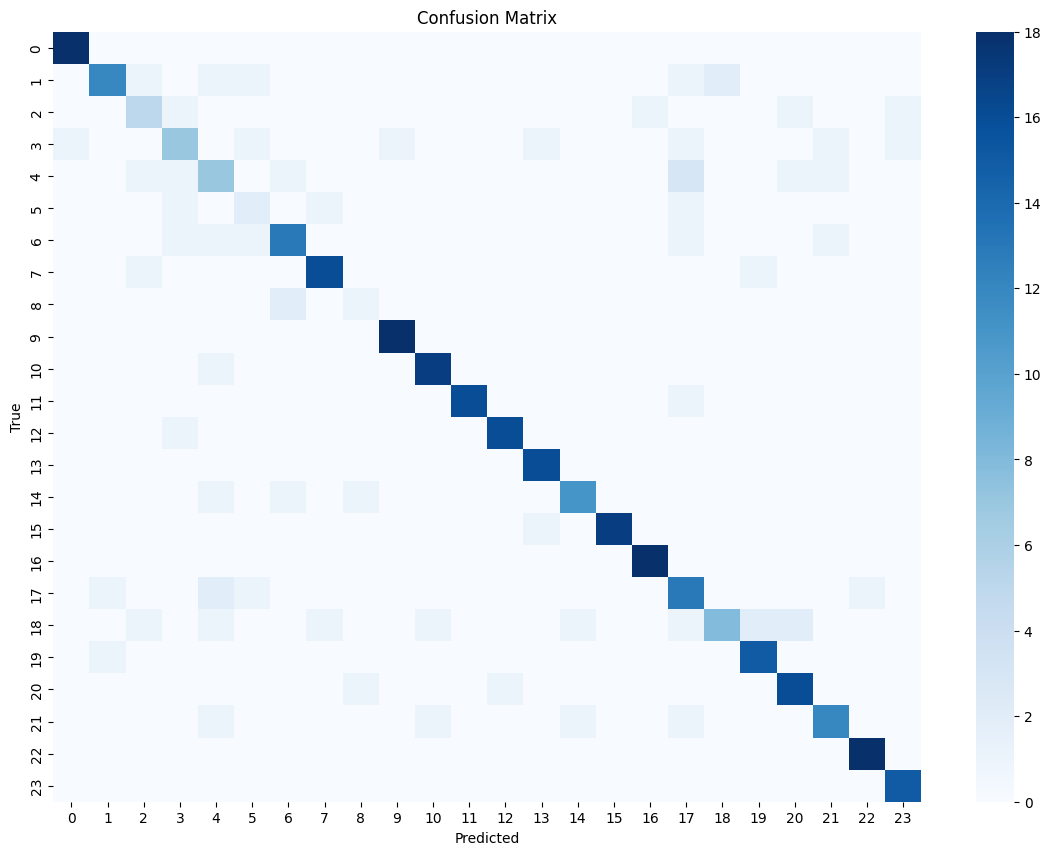

In [21]:
cm = confusion_matrix(
    true_labels,
    predictions
)

plt.figure(figsize=(14,10))

sns.heatmap(
    cm,
    annot=False,
    cmap='Blues'
)

plt.title('Confusion Matrix')

plt.xlabel('Predicted')
plt.ylabel('True')

plt.show()

La matriz de confusión muestra que el modelo tiene un buen desempeño general, ya que la mayoría de las predicciones se concentran en la diagonal principal, lo que indica que muchas clases están siendo correctamente clasificadas. Sin embargo, también se observan algunos errores de confusión entre ciertas categorías, lo cual es esperado en un problema multiclase con clases similares o desbalanceadas.

In [22]:
from sklearn.preprocessing import label_binarize

y_true_bin = label_binarize(
    true_labels,
    classes=np.unique(true_labels)
)

y_scores = torch.softmax(
    torch.tensor(test_results.predictions),
    dim=1
).numpy()

roc_auc = roc_auc_score(
    y_true_bin,
    y_scores,
    multi_class='ovr'
)

print(f'ROC-AUC: {roc_auc:.4f}')

ROC-AUC: 0.9695


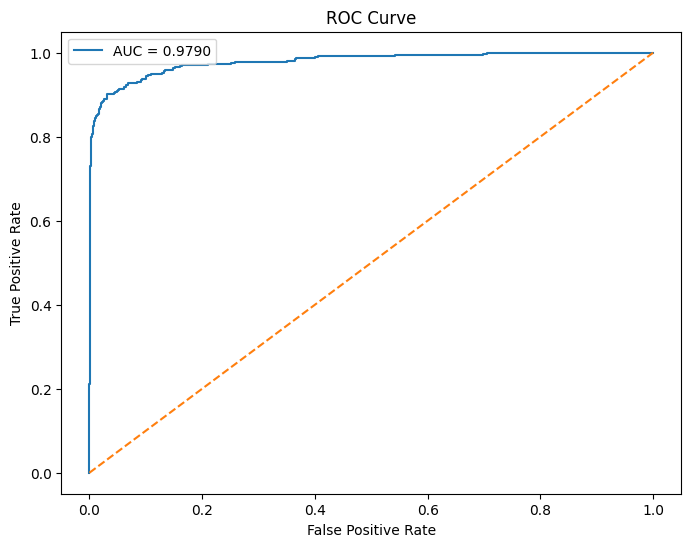

In [23]:
fpr, tpr, _ = roc_curve(
    y_true_bin.ravel(),
    y_scores.ravel()
)

roc_auc_curve = auc(fpr, tpr)

plt.figure(figsize=(8,6))

plt.plot(fpr, tpr,
         label=f'AUC = {roc_auc_curve:.4f}')

plt.plot([0,1], [0,1], linestyle='--')

plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')

plt.title('ROC Curve')

plt.legend()

plt.show()

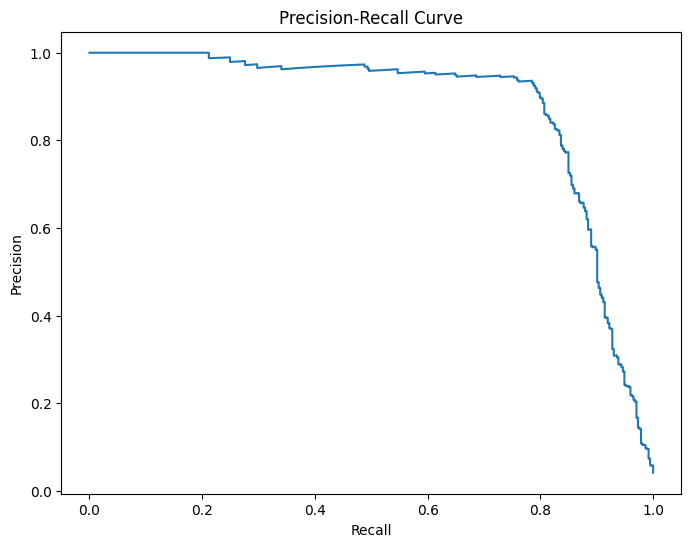

In [24]:
precision_curve, recall_curve, _ = precision_recall_curve(
    y_true_bin.ravel(),
    y_scores.ravel()
)

plt.figure(figsize=(8,6))

plt.plot(recall_curve, precision_curve)

plt.xlabel('Recall')
plt.ylabel('Precision')

plt.title('Precision-Recall Curve')

plt.show()

La matriz de confusión muestra que el modelo tiene un buen desempeño general, ya que la mayoría de las predicciones se concentran en la diagonal principal, lo que indica que muchas clases están siendo correctamente clasificadas. Sin embargo, también se observan algunos errores de confusión entre ciertas categorías, lo cual es esperado en un problema multiclase con clases similares o desbalanceadas.

Por otro lado, la curva ROC refleja un rendimiento muy alto del modelo, con un **AUC de 0.9790**, lo que indica una excelente capacidad de discriminación entre clases. Finalmente, la curva Precision-Recall muestra que el modelo mantiene una precisión alta en niveles bajos y medios de recall, aunque esta disminuye cuando se intenta cubrir casi todos los casos positivos, lo cual es típico cuando se incrementa la sensibilidad del modelo en escenarios multiclase.


In [25]:
results = pd.DataFrame({

    'Modelo': ['DistilBERT'],

    'Accuracy': [accuracy],

    'Precision': [precision],

    'Recall': [recall],

    'F1': [f1],

    'ROC-AUC': [roc_auc]
})

results

,Modelo,Accuracy,Precision,Recall,F1,ROC-AUC
0,DistilBERT,0.823056,0.825076,0.823056,0.819531,0.969499


El modelo evaluado, basado en **DistilBERT**, presenta un rendimiento global sólido en la tarea de clasificación multiclase. Se observa una **accuracy de 0.823**, lo que indica una buena capacidad general de predicción, junto con una **precisión de 0.825** y un **F1-score de 0.819**, reflejando un equilibrio adecuado entre aciertos y consistencia del modelo. Adicionalmente, el valor de **ROC-AUC de 0.969** confirma una excelente capacidad de discriminación entre clases, incluso en un escenario multiclase complejo. En conjunto, los resultados muestran un modelo bien ajustado, con buen desempeño general, aunque con margen de mejora en la consistencia entre todas las clases.

### **2.7. Guardar Resultados**

In [26]:
save_path = "../Models/distilbert_result"

os.makedirs(save_path, exist_ok=True)

print("Carpeta creada")

Carpeta creada


In [27]:
model.save_pretrained(
    f"{save_path}/model"
)

tokenizer.save_pretrained(
    f"{save_path}/tokenizer"
)

print("Modelo y tokenizer guardados")

Modelo y tokenizer guardados


In [28]:
with open(f"{save_path}/label_encoder.pkl", "wb") as f:
    pickle.dump(label_encoder, f)

print("LabelEncoder guardado")

LabelEncoder guardado


In [29]:
best_hyperparameters = {

    "model_name": model.config._name_or_path,

    "learning_rate": training_args.learning_rate,

    "batch_size": training_args.per_device_train_batch_size,

    "eval_batch_size": training_args.per_device_eval_batch_size,

    "epochs": training_args.num_train_epochs,

    "weight_decay": training_args.weight_decay,

    "max_length": MAX_LENGTH
}

In [30]:
with open(
    f"{save_path}/best_hyperparameters.json",
    "w"
) as f:

    json.dump(
        best_hyperparameters,
        f,
        indent=4
    )

print("Hiperparámetros guardados")

Hiperparámetros guardados


In [31]:
metrics = {

    "accuracy": float(accuracy),

    "precision": float(precision),

    "recall": float(recall),

    "f1_score": float(f1),

    "roc_auc": float(roc_auc)
}

In [32]:
with open(
    f"{save_path}/metrics.json",
    "w"
) as f:

    json.dump(metrics, f, indent=4)

print("Métricas guardadas")

Métricas guardadas


In [33]:
predictions_df = pd.DataFrame({

    "true_label": true_labels,

    "predicted_label": predictions
})

In [34]:
predictions_df["true_category"] = label_encoder.inverse_transform(
    predictions_df["true_label"]
)

predictions_df["predicted_category"] = label_encoder.inverse_transform(
    predictions_df["predicted_label"]
)

In [35]:
predictions_df.to_csv(
    f"{save_path}/test_predictions.csv",
    index=False
)

print("Predicciones guardadas")

Predicciones guardadas


Finalmente, guardamos en una carpeta todos los componentes de un modelo de clasificación con DistilBERT (modelo, tokenizer, encoder de etiquetas, hiperparámetros, métricas y predicciones del conjunto de prueba) para poder reutilizarlo y analizar sus resultados posteriormente.

## **3. Word2Vec + BiLSTM**

### **3.1. Cargar Datos:**

In [36]:
# =========================
# DATASETS
# =========================

X_train = np.load('../nlp_preprocessing/X_train.npy')
X_test = np.load('../nlp_preprocessing/X_test.npy')

y_train = np.load('../nlp_preprocessing/y_train.npy')
y_test = np.load('../nlp_preprocessing/y_test.npy')

# =========================
# TOKENIZER
# =========================

with open('../nlp_preprocessing/tokenizer.pkl', 'rb') as f:
    tokenizer = pickle.load(f)

# =========================
# LABEL ENCODER
# =========================

with open('../nlp_preprocessing/label_encoder.pkl', 'rb') as f:
    label_encoder = pickle.load(f)

# =========================
# WORD2VEC
# =========================

w2v_model = Word2Vec.load(
    '../nlp_preprocessing/word2vec.model'
)

embedding_matrix = np.load(
    '../nlp_preprocessing/embedding_matrix_w2v.npy'
)

print(X_train.shape)
print(X_test.shape)

(1987, 700)
(497, 700)


Este código carga los datos ya preprocesados (train/test), junto con el tokenizer, el encoder de etiquetas y el modelo Word2Vec con su matriz de embeddings, y finalmente verifica la forma de los conjuntos de datos, mostrando que hay 1,987 ejemplos de entrenamiento y 497 de prueba, cada uno representado con 700 características (tokens o dimensiones según el pipeline).

### **3.2. Train / Validation / Test Split**

In [37]:
X_train, X_val, y_train, y_val = train_test_split(
    X_train,
    y_train,
    test_size=0.2,
    random_state=42,
    stratify=y_train
)

print(X_train.shape)
print(X_val.shape)
print(X_test.shape)

(1589, 700)
(398, 700)
(497, 700)


In [38]:
# =========================
# ONE HOT ENCODING
# =========================

num_classes = len(np.unique(y_train))

y_train_cat = to_categorical(y_train, num_classes)
y_val_cat = to_categorical(y_val, num_classes)
y_test_cat = to_categorical(y_test, num_classes)

print(y_train_cat.shape)

(1589, 24)


Dividimos el conjunto de datos en entrenamiento y validación de forma estratificada, mantiene el test intacto, y luego convierte las etiquetas a formato one-hot encoding para clasificación multiclase, resultando en 24 clases totales representadas como vectores binarios.

### **3.3. Hiperparametros & Modelo BilSTM**

In [39]:
param_grid = {

    'lstm_units': [64, 128],

    'num_lstm_layers': [1, 2],

    'dropout_rate': [0.3],

    'learning_rate': [0.0005, 0.001],

    'batch_size': [32],

    'epochs': [20],

    'embedding_dim': [100]
}

In [40]:
def build_bilstm_model(
    vocab_size,
    embedding_dim,
    embedding_matrix,
    max_length,
    num_classes,
    lstm_units,
    num_lstm_layers,
    dropout_rate,
    learning_rate
):

    model = Sequential()

    # Embedding Layer
    model.add(
        Embedding(
            input_dim=vocab_size,
            output_dim=embedding_dim,
            weights=[embedding_matrix],
            input_length=max_length,
            trainable=False
        )
    )

    # LSTM Layers
    for i in range(num_lstm_layers):

        return_sequences = (
            i < num_lstm_layers - 1
        )

        model.add(
            Bidirectional(
                LSTM(
                    lstm_units,
                    return_sequences=return_sequences
                )
            )
        )

        model.add(
            Dropout(dropout_rate)
        )

    # Output
    model.add(
        Dense(
            num_classes,
            activation='softmax'
        )
    )

    optimizer = Adam(
        learning_rate=learning_rate
    )

    model.compile(
        optimizer=optimizer,
        loss='categorical_crossentropy',
        metrics=['accuracy']
    )

    return model

In [41]:
results = []

best_accuracy = 0
best_model = None
best_params = None

vocab_size = embedding_matrix.shape[0]
max_length = X_train.shape[1]

combinations = list(
    itertools.product(
        param_grid['lstm_units'],
        param_grid['num_lstm_layers'],
        param_grid['dropout_rate'],
        param_grid['learning_rate'],
        param_grid['batch_size'],
        param_grid['epochs'],
        param_grid['embedding_dim']
    )
)

print(f"Total combinaciones: {len(combinations)}")

Total combinaciones: 8


In [42]:
for (
    lstm_units,
    num_lstm_layers,
    dropout_rate,
    learning_rate,
    batch_size,
    epochs,
    embedding_dim
) in combinations:

    print("\n===================================")
    print("Entrenando configuración:")
    print(f"LSTM Units: {lstm_units}")
    print(f"Layers: {num_lstm_layers}")
    print(f"Dropout: {dropout_rate}")
    print(f"LR: {learning_rate}")
    print(f"Batch: {batch_size}")
    print(f"Epochs: {epochs}")
    print("===================================")

    model = build_bilstm_model(
        vocab_size=vocab_size,
        embedding_dim=embedding_dim,
        embedding_matrix=embedding_matrix,
        max_length=max_length,
        num_classes=num_classes,
        lstm_units=lstm_units,
        num_lstm_layers=num_lstm_layers,
        dropout_rate=dropout_rate,
        learning_rate=learning_rate
    )

    early_stop = EarlyStopping(
        monitor='val_loss',
        patience=5,
        restore_best_weights=True
    )

    history = model.fit(
        X_train,
        y_train_cat,
        validation_data=(
            X_val,
            y_val_cat
        ),
        epochs=epochs,
        batch_size=batch_size,
        callbacks=[early_stop],
        verbose=0
    )

    # Validation predictions
    y_val_pred_prob = model.predict(X_val)

    y_val_pred = np.argmax(
        y_val_pred_prob,
        axis=1
    )

    acc = accuracy_score(
        y_val,
        y_val_pred
    )

    results.append({
        'lstm_units': lstm_units,
        'num_lstm_layers': num_lstm_layers,
        'dropout_rate': dropout_rate,
        'learning_rate': learning_rate,
        'batch_size': batch_size,
        'epochs': epochs,
        'embedding_dim': embedding_dim,
        'val_accuracy': acc
    })

    print(f"Validation Accuracy: {acc:.4f}")

    if acc > best_accuracy:

        best_accuracy = acc

        best_model = model

        best_params = {
            'lstm_units': lstm_units,
            'num_lstm_layers': num_lstm_layers,
            'dropout_rate': dropout_rate,
            'learning_rate': learning_rate,
            'batch_size': batch_size,
            'epochs': epochs,
            'embedding_dim': embedding_dim
        }


Entrenando configuración:
LSTM Units: 64
Layers: 1
Dropout: 0.3
LR: 0.0005
Batch: 32
Epochs: 20


/home/guirlessa/tf_gpu/lib/python3.10/site-packages/keras/src/layers/core/embedding.py:97: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(
W0000 00:00:1778955413.379749   81900 gpu_device.cc:2459] TensorFlow was not built with CUDA kernel binaries compatible with compute capability 12.0a. CUDA kernels will be jit-compiled from PTX, which could take 30 minutes or longer.
W0000 00:00:1778955413.393686   81900 gpu_device.cc:2459] TensorFlow was not built with CUDA kernel binaries compatible with compute capability 12.0a. CUDA kernels will be jit-compiled from PTX, which could take 30 minutes or longer.
I0000 00:00:1778955413.427791   81900 gpu_device.cc:2043] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 2582 MB memory:  -> device: 0, name: NVIDIA GeForce RTX 5050 Laptop GPU, pci bus id: 0000:01:00.0, compute capability: 12.0a
E0000 00:00:1778955414.694345   85159 ptx_compiler_helpers.cc:154] *** WARNING *** Invoking ptxas with versi

13/13 ━━━━━━━━━━━━━━━━━━━━ 1s 69ms/step
Validation Accuracy: 0.6683

Entrenando configuración:
LSTM Units: 64
Layers: 1
Dropout: 0.3
LR: 0.001
Batch: 32
Epochs: 20


/home/guirlessa/tf_gpu/lib/python3.10/site-packages/keras/src/layers/core/embedding.py:97: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


13/13 ━━━━━━━━━━━━━━━━━━━━ 1s 63ms/step
Validation Accuracy: 0.6884

Entrenando configuración:
LSTM Units: 64
Layers: 2
Dropout: 0.3
LR: 0.0005
Batch: 32
Epochs: 20


/home/guirlessa/tf_gpu/lib/python3.10/site-packages/keras/src/layers/core/embedding.py:97: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


13/13 ━━━━━━━━━━━━━━━━━━━━ 5s 121ms/step
Validation Accuracy: 0.6633

Entrenando configuración:
LSTM Units: 64
Layers: 2
Dropout: 0.3
LR: 0.001
Batch: 32
Epochs: 20


/home/guirlessa/tf_gpu/lib/python3.10/site-packages/keras/src/layers/core/embedding.py:97: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


13/13 ━━━━━━━━━━━━━━━━━━━━ 3s 177ms/step
Validation Accuracy: 0.6859

Entrenando configuración:
LSTM Units: 128
Layers: 1
Dropout: 0.3
LR: 0.0005
Batch: 32
Epochs: 20


/home/guirlessa/tf_gpu/lib/python3.10/site-packages/keras/src/layers/core/embedding.py:97: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(
W0000 00:00:1778956151.062747   85137 gpu_kernel_to_blob_pass.cc:190] Failed to compile generated PTX with ptxas. Falling back to compilation by driver.
W0000 00:00:1778956151.063766   85136 gpu_kernel_to_blob_pass.cc:190] Failed to compile generated PTX with ptxas. Falling back to compilation by driver.


13/13 ━━━━━━━━━━━━━━━━━━━━ 1s 79ms/step
Validation Accuracy: 0.6683

Entrenando configuración:
LSTM Units: 128
Layers: 1
Dropout: 0.3
LR: 0.001
Batch: 32
Epochs: 20


/home/guirlessa/tf_gpu/lib/python3.10/site-packages/keras/src/layers/core/embedding.py:97: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


13/13 ━━━━━━━━━━━━━━━━━━━━ 1s 85ms/step
Validation Accuracy: 0.6759

Entrenando configuración:
LSTM Units: 128
Layers: 2
Dropout: 0.3
LR: 0.0005
Batch: 32
Epochs: 20


/home/guirlessa/tf_gpu/lib/python3.10/site-packages/keras/src/layers/core/embedding.py:97: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


13/13 ━━━━━━━━━━━━━━━━━━━━ 2s 170ms/step
Validation Accuracy: 0.6533

Entrenando configuración:
LSTM Units: 128
Layers: 2
Dropout: 0.3
LR: 0.001
Batch: 32
Epochs: 20


/home/guirlessa/tf_gpu/lib/python3.10/site-packages/keras/src/layers/core/embedding.py:97: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


13/13 ━━━━━━━━━━━━━━━━━━━━ 3s 230ms/step
Validation Accuracy: 0.6683


In [43]:
print("Mejores hiperparámetros:\n")

print(best_params)

print(f"\nBest Validation Accuracy: {best_accuracy:.4f}")

Mejores hiperparámetros:

{'lstm_units': 64, 'num_lstm_layers': 1, 'dropout_rate': 0.3, 'learning_rate': 0.001, 'batch_size': 32, 'epochs': 20, 'embedding_dim': 100}

Best Validation Accuracy: 0.6884


Definimos una cuadrícula de hiperparámetros y construimos un modelo BiLSTM con embeddings preentrenados (Word2Vec) congelados. Luego generamos todas las combinaciones posibles de hiperparámetros y entrenamos un modelo por cada configuración usando early stopping sobre el conjunto de validación. Finalmente, evaluamos la accuracy en validación para cada modelo, registramos los resultados y seleccionamos la combinación de hiperparámetros que obtiene el mejor rendimiento.

### **3.4. Evaluación Test**

In [44]:
y_test_pred_prob = best_model.predict(X_test)

y_test_pred = np.argmax(
    y_test_pred_prob,
    axis=1
)

accuracy = accuracy_score(
    y_test,
    y_test_pred
)

precision = precision_score(
    y_test,
    y_test_pred,
    average='weighted'
)

recall = recall_score(
    y_test,
    y_test_pred,
    average='weighted'
)

f1 = f1_score(
    y_test,
    y_test_pred,
    average='weighted'
)

print(f"Accuracy : {accuracy:.4f}")
print(f"Precision: {precision:.4f}")
print(f"Recall   : {recall:.4f}")
print(f"F1-Score : {f1:.4f}")

16/16 ━━━━━━━━━━━━━━━━━━━━ 1s 77ms/step
Accuracy : 0.6901
Precision: 0.6691
Recall   : 0.6901
F1-Score : 0.6732


/home/guirlessa/tf_gpu/lib/python3.10/site-packages/sklearn/metrics/_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])


El modelo obtuvo un desempeño moderado con una accuracy de  0.6901 y F1-score de 0.6732, lo que indica un rendimiento razonable. Sin embargo, la advertencia de *UndefinedMetricWarning* señala que algunas clases no fueron predichas por el modelo, lo que afecta el cálculo de la precisión y evidencia un desbalance en la capacidad de predicción entre clases.

In [45]:
y_test_bin = label_binarize(
    y_test,
    classes=np.unique(y_test)
)

roc_auc = roc_auc_score(
    y_test_bin,
    y_test_pred_prob,
    multi_class='ovr'
)

print(f"ROC-AUC: {roc_auc:.4f}")

ROC-AUC: 0.9351


El modelo alcanza un ROC-AUC de 0.9351, lo que indica una muy buena capacidad para separar las clases a nivel probabilístico, incluso si métricas como accuracy y F1 son más moderadas; esto sugiere que el modelo discrimina bien entre clases, pero presenta dificultades al momento de asignar correctamente algunas etiquetas específicas en la clasificación final.


In [46]:
print(
    classification_report(
        y_test,
        y_test_pred,
        target_names=label_encoder.classes_
    )
)

                        precision    recall  f1-score   support

            ACCOUNTANT       1.00      0.96      0.98        24
              ADVOCATE       0.59      0.71      0.64        24
           AGRICULTURE       0.40      0.15      0.22        13
               APPAREL       0.27      0.21      0.24        19
                  ARTS       0.42      0.38      0.40        21
            AUTOMOBILE       0.00      0.00      0.00         7
              AVIATION       0.48      0.58      0.53        24
               BANKING       0.41      0.30      0.35        23
                   BPO       0.00      0.00      0.00         4
  BUSINESS-DEVELOPMENT       0.92      0.96      0.94        24
                  CHEF       0.76      0.79      0.78        24
          CONSTRUCTION       0.78      0.82      0.80        22
            CONSULTANT       0.86      0.83      0.84        23
              DESIGNER       0.91      1.00      0.95        21
         DIGITAL-MEDIA       0.65      

/home/guirlessa/tf_gpu/lib/python3.10/site-packages/sklearn/metrics/_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/home/guirlessa/tf_gpu/lib/python3.10/site-packages/sklearn/metrics/_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/home/guirlessa/tf_gpu/lib/python3.10/site-packages/sklearn/metrics/_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])


El reporte de clasificación muestra el desempeño del modelo por clase en el conjunto de prueba, con una accuracy global de 0.69 y un F1-score ponderado de 0.67, lo que indica un rendimiento aceptable pero heterogéneo entre categorías. Se observa un excelente desempeño en clases como ACCOUNTANT (F1: 0.98), DESIGNER (F1: 0.95), BUSINESS-DEVELOPMENT (F1: 0.94), ENGINEERING (F1: 0.94), FINANCE (F1: 0.94) y SALES (F1: 0.94). Por el contrario, el modelo presenta dificultades críticas en clases minoritarias con un soporte muy bajo, tales como AUTOMOBILE (support: 7) y BPO (support: 4), donde las métricas de precisión, recall y F1-score se desploman a 0.00, lo que confirma una total ausencia de predicciones correctas para estas categorías. El macro promedio de 0.62 en las tres métricas principales evidencia que, al evaluar cada clase con el mismo peso sin importar su frecuencia, el rendimiento global disminuye.

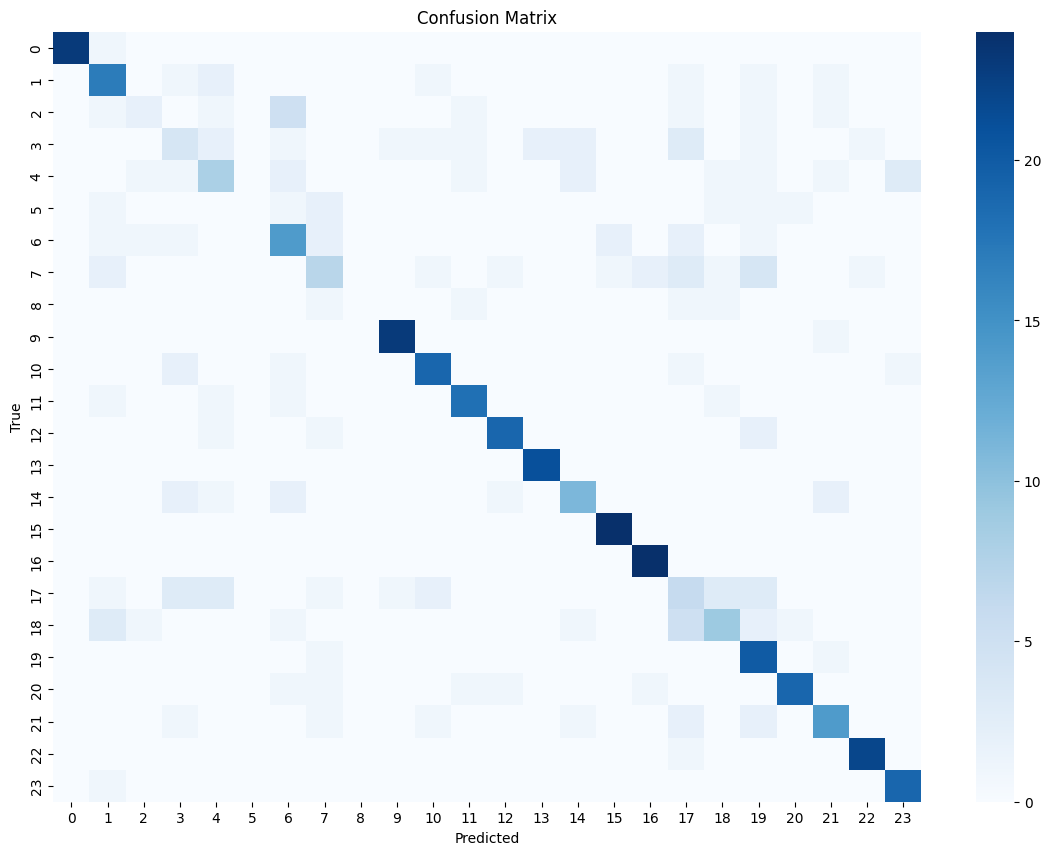

In [47]:
cm = confusion_matrix(
    y_test,
    y_test_pred
)

plt.figure(figsize=(14,10))

sns.heatmap(
    cm,
    annot=False,
    cmap='Blues'
)

plt.title('Confusion Matrix')

plt.xlabel('Predicted')
plt.ylabel('True')

plt.show()


La matriz de confusión revela que el modelo es altamente preciso y robusto en la mayoría de las clases de la 9 a la 23 (donde la diagonal principal es marcada y de azul intenso), pero presenta una fuerte degradación y dispersión en el bloque de las clases 0 a la 8. Especificamente, se observa un solapamiento crítico en la frontera de las categorías 6 y 7, así como la existencia de clases "fantasma" (específicamente la 5 y la 8) cuyos vectores en la diagonal están completamente vacíos debido al severo desbalance de datos. Esto corrobora visualmente las alertas de métricas indefinidas (F1-score de 0.00) y explica por qué el macro average decae notablemente a pesar de contar con un excelente ROC-AUC probabilístico a nivel global.

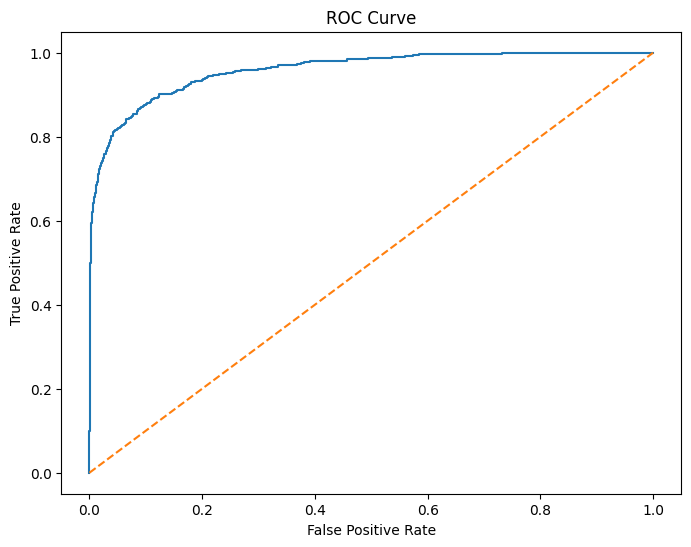

In [48]:
fpr, tpr, _ = roc_curve(
    y_test_bin.ravel(),
    y_test_pred_prob.ravel()
)

plt.figure(figsize=(8,6))

plt.plot(fpr, tpr)

plt.plot([0,1],[0,1],'--')

plt.title('ROC Curve')

plt.xlabel('False Positive Rate')

plt.ylabel('True Positive Rate')

plt.show()

La curva ROC demuestra gráficamente la excelente capacidad del modelo para discriminar y separar las clases a nivel probabilístico, ya que la curva azul se eleva rápidamente hacia la esquina superior izquierda, alejándose notablemente de la línea diagonal naranja del azar. Este comportamiento confirma que las salidas probabilísticas de la función `softmax` son de muy alta calidad y permiten al modelo identificar correctamente a los verdaderos positivos manteniendo una tasa muy baja de falsos positivos en la mayoría de los umbrales.

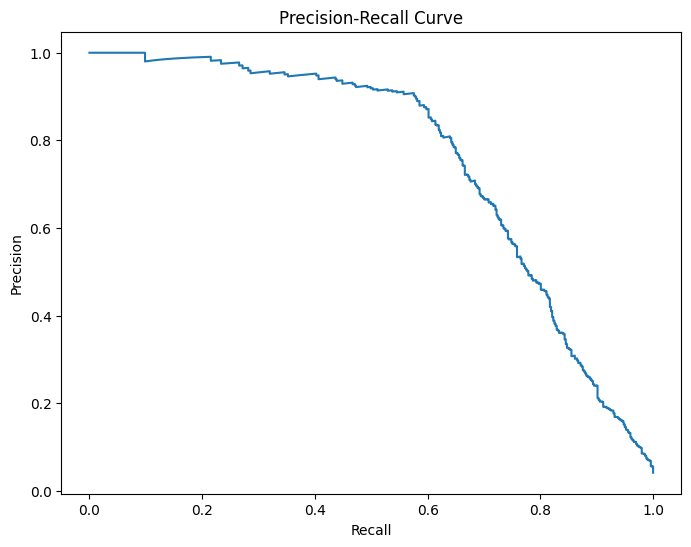

In [49]:
precision_curve, recall_curve, _ = precision_recall_curve(
    y_test_bin.ravel(),
    y_test_pred_prob.ravel()
)

plt.figure(figsize=(8,6))

plt.plot(
    recall_curve,
    precision_curve
)

plt.title('Precision-Recall Curve')

plt.xlabel('Recall')

plt.ylabel('Precision')

plt.show()


La curva Precision-Recall (PR)  refleja de manera más realista el impacto del desbalance de clases, mostrando que el sistema sostiene niveles de precisión óptimos (cercanos a 1.0) únicamente en niveles de *recall* inferiores a 0.25. A partir de dicho umbral, la precisión experimenta una caída progresiva y sostenida a medida que se intenta capturar una mayor proporción de casos positivos, llegando a desplomarse significativamente cuando el *recall* supera el 0.60.

In [50]:
results_df = pd.DataFrame([{
    'Modelo': 'Word2Vec + BiLSTM',
    'Accuracy': accuracy,
    'Precision': precision,
    'Recall': recall,
    'F1': f1,
    'ROC-AUC': roc_auc
}])

results_df

,Modelo,Accuracy,Precision,Recall,F1,ROC-AUC
0,Word2Vec + BiLSTM,0.690141,0.669059,0.690141,0.673199,0.935065


 El modelo **Word2Vec + BiLSTM** exhibe un rendimiento sólido y robusto a nivel probabilístico, respaldado por un **ROC-AUC de 0.9351**. Sin embargo, al trasladar estas probabilidades a clasificaciones duras, el rendimiento se modera registrando una **Accuracy de 0.6901** y un **F1-Score de 0.6732**. Esta brecha entre la capacidad de discriminación (AUC) y la efectividad final (F1) es un indicador directo del desbalance en los datos, donde el modelo destaca con alta precisión en la mayoría de las categorías pero sufre penalizaciones en el bloque de clases minoritarias o semánticamente solapadas.

### **3.5. Guardar Resultados**

In [51]:
save_path = "../Models/Word2Vec_BiLSTM_result"

os.makedirs(save_path, exist_ok=True)

print("Carpeta creada")

Carpeta creada


In [52]:
results_df.to_csv(
    f'{save_path}/bilstm_metrics.csv',
    index=False
)

print("Métricas guardadas")

Métricas guardadas


In [53]:
with open(
    f'{save_path}/best_hyperparameters.pkl',
    'wb'
) as f:

    pickle.dump(
        best_params,
        f
    )

print("Hiperparámetros guardados")

Hiperparámetros guardados


In [54]:
predictions_df = pd.DataFrame({

    'True_Label': label_encoder.inverse_transform(y_test),

    'Predicted_Label': label_encoder.inverse_transform(
        y_test_pred
    )
})

predictions_df.to_csv(
    f'{save_path}/test_predictions.csv',
    index=False
)

predictions_df.head()

,True_Label,Predicted_Label
0,DESIGNER,DESIGNER
1,DIGITAL-MEDIA,PUBLIC-RELATIONS
2,CONSTRUCTION,CONSTRUCTION
3,HEALTHCARE,HEALTHCARE
4,CONSTRUCTION,CONSTRUCTION


In [55]:
best_model.save(
    f'{save_path}/best_bilstm_word2vec.keras'
)

print("Modelo guardado")

Modelo guardado


In [56]:
tf.keras.backend.clear_session()

Finalmente, los resultados obtenidos fueron almacenados con el propósito de facilitar su posterior análisis y permitir un contraste riguroso frente a los rendimientos registrados por los demás modelos evaluados.

## **4. TF-IDF + XGBoost**

In [57]:
import tensorflow as tf

print(tf.config.list_physical_devices('GPU'))

[PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]


### **4.1. Cargar Datos & Label Encoder**

In [58]:
df = pd.read_csv('/home/guirlessa/MiniProject_PLN/nlp_preprocessing/resume_processed.csv')

In [59]:
df.columns

Index(['ID', 'Resume_str', 'Resume_html', 'Category', 'Length', 'Word_count',
       'mean_word_length', 'mean_sent_length', 'clean_text', 'tokens',
       'processed_text'],
      dtype='object')

In [60]:
df['processed_text']

0       administrator marketing associate administrato...
1       specialist operations summary versatile media ...
2       director summary years experience recruiting p...
3       specialist summary dedicated driven dynamic ye...
4       manager skill highlights skills department sta...
                              ...                        
2479    rank sgt non commissioned officer charge briga...
2480    government relations communications organizati...
2481    geek squad agent professional profile support ...
2482    program director office manager summary highly...
2483    storekeeper professional summary purpose docum...
Name: processed_text, Length: 2484, dtype: object

In [61]:
# ============================================
# LIMPIAR NaN
# ============================================

df['processed_text'] = df['processed_text'].fillna('')

# opcional: asegurar tipo string
df['processed_text'] = df['processed_text'].astype(str)

In [62]:
df[['processed_text', 'Category']].head()

,processed_text,Category
0,administrator marketing associate administrato...,HR
1,specialist operations summary versatile media ...,HR
2,director summary years experience recruiting p...,HR
3,specialist summary dedicated driven dynamic ye...,HR
4,manager skill highlights skills department sta...,HR


In [63]:
# ============================================
# CELDA 3 — LABEL ENCODER
# ============================================

label_encoder = LabelEncoder()

y = label_encoder.fit_transform(df['Category'])

num_classes = len(label_encoder.classes_)

print(num_classes)

24


Reslizamos la carga y la preparación inicial de los datos textuales y sus etiquetas para el modelo. En primer lugar, se lee el conjunto de datos preprocesado desde un archivo CSV y se procede a la limpieza de la columna `processed_text` mediante la sustitución de valores nulos (NaN) por cadenas vacías, asegurando además que todo el texto tenga un tipo de dato *string* homogéneo para evitar fallos en la tokenización. Posteriormente, se inicializa un objeto `LabelEncoder` para transformar las categorías categóricas de la columna `Category` en identificadores numéricos secuenciales, calculando finalmente el número total de clases únicas.

### **4.2. Train, Validation, Text Split**

In [64]:
# ============================================
# CELDA 4 — TRAIN / VALIDATION / TEST
# ============================================

X_train_text, X_temp_text, y_train, y_temp = train_test_split(
    df['processed_text'],
    y,
    test_size=0.3,
    random_state=42,
    stratify=y
)

X_val_text, X_test_text, y_val, y_test = train_test_split(
    X_temp_text,
    y_temp,
    test_size=0.5,
    random_state=42,
    stratify=y_temp
)

print(len(X_train_text))
print(len(X_val_text))
print(len(X_test_text))

1738
373
373


In [65]:
# ============================================
# CELDA 5 — TF-IDF
# ============================================

tfidf = TfidfVectorizer(
    max_features=10000,
    ngram_range=(1,2),
    min_df=2,
    max_df=0.95
)

X_train = tfidf.fit_transform(X_train_text)

X_val = tfidf.transform(X_val_text)

X_test = tfidf.transform(X_test_text)

print(X_train.shape)

(1738, 10000)


En este bloque de código se realiza la partición del conjunto de datos y la extracción de características textuales mediante ingeniería de atributos. En la primera sección, se ejecuta una división en cascada utilizando `train_test_split` de forma estratificada (`stratify=y`) para garantizar que la proporción original de las clases se mantenga constante; primero se separa un 70% de los datos para entrenamiento y el 30% restante se divide equitativamente a la mitad para conformar los conjuntos de validación (15%) y prueba (15%). En la segunda sección, se inicializa un vectorizador `TfidfVectorizer` configurado para limitar el vocabulario a las 10,000 características más importantes, capturar unigramas y bigramas (`ngram_range=(1,2)`), y filtrar palabras extremas basadas en su frecuencia documental; finalmente, este extractor se ajusta y transforma sobre el conjunto de entrenamiento (`fit_transform`), mientras que los conjuntos de validación y prueba se transforman estrictamente bajo los parámetros aprendidos (`transform`), convirtiendo los textos limpios en matrices dispersas de frecuencias numéricas listas para el modelado.

### **4.3. Hiperpárametros & Modelo**

In [11]:
# ============================================
# CELDA 6 — HIPERPARÁMETROS XGBOOST
# ============================================

param_grid = {
    'n_estimators': [100, 300],
    'max_depth': [4, 6],
    'learning_rate': [0.05, 0.1],
    'subsample': [0.8],
    'colsample_bytree': [0.8],
    'gamma': [0],
    'min_child_weight': [1, 3]
}

In [12]:
# ============================================
# CELDA 7 — MODELO BASE
# ============================================

xgb_model = XGBClassifier(
    tree_method='hist',
    device='cuda',
    eval_metric='logloss'
)

In [13]:
# ============================================
# CELDA 8 — GRID SEARCH
# ============================================

grid_search = GridSearchCV(
    estimator=xgb_model,
    param_grid=param_grid,
    scoring='f1_weighted',
    cv=3,
    verbose=2,
    n_jobs=-1
)

grid_search.fit(X_train, y_train)

Fitting 3 folds for each of 16 candidates, totalling 48 fits


/home/guirlessa/tf_gpu/lib/python3.10/site-packages/xgboost/core.py:751: UserWarning: [10:07:46] WARNING: /__w/xgboost/xgboost/src/common/error_msg.cc:62: Falling back to prediction using DMatrix due to mismatched devices. This might lead to higher memory usage and slower performance. XGBoost is running on: cuda:0, while the input data is on: cpu.
Potential solutions:
- Use a data structure that matches the device ordinal in the booster.
- Set the device for booster before call to inplace_predict.

This warning will only be shown once.

  return func(**kwargs)


[CV] END colsample_bytree=0.8, gamma=0, learning_rate=0.05, max_depth=4, min_child_weight=1, n_estimators=100, subsample=0.8; total time= 3.6min


/home/guirlessa/tf_gpu/lib/python3.10/site-packages/xgboost/core.py:751: UserWarning: [10:07:50] WARNING: /__w/xgboost/xgboost/src/common/error_msg.cc:62: Falling back to prediction using DMatrix due to mismatched devices. This might lead to higher memory usage and slower performance. XGBoost is running on: cuda:0, while the input data is on: cpu.
Potential solutions:
- Use a data structure that matches the device ordinal in the booster.
- Set the device for booster before call to inplace_predict.

This warning will only be shown once.

  return func(**kwargs)


[CV] END colsample_bytree=0.8, gamma=0, learning_rate=0.05, max_depth=4, min_child_weight=1, n_estimators=100, subsample=0.8; total time= 3.7min


/home/guirlessa/tf_gpu/lib/python3.10/site-packages/xgboost/core.py:751: UserWarning: [10:07:58] WARNING: /__w/xgboost/xgboost/src/common/error_msg.cc:62: Falling back to prediction using DMatrix due to mismatched devices. This might lead to higher memory usage and slower performance. XGBoost is running on: cuda:0, while the input data is on: cpu.
Potential solutions:
- Use a data structure that matches the device ordinal in the booster.
- Set the device for booster before call to inplace_predict.

This warning will only be shown once.

  return func(**kwargs)


[CV] END colsample_bytree=0.8, gamma=0, learning_rate=0.05, max_depth=4, min_child_weight=3, n_estimators=100, subsample=0.8; total time= 3.8min


/home/guirlessa/tf_gpu/lib/python3.10/site-packages/xgboost/core.py:751: UserWarning: [10:08:06] WARNING: /__w/xgboost/xgboost/src/common/error_msg.cc:62: Falling back to prediction using DMatrix due to mismatched devices. This might lead to higher memory usage and slower performance. XGBoost is running on: cuda:0, while the input data is on: cpu.
Potential solutions:
- Use a data structure that matches the device ordinal in the booster.
- Set the device for booster before call to inplace_predict.

This warning will only be shown once.

  return func(**kwargs)


[CV] END colsample_bytree=0.8, gamma=0, learning_rate=0.05, max_depth=4, min_child_weight=1, n_estimators=100, subsample=0.8; total time= 3.9min


/home/guirlessa/tf_gpu/lib/python3.10/site-packages/xgboost/core.py:751: UserWarning: [10:08:08] WARNING: /__w/xgboost/xgboost/src/common/error_msg.cc:62: Falling back to prediction using DMatrix due to mismatched devices. This might lead to higher memory usage and slower performance. XGBoost is running on: cuda:0, while the input data is on: cpu.
Potential solutions:
- Use a data structure that matches the device ordinal in the booster.
- Set the device for booster before call to inplace_predict.

This warning will only be shown once.

  return func(**kwargs)
/home/guirlessa/tf_gpu/lib/python3.10/site-packages/xgboost/core.py:751: UserWarning: [10:08:09] WARNING: /__w/xgboost/xgboost/src/common/error_msg.cc:62: Falling back to prediction using DMatrix due to mismatched devices. This might lead to higher memory usage and slower performance. XGBoost is running on: cuda:0, while the input data is on: cpu.
Potential solutions:
- Use a data structure that matches the device ordinal in the 

[CV] END colsample_bytree=0.8, gamma=0, learning_rate=0.05, max_depth=4, min_child_weight=3, n_estimators=100, subsample=0.8; total time= 4.0min
[CV] END colsample_bytree=0.8, gamma=0, learning_rate=0.05, max_depth=4, min_child_weight=3, n_estimators=100, subsample=0.8; total time= 4.0min


/home/guirlessa/tf_gpu/lib/python3.10/site-packages/xgboost/core.py:751: UserWarning: [10:08:48] WARNING: /__w/xgboost/xgboost/src/common/error_msg.cc:62: Falling back to prediction using DMatrix due to mismatched devices. This might lead to higher memory usage and slower performance. XGBoost is running on: cuda:0, while the input data is on: cpu.
Potential solutions:
- Use a data structure that matches the device ordinal in the booster.
- Set the device for booster before call to inplace_predict.

This warning will only be shown once.

  return func(**kwargs)


[CV] END colsample_bytree=0.8, gamma=0, learning_rate=0.05, max_depth=6, min_child_weight=1, n_estimators=100, subsample=0.8; total time= 4.7min


/home/guirlessa/tf_gpu/lib/python3.10/site-packages/xgboost/core.py:751: UserWarning: [10:08:59] WARNING: /__w/xgboost/xgboost/src/common/error_msg.cc:62: Falling back to prediction using DMatrix due to mismatched devices. This might lead to higher memory usage and slower performance. XGBoost is running on: cuda:0, while the input data is on: cpu.
Potential solutions:
- Use a data structure that matches the device ordinal in the booster.
- Set the device for booster before call to inplace_predict.

This warning will only be shown once.

  return func(**kwargs)


[CV] END colsample_bytree=0.8, gamma=0, learning_rate=0.05, max_depth=6, min_child_weight=1, n_estimators=100, subsample=0.8; total time= 4.8min


/home/guirlessa/tf_gpu/lib/python3.10/site-packages/xgboost/core.py:751: UserWarning: [10:09:32] WARNING: /__w/xgboost/xgboost/src/common/error_msg.cc:62: Falling back to prediction using DMatrix due to mismatched devices. This might lead to higher memory usage and slower performance. XGBoost is running on: cuda:0, while the input data is on: cpu.
Potential solutions:
- Use a data structure that matches the device ordinal in the booster.
- Set the device for booster before call to inplace_predict.

This warning will only be shown once.

  return func(**kwargs)


[CV] END colsample_bytree=0.8, gamma=0, learning_rate=0.05, max_depth=6, min_child_weight=1, n_estimators=100, subsample=0.8; total time= 5.4min
[CV] END colsample_bytree=0.8, gamma=0, learning_rate=0.05, max_depth=6, min_child_weight=3, n_estimators=100, subsample=0.8; total time= 4.8min
[CV] END colsample_bytree=0.8, gamma=0, learning_rate=0.05, max_depth=6, min_child_weight=3, n_estimators=100, subsample=0.8; total time= 4.8min
[CV] END colsample_bytree=0.8, gamma=0, learning_rate=0.1, max_depth=4, min_child_weight=1, n_estimators=100, subsample=0.8; total time= 3.6min
[CV] END colsample_bytree=0.8, gamma=0, learning_rate=0.05, max_depth=6, min_child_weight=3, n_estimators=100, subsample=0.8; total time= 5.2min


/home/guirlessa/tf_gpu/lib/python3.10/site-packages/xgboost/core.py:751: UserWarning: [10:15:29] WARNING: /__w/xgboost/xgboost/src/common/error_msg.cc:62: Falling back to prediction using DMatrix due to mismatched devices. This might lead to higher memory usage and slower performance. XGBoost is running on: cuda:0, while the input data is on: cpu.
Potential solutions:
- Use a data structure that matches the device ordinal in the booster.
- Set the device for booster before call to inplace_predict.

This warning will only be shown once.

  return func(**kwargs)
/home/guirlessa/tf_gpu/lib/python3.10/site-packages/xgboost/core.py:751: UserWarning: [10:15:35] WARNING: /__w/xgboost/xgboost/src/common/error_msg.cc:62: Falling back to prediction using DMatrix due to mismatched devices. This might lead to higher memory usage and slower performance. XGBoost is running on: cuda:0, while the input data is on: cpu.
Potential solutions:
- Use a data structure that matches the device ordinal in the 

[CV] END colsample_bytree=0.8, gamma=0, learning_rate=0.05, max_depth=4, min_child_weight=3, n_estimators=300, subsample=0.8; total time=11.4min


/home/guirlessa/tf_gpu/lib/python3.10/site-packages/xgboost/core.py:751: UserWarning: [10:15:43] WARNING: /__w/xgboost/xgboost/src/common/error_msg.cc:62: Falling back to prediction using DMatrix due to mismatched devices. This might lead to higher memory usage and slower performance. XGBoost is running on: cuda:0, while the input data is on: cpu.
Potential solutions:
- Use a data structure that matches the device ordinal in the booster.
- Set the device for booster before call to inplace_predict.

This warning will only be shown once.

  return func(**kwargs)


[CV] END colsample_bytree=0.8, gamma=0, learning_rate=0.05, max_depth=4, min_child_weight=1, n_estimators=300, subsample=0.8; total time=11.5min
[CV] END colsample_bytree=0.8, gamma=0, learning_rate=0.05, max_depth=4, min_child_weight=1, n_estimators=300, subsample=0.8; total time=11.6min


/home/guirlessa/tf_gpu/lib/python3.10/site-packages/xgboost/core.py:751: UserWarning: [10:15:49] WARNING: /__w/xgboost/xgboost/src/common/error_msg.cc:62: Falling back to prediction using DMatrix due to mismatched devices. This might lead to higher memory usage and slower performance. XGBoost is running on: cuda:0, while the input data is on: cpu.
Potential solutions:
- Use a data structure that matches the device ordinal in the booster.
- Set the device for booster before call to inplace_predict.

This warning will only be shown once.

  return func(**kwargs)


[CV] END colsample_bytree=0.8, gamma=0, learning_rate=0.05, max_depth=4, min_child_weight=1, n_estimators=300, subsample=0.8; total time=11.7min
[CV] END colsample_bytree=0.8, gamma=0, learning_rate=0.05, max_depth=4, min_child_weight=3, n_estimators=300, subsample=0.8; total time=11.8min


/home/guirlessa/tf_gpu/lib/python3.10/site-packages/xgboost/core.py:751: UserWarning: [10:16:21] WARNING: /__w/xgboost/xgboost/src/common/error_msg.cc:62: Falling back to prediction using DMatrix due to mismatched devices. This might lead to higher memory usage and slower performance. XGBoost is running on: cuda:0, while the input data is on: cpu.
Potential solutions:
- Use a data structure that matches the device ordinal in the booster.
- Set the device for booster before call to inplace_predict.

This warning will only be shown once.

  return func(**kwargs)


[CV] END colsample_bytree=0.8, gamma=0, learning_rate=0.1, max_depth=4, min_child_weight=1, n_estimators=100, subsample=0.8; total time= 3.4min
[CV] END colsample_bytree=0.8, gamma=0, learning_rate=0.05, max_depth=4, min_child_weight=3, n_estimators=300, subsample=0.8; total time=12.3min
[CV] END colsample_bytree=0.8, gamma=0, learning_rate=0.1, max_depth=4, min_child_weight=1, n_estimators=100, subsample=0.8; total time= 3.7min


/home/guirlessa/tf_gpu/lib/python3.10/site-packages/xgboost/core.py:751: UserWarning: [10:18:13] WARNING: /__w/xgboost/xgboost/src/common/error_msg.cc:62: Falling back to prediction using DMatrix due to mismatched devices. This might lead to higher memory usage and slower performance. XGBoost is running on: cuda:0, while the input data is on: cpu.
Potential solutions:
- Use a data structure that matches the device ordinal in the booster.
- Set the device for booster before call to inplace_predict.

This warning will only be shown once.

  return func(**kwargs)


[CV] END colsample_bytree=0.8, gamma=0, learning_rate=0.05, max_depth=6, min_child_weight=1, n_estimators=300, subsample=0.8; total time=14.2min
[CV] END colsample_bytree=0.8, gamma=0, learning_rate=0.1, max_depth=4, min_child_weight=3, n_estimators=100, subsample=0.8; total time= 3.5min
[CV] END colsample_bytree=0.8, gamma=0, learning_rate=0.1, max_depth=4, min_child_weight=3, n_estimators=100, subsample=0.8; total time= 3.5min
[CV] END colsample_bytree=0.8, gamma=0, learning_rate=0.1, max_depth=4, min_child_weight=3, n_estimators=100, subsample=0.8; total time= 3.8min
[CV] END colsample_bytree=0.8, gamma=0, learning_rate=0.1, max_depth=6, min_child_weight=1, n_estimators=100, subsample=0.8; total time= 5.0min
[CV] END colsample_bytree=0.8, gamma=0, learning_rate=0.05, max_depth=6, min_child_weight=1, n_estimators=300, subsample=0.8; total time=14.9min
[CV] END colsample_bytree=0.8, gamma=0, learning_rate=0.05, max_depth=6, min_child_weight=1, n_estimators=300, subsample=0.8; total ti

,estimator,"XGBClassifier...ree=None, ...)"
,param_grid,"{'colsample_bytree': [0.8], 'gamma': [0], 'learning_rate': [0.05, 0.1], 'max_depth': [4, 6], ...}"
,scoring,'f1_weighted'
,n_jobs,-1
,refit,True
,cv,3
,verbose,2
,pre_dispatch,'2*n_jobs'
,error_score,nan
,return_train_score,False
,objective,'multi:softprob'


In [14]:
# ============================================
# CELDA 9 — MEJORES HIPERPARÁMETROS
# ============================================

best_model = grid_search.best_estimator_

best_params = grid_search.best_params_

print(best_params)

{'colsample_bytree': 0.8, 'gamma': 0, 'learning_rate': 0.1, 'max_depth': 6, 'min_child_weight': 1, 'n_estimators': 100, 'subsample': 0.8}


In [15]:
# ============================================
# CELDA 10 — VALIDACIÓN
# ============================================

y_val_pred = best_model.predict(X_val)

val_accuracy = accuracy_score(y_val, y_val_pred)

val_f1 = f1_score(
    y_val,
    y_val_pred,
    average='weighted'
)

print(val_accuracy)
print(val_f1)

0.4691689008042895
0.4128220275105743


/home/guirlessa/tf_gpu/lib/python3.10/site-packages/xgboost/core.py:751: UserWarning: [10:31:41] WARNING: /__w/xgboost/xgboost/src/common/error_msg.cc:62: Falling back to prediction using DMatrix due to mismatched devices. This might lead to higher memory usage and slower performance. XGBoost is running on: cuda:0, while the input data is on: cpu.
Potential solutions:
- Use a data structure that matches the device ordinal in the booster.
- Set the device for booster before call to inplace_predict.

This warning will only be shown once.

  return func(**kwargs)


Contemplamos la optimización de hiperparámetros, el entrenamiento y la validación del modelo de clasificación basado en Gradient Boosting. En primer lugar, se define un espacio de búsqueda (`param_grid`) con múltiples configuraciones para regular la complejidad y el aprendizaje del algoritmo XGBoost, tales como el número de árboles (`n_estimators`), la profundidad máxima (`max_depth`), la tasa de aprendizaje (`learning_rate`) y el peso mínimo de los nodos hijos (`min_child_weight`). Acto seguido, se inicializa el clasificador base `XGBClassifier` optimizado para hardware mediante el método de histogramas (`tree_method='hist'`) y aceleración por GPU (`device='cuda'`), el cual se integra en un objeto `GridSearchCV` que ejecuta una búsqueda exhaustiva combinatoria evaluada mediante validación cruzada de 3 pliegues (`cv=3`) y guiada por la métrica `f1_weighted`. Finalmente, tras ajustar el modelo sobre el conjunto de entrenamiento (`fit`), se extrae la mejor combinación de parámetros para realizar predicciones sobre el conjunto de validación, computando la exactitud (*accuracy*) y el F1-score ponderado para medir el rendimiento de la arquitectura óptima antes de la evaluación final en test.

### **4.4. Evaluación Test**

In [16]:
# ============================================
# CELDA 11 — TEST
# ============================================

y_pred = best_model.predict(X_test)

y_prob = best_model.predict_proba(X_test)

In [23]:
# ============================================
# CELDA 12 — MÉTRICAS
# ============================================

accuracy = accuracy_score(y_test, y_pred)

precision = precision_score(
    y_test,
    y_pred,
    average='weighted'
)

recall = recall_score(
    y_test,
    y_pred,
    average='weighted'
)

f1 = f1_score(
    y_test,
    y_pred,
    average='weighted'
)

print(f'Accuracy: {accuracy:.4f}')
print(f'Precision: {precision:.4f}')
print(f'Recall: {recall:.4f}')
print(f'F1-score: {f1:.4f}')

Accuracy: 0.4933
Precision: 0.5781
Recall: 0.4933
F1-score: 0.4441


/home/guirlessa/tf_gpu/lib/python3.10/site-packages/sklearn/metrics/_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])


La evaluación del modelo TF-IDF + XGBoost en el conjunto de prueba revela un rendimiento deficiente, registrando una Accuracy de 0.4933 y un F1-score ponderado de 0.4441. Aunque la métrica de Precision alcanza un 0.5781, el desbalance general se evidencia en un Recall de 0.4933, indicando que el modelo no logra identificar correctamente ni a la mitad de las muestras pertenecientes a sus respectivas categorías. Adicionalmente, la presencia de la advertencia UndefinedMetricWarning confirma de manera metodológica que existen clases críticas para las cuales el modelo fue incapaz de asignar una sola predicción correcta, forzando a que su precisión se fije de forma predeterminada en 0.00; este colapso estructural en las clases minoritarias arrastra el balance global del F1-score por debajo de la exactitud simple, consolidando un comportamiento altamente inestable ante el desbalance del conjunto de datos.

In [17]:
# ============================================
# CELDA 13 — ROC-AUC
# ============================================

y_test_bin = label_binarize(
    y_test,
    classes=np.arange(num_classes)
)

roc_auc = roc_auc_score(
    y_test_bin,
    y_prob,
    multi_class='ovr'
)

print(f'ROC-AUC: {roc_auc:.4f}')

ROC-AUC: 0.8943


La métrica **ROC-AUC de 0.8943** indica que el modelo **TF-IDF + XGBoost** conserva una capacidad de discriminación notablemente alta a nivel probabilístico, situándose en un rango de rendimiento calificado como excelente para separar las diferentes categorías antes de establecer el umbral de decisión final. No obstante, al contrastar este valor con la *Accuracy* (0.4933) y el *F1-score* (0.4441) obtenidos anteriormente, se hace evidente una marcada disparidad matemática en el sistema. Este fenómeno confirma que, si bien las funciones de probabilidad del modelo logran ordenar y diferenciar los vectores de las clases de manera sobresaliente en la mayoría de los casos, el severo desbalance del conjunto de datos provoca que la asignación definitiva de las etiquetas colapse al aplicar la regla de decisión dura, penalizando drásticamente la clasificación real a pesar del robusto potencial de separación capturado por el AUC.

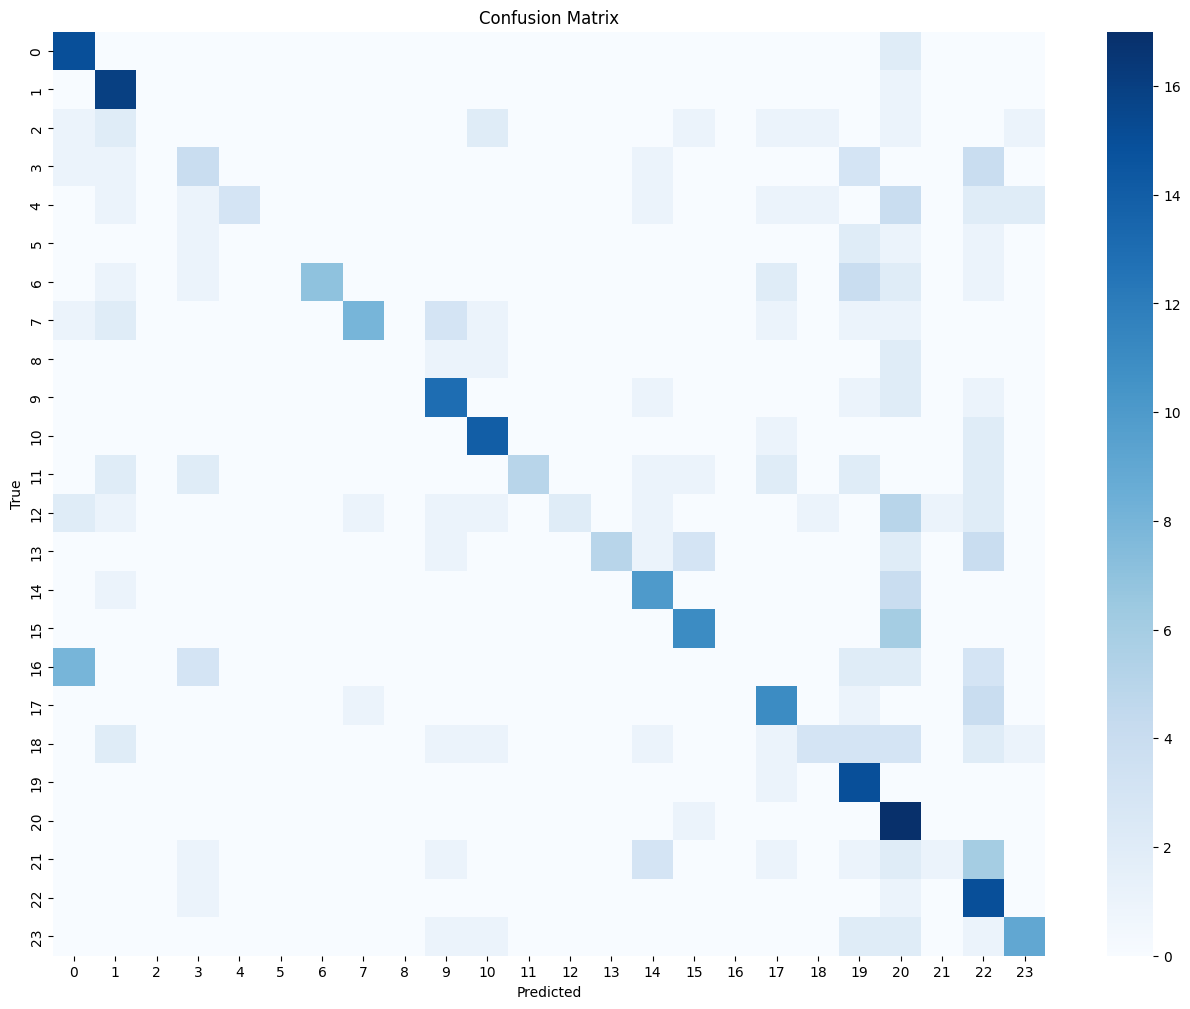

In [18]:
# ============================================
# CELDA 14 — MATRIZ DE CONFUSIÓN
# ============================================

cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(16,12))

sns.heatmap(
    cm,
    annot=False,
    cmap='Blues'
)

plt.title('Confusion Matrix')

plt.xlabel('Predicted')

plt.ylabel('True')

plt.show()

La matriz de confusión refleja un rendimiento deficiente debido a una diagonal principal sumamente debilitada y con múltiples interrupciones, lo que evidencia que el modelo falla al clasificar la mayoría de las categorías. Existe una dispersión generalizada de errores fuera de la diagonal, destacando un fuerte sesgo en las columnas **1, 3, 17, 20 y 22**, las cuales acumulan marcas verticales que demuestran la tendencia del clasificador a sobre-predecir estas etiquetas específicas cuando se enfrenta a textos de otras clases. Finalmente, las filas correspondientes a las categorías **5 y 8** se encuentran completamente vacías en la diagonal, confirmando de manera visual que el modelo es incapaz de identificar las clases minoritarias debido al impacto del desbalance de los datos.

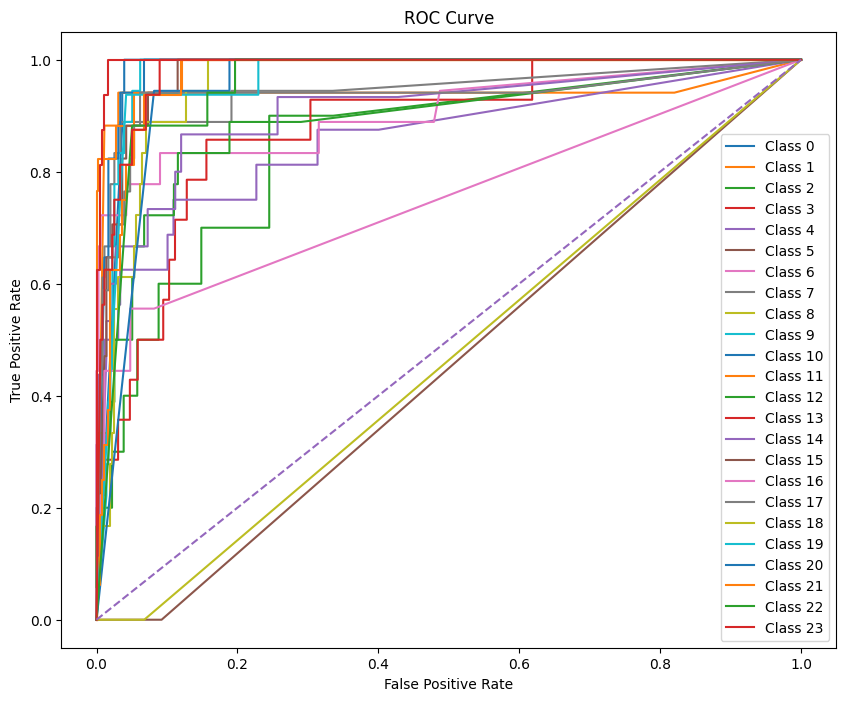

In [19]:
# ============================================
# CELDA 15 — CURVA ROC
# ============================================

fpr = dict()
tpr = dict()
roc_auc_dict = dict()

for i in range(num_classes):

    fpr[i], tpr[i], _ = roc_curve(
        y_test_bin[:, i],
        y_prob[:, i]
    )

    roc_auc_dict[i] = auc(
        fpr[i],
        tpr[i]
    )

plt.figure(figsize=(10,8))

for i in range(num_classes):

    plt.plot(
        fpr[i],
        tpr[i],
        label=f'Class {i}'
    )

plt.plot([0,1], [0,1], linestyle='--')

plt.xlabel('False Positive Rate')

plt.ylabel('True Positive Rate')

plt.title('ROC Curve')

plt.legend()

plt.show()

Podemos observar que mientras la gran mayoría de las curvas se elevan rápidamente hacia la esquina superior izquierda demostrando una excelente capacidad probabilística para identificar la mayoría de las profesiones, categorías específicas como la **Class 2, 3, 4 y 6** muestran líneas escalonadas que evidencian severas dudas y una alta acumulación de falsos positivos. El hallazgo más crítico se observa en la **Class 5 y Class 8**, cuyas líneas corren planas por el piso de la gráfica y se sitúan por debajo de la diagonal del azar, confirmando de forma visual el colapso absoluto del modelo en estas categorías menores, donde su capacidad de predicción es nula y coincide con el F1-score de 0.00 obtenido en el reporte.

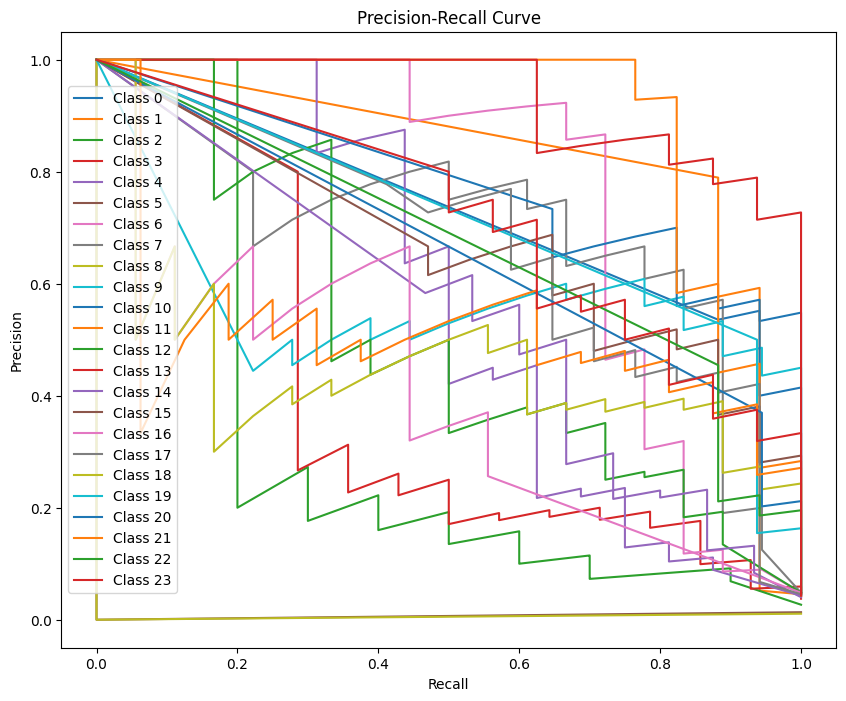

In [20]:
# ============================================
# CELDA 16 — CURVA PRECISION-RECALL
# ============================================

plt.figure(figsize=(10,8))

for i in range(num_classes):

    precision_curve, recall_curve, _ = precision_recall_curve(
        y_test_bin[:, i],
        y_prob[:, i]
    )

    plt.plot(
        recall_curve,
        precision_curve,
        label=f'Class {i}'
    )

plt.xlabel('Recall')

plt.ylabel('Precision')

plt.title('Precision-Recall Curve')

plt.legend()

plt.show()

Podemos observar a un grupo reducido de categorías (como la **Class 1 y Class 3**) logra sostener perfiles óptimos manteniendo una alta precisión aun en niveles elevados de cobertura (*recall*), mientras que la gran mayoría de las clases presenta caídas abruptas y estructuras fuertemente escalonadas, lo que indica que el modelo genera un volumen masivo de falsos positivos al intentar recuperar la totalidad de las muestras de esas áreas. El hallazgo más crítico corresponde a la **Class 5 y Class 8**, cuyas líneas colapsan de manera inmediata manteniéndose pegadas al piso del gráfico con un valor de precisión prácticamente nulo en todo el rango, lo que valida matemáticamente por qué el clasificador es incapaz de identificar estas categorías minoritarias, resultando en el F1-score de 0.00 reportado previamente.

In [21]:
# ============================================
# CELDA 17 — CLASIFICATION REPORT
# ============================================

report = classification_report(
    y_test,
    y_pred,
    target_names=label_encoder.classes_
)

print(report)

                        precision    recall  f1-score   support

            ACCOUNTANT       0.54      0.88      0.67        17
              ADVOCATE       0.55      0.94      0.70        17
           AGRICULTURE       0.00      0.00      0.00        10
               APPAREL       0.29      0.29      0.29        14
                  ARTS       1.00      0.19      0.32        16
            AUTOMOBILE       0.00      0.00      0.00         5
              AVIATION       1.00      0.39      0.56        18
               BANKING       0.80      0.44      0.57        18
                   BPO       0.00      0.00      0.00         4
  BUSINESS-DEVELOPMENT       0.59      0.72      0.65        18
                  CHEF       0.67      0.82      0.74        17
          CONSTRUCTION       1.00      0.29      0.45        17
            CONSULTANT       1.00      0.11      0.20        18
              DESIGNER       1.00      0.31      0.48        16
         DIGITAL-MEDIA       0.50      

/home/guirlessa/tf_gpu/lib/python3.10/site-packages/sklearn/metrics/_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/home/guirlessa/tf_gpu/lib/python3.10/site-packages/sklearn/metrics/_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/home/guirlessa/tf_gpu/lib/python3.10/site-packages/sklearn/metrics/_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])


El reporte de clasificación para el modelo TF-IDF + XGBoost refleja un rendimiento deficiente en el conjunto de prueba, registrando una **accuracy global de 0.49** y un **F1-score ponderado de 0.44**, lo que evidencia que el sistema no logra clasificar correctamente ni a la mitad de las muestras disponibles. El análisis por categoría revela un comportamiento altamente inconsistente: mientras algunas clases como *ADVOCATE* (F1: 0.70) y *CHEF* (F1: 0.74) muestran resultados moderados, otras como *ARTS*, *CONSTRUCTION* y *DESIGNER* logran una precisión perfecta (1.00) pero a costa de un *recall* críticamente bajo, lo que significa que el modelo es extremadamente estricto y omite la gran mayoría de sus casos reales. El impacto más grave del desbalance de datos se observa en categorías como *AGRICULTURE*, *AUTOMOBILE*, *BPO* y *FINANCE*, donde las métricas caen a **0.00** debido a que el modelo fue incapaz de identificar una sola muestra correcta; este colapso estructural en múltiples etiquetas genera las advertencias de *UndefinedMetricWarning* y arrastra el macro promedio a un **0.41**, consolidando un sistema inestable y con serias limitaciones de generalización.

In [24]:
# ============================================
# CELDA 18 — TABLA FINAL RESULTADOS
# ============================================

results = pd.DataFrame({

    'Modelo': ['TF-IDF + XGBoost'],

    'Accuracy': [accuracy],

    'Precision': [precision],

    'Recall': [recall],

    'F1': [f1],

    'ROC-AUC': [roc_auc]
})

results

,Modelo,Accuracy,Precision,Recall,F1,ROC-AUC
0,TF-IDF + XGBoost,0.493298,0.578069,0.493298,0.444062,0.894288


El modelo **TF-IDF + XGBoost** presenta un rendimiento general deficiente e inestable para la tarea de clasificación multiclase, registrando una **Accuracy de 0.4933** y un **F1-Score ponderado de 0.4441**, lo que significa que el sistema falla en clasificar correctamente más de la mitad de los documentos del conjunto de prueba. Aunque la **Precision (0.5781)** es moderada, el **Recall (0.4933)** confirma una baja capacidad para recuperar los casos positivos reales de las 24 categorías. Esta brecha, sumada a un F1-Score que se posiciona por debajo de la exactitud simple, es un indicador directo del impacto negativo del desbalance de clases, donde el modelo tiende a ignorar o colapsar por completo en las categorías minoritarias (con métricas de 0.00 como *AGRICULTURE* o *FINANCE*) y a sesgar sus decisiones hacia las etiquetas más frecuentes. Por otro lado, el **ROC-AUC de 0.8943** se mantiene notablemente alto; esta discrepancia matemática demuestra que, a nivel probabilístico, el algoritmo conserva una excelente capacidad para separar y ordenar las clases, pero al aplicar la regla de decisión dura de clasificación final, el desbalance de los datos destruye la efectividad del modelo.

### **4.5. Guardar resultados**

In [25]:
import os

save_dir = '../Models/xgboost_results'
os.makedirs(save_dir, exist_ok=True)    
print('Carpeta creada')

Carpeta creada


In [26]:
# ============================================
# CELDA 19 — GUARDAR MÉTRICAS
# ============================================

results.to_csv(
    f'{save_dir}/metrics_xgboost.csv',
    index=False
)

print("Métricas guardadas")

Métricas guardadas


In [27]:
# ============================================
# CELDA 20 — GUARDAR HIPERPARÁMETROS
# ============================================

with open(f'{save_dir}/best_hyperparameters.pkl', 'wb') as f:

    pickle.dump(best_params, f)

print("Hiperparámetros guardados")

Hiperparámetros guardados


In [28]:
# ============================================
# CELDA 21 — GUARDAR PREDICCIONES
# ============================================

predictions_df = pd.DataFrame({

    'Real': label_encoder.inverse_transform(y_test),

    'Predicted': label_encoder.inverse_transform(y_pred)
})

predictions_df.to_csv(
    f'{save_dir}/test_predictions.csv',
    index=False
)

predictions_df.head()

,Real,Predicted
0,APPAREL,SALES
1,HEALTHCARE,ADVOCATE
2,CONSTRUCTION,ADVOCATE
3,AVIATION,AVIATION
4,TEACHER,HR


In [29]:
# ============================================
# CELDA 22 — GUARDAR MODELO
# ============================================

joblib.dump(
    best_model,
    f'{save_dir}/xgboost_tfidf_model.pkl'
)

print("Modelo guardado")

Modelo guardado


In [30]:
# ============================================
# CELDA 23 — GUARDAR TF-IDF
# ============================================

joblib.dump(
    tfidf,
    f'{save_dir}/tfidf_vectorizer.pkl'
)

print("TF-IDF guardado")

TF-IDF guardado


In [31]:
# ============================================
# CELDA 24 — GUARDAR LABEL ENCODER
# ============================================

with open(f'{save_dir}/label_encoder.pkl', 'wb') as f:

    pickle.dump(label_encoder, f)

print("LabelEncoder guardado")

LabelEncoder guardado


Por último, se guardaron las métricas alcanzadas para su posterior análisis comparativo con los resultados de los otros modelos del pipeline.

## **5. FastText**

### **5.1. Cargar Datos**

In [35]:
# ============================
# LOAD DATA
# ============================

X_train = np.load('../nlp_preprocessing/X_train.npy')
X_test = np.load('../nlp_preprocessing/X_test.npy')

y_train = np.load('../nlp_preprocessing/y_train.npy')
y_test = np.load('../nlp_preprocessing/y_test.npy')

# Embedding FastText
embedding_matrix = np.load(
    '../nlp_preprocessing/embedding_matrix_ft.npy'
)

# Label encoder
with open(
    '../nlp_preprocessing/label_encoder.pkl',
    'rb'
) as f:

    label_encoder = pickle.load(f)

num_classes = len(label_encoder.classes_)

print(X_train.shape)
print(X_test.shape)

(1987, 700)
(497, 700)


Este bloque de código carga los conjuntos de datos de entrenamiento y prueba ya preprocesados, junto con una matriz de embeddings de **FastText** y el codificador de etiquetas, con el fin de verificar las dimensiones de los datos y preparar las variables necesarias para configurar el siguiente modelo de clasificación.

### **5.2. Train, Validation & Test Split**

In [36]:
# ============================
# TRAIN / VALIDATION
# ============================

X_train_final, X_val, y_train_final, y_val = train_test_split(
    X_train,
    y_train,
    test_size=0.2,
    random_state=42,
    stratify=y_train
)

print(X_train_final.shape)
print(X_val.shape)

(1589, 700)
(398, 700)


Se divide el conjunto de datos de entrenamiento para separar un 20% destinado a la validación del modelo, aplicando una partición estratificada para asegurar que ambos subconjuntos conserven la misma proporción original de las clases.

### **5.3. Hiperpárametros & Modelo**

In [37]:
param_grid = {

    'lstm_units': [64, 128],

    'num_lstm_layers': [1, 2],

    'dropout_rate': [0.3, 0.5],

    'learning_rate': [0.001, 0.0005],

    'batch_size': [32],

    'sequence_length': [100, 300, 700],

    'epochs': [50],

    'embedding_dim': [100]
}

In [38]:
# ============================
# MODEL FUNCTION
# ============================

def build_bilstm_model(
    vocab_size,
    embedding_matrix,
    sequence_length,
    embedding_dim,
    lstm_units,
    num_lstm_layers,
    dropout_rate,
    learning_rate,
    num_classes
):

    model = Sequential()

    # Embedding layer
    model.add(

        Embedding(
            input_dim=vocab_size,
            output_dim=embedding_dim,
            weights=[embedding_matrix],
            input_length=sequence_length,
            trainable=False
        )
    )

    # LSTM layers
    for i in range(num_lstm_layers):

        return_sequences = (
            i < num_lstm_layers - 1
        )

        model.add(

            Bidirectional(

                LSTM(
                    lstm_units,
                    return_sequences=return_sequences
                )
            )
        )

        model.add(
            Dropout(dropout_rate)
        )

    # Output
    model.add(
        Dense(
            num_classes,
            activation='softmax'
        )
    )

    # Compile
    optimizer = Adam(
        learning_rate=learning_rate
    )

    model.compile(
        optimizer=optimizer,
        loss='sparse_categorical_crossentropy',
        metrics=['accuracy']
    )

    return model

In [39]:
# ============================
# SEARCH SETUP
# ============================

vocab_size = embedding_matrix.shape[0]

best_accuracy = 0

best_model = None

best_params = None

results = []

In [40]:
# ============================
# GRID SEARCH
# ============================

all_combinations = list(

    itertools.product(

        param_grid['lstm_units'],
        param_grid['num_lstm_layers'],
        param_grid['dropout_rate'],
        param_grid['learning_rate'],
        param_grid['batch_size'],
        param_grid['sequence_length'],
        param_grid['epochs'],
        param_grid['embedding_dim']
    )
)

print(f'Total combinations: {len(all_combinations)}')

Total combinations: 48


In [ ]:
# ============================
# TRAIN LOOP
# ============================

for params in all_combinations:

    (
        lstm_units,
        num_lstm_layers,
        dropout_rate,
        learning_rate,
        batch_size,
        sequence_length,
        epochs,
        embedding_dim

    ) = params

    print('\n============================')
    print(params)

    # Recortar secuencias
    X_train_seq = X_train_final[:, :sequence_length]
    X_val_seq = X_val[:, :sequence_length]

    # Embedding dim
    current_embedding = embedding_matrix

    if current_embedding.shape[1] != embedding_dim:
        continue

    # Modelo
    model = build_bilstm_model(

        vocab_size=vocab_size,
        embedding_matrix=current_embedding,
        sequence_length=sequence_length,
        embedding_dim=embedding_dim,
        lstm_units=lstm_units,
        num_lstm_layers=num_lstm_layers,
        dropout_rate=dropout_rate,
        learning_rate=learning_rate,
        num_classes=num_classes
    )

    # Early stopping
    early_stop = EarlyStopping(
        monitor='val_loss',
        patience=5,
        restore_best_weights=True
    )

    # Fit
    history = model.fit(

        X_train_seq,
        y_train_final,

        validation_data=(
            X_val_seq,
            y_val
        ),

        epochs=epochs,
        batch_size=batch_size,
        callbacks=[early_stop],

        verbose=1
    )

    # Validation prediction
    y_val_pred_prob = model.predict(X_val_seq)

    y_val_pred = np.argmax(
        y_val_pred_prob,
        axis=1
    )

    acc = accuracy_score(
        y_val,
        y_val_pred
    )

    print(f'Validation Accuracy: {acc}')

    # Guardar resultados
    results.append({

        'params': params,
        'accuracy': acc
    })

    # Mejor modelo
    if acc > best_accuracy:

        best_accuracy = acc

        best_model = model

        best_params = {

            'lstm_units': lstm_units,
            'num_lstm_layers': num_lstm_layers,
            'dropout_rate': dropout_rate,
            'learning_rate': learning_rate,
            'batch_size': batch_size,
            'sequence_length': sequence_length,
            'epochs': epochs,
            'embedding_dim': embedding_dim
        }


(64, 1, 0.3, 0.001, 32, 100, 50, 100)


/home/guirlessa/tf_gpu/lib/python3.10/site-packages/keras/src/layers/core/embedding.py:97: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(
W0000 00:00:1778945868.200833     905 gpu_device.cc:2459] TensorFlow was not built with CUDA kernel binaries compatible with compute capability 12.0a. CUDA kernels will be jit-compiled from PTX, which could take 30 minutes or longer.
I0000 00:00:1778945868.296886     905 gpu_device.cc:2043] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 4806 MB memory:  -> device: 0, name: NVIDIA GeForce RTX 5050 Laptop GPU, pci bus id: 0000:01:00.0, compute capability: 12.0a
E0000 00:00:1778945869.427821    4671 ptx_compiler_helpers.cc:154] *** WARNING *** Invoking ptxas with version 12.0.140, which corresponds to a CUDA version <=12.6.2. CUDA versions 12.x.y up to and including 12.6.2 miscompile certain edge cases around clamping.
Please upgrade to CUDA 12.6.3 or newer.
W0000 00:00:1778945869.432524    4671 su

Epoch 1/50


W0000 00:00:1778945871.364202    4733 gpu_kernel_to_blob_pass.cc:190] Failed to compile generated PTX with ptxas. Falling back to compilation by driver.
W0000 00:00:1778945871.365152    4728 gpu_kernel_to_blob_pass.cc:190] Failed to compile generated PTX with ptxas. Falling back to compilation by driver.
W0000 00:00:1778945871.366123    4718 gpu_kernel_to_blob_pass.cc:190] Failed to compile generated PTX with ptxas. Falling back to compilation by driver.
W0000 00:00:1778945871.367235    4732 gpu_kernel_to_blob_pass.cc:190] Failed to compile generated PTX with ptxas. Falling back to compilation by driver.
W0000 00:00:1778945871.368735    4731 gpu_kernel_to_blob_pass.cc:190] Failed to compile generated PTX with ptxas. Falling back to compilation by driver.
W0000 00:00:1778945871.369992    4719 gpu_kernel_to_blob_pass.cc:190] Failed to compile generated PTX with ptxas. Falling back to compilation by driver.
W0000 00:00:1778945871.384033    4731 gpu_kernel_to_blob_pass.cc:190] Failed to co

50/50 ━━━━━━━━━━━━━━━━━━━━ 6s 39ms/step - accuracy: 0.2687 - loss: 2.8077 - val_accuracy: 0.4899 - val_loss: 2.3324
Epoch 2/50
50/50 ━━━━━━━━━━━━━━━━━━━━ 2s 33ms/step - accuracy: 0.5714 - loss: 1.9545 - val_accuracy: 0.6131 - val_loss: 1.7476
Epoch 3/50
50/50 ━━━━━━━━━━━━━━━━━━━━ 2s 33ms/step - accuracy: 0.6507 - loss: 1.4817 - val_accuracy: 0.6457 - val_loss: 1.5145
Epoch 4/50
50/50 ━━━━━━━━━━━━━━━━━━━━ 3s 55ms/step - accuracy: 0.7093 - loss: 1.2156 - val_accuracy: 0.6859 - val_loss: 1.3798
Epoch 5/50
50/50 ━━━━━━━━━━━━━━━━━━━━ 2s 32ms/step - accuracy: 0.7426 - loss: 1.0292 - val_accuracy: 0.6910 - val_loss: 1.3084
Epoch 6/50
50/50 ━━━━━━━━━━━━━━━━━━━━ 2s 32ms/step - accuracy: 0.7734 - loss: 0.8991 - val_accuracy: 0.6935 - val_loss: 1.2881
Epoch 7/50
50/50 ━━━━━━━━━━━━━━━━━━━━ 2s 31ms/step - accuracy: 0.8037 - loss: 0.7965 - val_accuracy: 0.6935 - val_loss: 1.2749
Epoch 8/50
50/50 ━━━━━━━━━━━━━━━━━━━━ 2s 34ms/step - accuracy: 0.8288 - loss: 0.6927 - val_accuracy: 0.7060 - val_loss: 1.

/home/guirlessa/tf_gpu/lib/python3.10/site-packages/keras/src/layers/core/embedding.py:97: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


50/50 ━━━━━━━━━━━━━━━━━━━━ 4s 63ms/step - accuracy: 0.2561 - loss: 2.8237 - val_accuracy: 0.4975 - val_loss: 2.3806
Epoch 2/50
50/50 ━━━━━━━━━━━━━━━━━━━━ 3s 58ms/step - accuracy: 0.5551 - loss: 1.9805 - val_accuracy: 0.6005 - val_loss: 1.7844
Epoch 3/50
50/50 ━━━━━━━━━━━━━━━━━━━━ 3s 58ms/step - accuracy: 0.6438 - loss: 1.5005 - val_accuracy: 0.6281 - val_loss: 1.5554
Epoch 4/50
50/50 ━━━━━━━━━━━━━━━━━━━━ 3s 62ms/step - accuracy: 0.7036 - loss: 1.2253 - val_accuracy: 0.6608 - val_loss: 1.4386
Epoch 5/50
50/50 ━━━━━━━━━━━━━━━━━━━━ 4s 78ms/step - accuracy: 0.7483 - loss: 1.0494 - val_accuracy: 0.6407 - val_loss: 1.3768
Epoch 6/50
50/50 ━━━━━━━━━━━━━━━━━━━━ 3s 58ms/step - accuracy: 0.7835 - loss: 0.8925 - val_accuracy: 0.6583 - val_loss: 1.3383
Epoch 7/50
50/50 ━━━━━━━━━━━━━━━━━━━━ 3s 59ms/step - accuracy: 0.8030 - loss: 0.8002 - val_accuracy: 0.6683 - val_loss: 1.2928
Epoch 8/50
50/50 ━━━━━━━━━━━━━━━━━━━━ 3s 58ms/step - accuracy: 0.8357 - loss: 0.6937 - val_accuracy: 0.6784 - val_loss: 1.

/home/guirlessa/tf_gpu/lib/python3.10/site-packages/keras/src/layers/core/embedding.py:97: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


50/50 ━━━━━━━━━━━━━━━━━━━━ 8s 132ms/step - accuracy: 0.2756 - loss: 2.8350 - val_accuracy: 0.5151 - val_loss: 2.4221
Epoch 2/50
50/50 ━━━━━━━━━━━━━━━━━━━━ 7s 132ms/step - accuracy: 0.5513 - loss: 2.0525 - val_accuracy: 0.5930 - val_loss: 1.8659
Epoch 3/50
50/50 ━━━━━━━━━━━━━━━━━━━━ 6s 112ms/step - accuracy: 0.6501 - loss: 1.5793 - val_accuracy: 0.6382 - val_loss: 1.5892
Epoch 4/50
50/50 ━━━━━━━━━━━━━━━━━━━━ 6s 114ms/step - accuracy: 0.6891 - loss: 1.3153 - val_accuracy: 0.6583 - val_loss: 1.4424
Epoch 5/50
50/50 ━━━━━━━━━━━━━━━━━━━━ 5s 107ms/step - accuracy: 0.7244 - loss: 1.1535 - val_accuracy: 0.6709 - val_loss: 1.3458
Epoch 6/50
50/50 ━━━━━━━━━━━━━━━━━━━━ 6s 114ms/step - accuracy: 0.7602 - loss: 1.0033 - val_accuracy: 0.6709 - val_loss: 1.2993
Epoch 7/50
50/50 ━━━━━━━━━━━━━━━━━━━━ 6s 114ms/step - accuracy: 0.7823 - loss: 0.8931 - val_accuracy: 0.6809 - val_loss: 1.2689
Epoch 8/50
50/50 ━━━━━━━━━━━━━━━━━━━━ 7s 134ms/step - accuracy: 0.8087 - loss: 0.8065 - val_accuracy: 0.6683 - val_

/home/guirlessa/tf_gpu/lib/python3.10/site-packages/keras/src/layers/core/embedding.py:97: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


50/50 ━━━━━━━━━━━━━━━━━━━━ 3s 35ms/step - accuracy: 0.1542 - loss: 3.0439 - val_accuracy: 0.3417 - val_loss: 2.7830
Epoch 2/50
50/50 ━━━━━━━━━━━━━━━━━━━━ 2s 31ms/step - accuracy: 0.3971 - loss: 2.5462 - val_accuracy: 0.5226 - val_loss: 2.3457
Epoch 3/50
50/50 ━━━━━━━━━━━━━━━━━━━━ 2s 31ms/step - accuracy: 0.5419 - loss: 2.0698 - val_accuracy: 0.5879 - val_loss: 1.9578
Epoch 4/50
50/50 ━━━━━━━━━━━━━━━━━━━━ 2s 31ms/step - accuracy: 0.6193 - loss: 1.6992 - val_accuracy: 0.6181 - val_loss: 1.7305
Epoch 5/50
50/50 ━━━━━━━━━━━━━━━━━━━━ 2s 31ms/step - accuracy: 0.6545 - loss: 1.4643 - val_accuracy: 0.6307 - val_loss: 1.5835
Epoch 6/50
50/50 ━━━━━━━━━━━━━━━━━━━━ 2s 31ms/step - accuracy: 0.7048 - loss: 1.2896 - val_accuracy: 0.6508 - val_loss: 1.5002
Epoch 7/50
50/50 ━━━━━━━━━━━━━━━━━━━━ 2s 31ms/step - accuracy: 0.7206 - loss: 1.1594 - val_accuracy: 0.6533 - val_loss: 1.4468
Epoch 8/50
50/50 ━━━━━━━━━━━━━━━━━━━━ 2s 32ms/step - accuracy: 0.7665 - loss: 1.0250 - val_accuracy: 0.6658 - val_loss: 1.

/home/guirlessa/tf_gpu/lib/python3.10/site-packages/keras/src/layers/core/embedding.py:97: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


50/50 ━━━━━━━━━━━━━━━━━━━━ 4s 62ms/step - accuracy: 0.1731 - loss: 2.9894 - val_accuracy: 0.3518 - val_loss: 2.7393
Epoch 2/50
50/50 ━━━━━━━━━━━━━━━━━━━━ 3s 58ms/step - accuracy: 0.4160 - loss: 2.4980 - val_accuracy: 0.5050 - val_loss: 2.3066
Epoch 3/50
50/50 ━━━━━━━━━━━━━━━━━━━━ 3s 57ms/step - accuracy: 0.5519 - loss: 2.0403 - val_accuracy: 0.5503 - val_loss: 1.9677
Epoch 4/50
50/50 ━━━━━━━━━━━━━━━━━━━━ 4s 78ms/step - accuracy: 0.6193 - loss: 1.7170 - val_accuracy: 0.5829 - val_loss: 1.7508
Epoch 5/50
50/50 ━━━━━━━━━━━━━━━━━━━━ 3s 57ms/step - accuracy: 0.6570 - loss: 1.4835 - val_accuracy: 0.6256 - val_loss: 1.6156
Epoch 6/50
50/50 ━━━━━━━━━━━━━━━━━━━━ 3s 58ms/step - accuracy: 0.6935 - loss: 1.3209 - val_accuracy: 0.6332 - val_loss: 1.5248
Epoch 7/50
50/50 ━━━━━━━━━━━━━━━━━━━━ 3s 58ms/step - accuracy: 0.7199 - loss: 1.1973 - val_accuracy: 0.6357 - val_loss: 1.4644
Epoch 8/50
50/50 ━━━━━━━━━━━━━━━━━━━━ 3s 58ms/step - accuracy: 0.7439 - loss: 1.0727 - val_accuracy: 0.6533 - val_loss: 1.

/home/guirlessa/tf_gpu/lib/python3.10/site-packages/keras/src/layers/core/embedding.py:97: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


50/50 ━━━━━━━━━━━━━━━━━━━━ 7s 113ms/step - accuracy: 0.1435 - loss: 3.0429 - val_accuracy: 0.3945 - val_loss: 2.7785
Epoch 2/50
50/50 ━━━━━━━━━━━━━━━━━━━━ 6s 127ms/step - accuracy: 0.4298 - loss: 2.5436 - val_accuracy: 0.5226 - val_loss: 2.3267
Epoch 3/50
50/50 ━━━━━━━━━━━━━━━━━━━━ 5s 107ms/step - accuracy: 0.5456 - loss: 2.1091 - val_accuracy: 0.5930 - val_loss: 1.9940
Epoch 4/50
50/50 ━━━━━━━━━━━━━━━━━━━━ 5s 107ms/step - accuracy: 0.6029 - loss: 1.7952 - val_accuracy: 0.5955 - val_loss: 1.7956
Epoch 5/50
50/50 ━━━━━━━━━━━━━━━━━━━━ 5s 107ms/step - accuracy: 0.6476 - loss: 1.5937 - val_accuracy: 0.6131 - val_loss: 1.6665
Epoch 6/50
50/50 ━━━━━━━━━━━━━━━━━━━━ 5s 107ms/step - accuracy: 0.6671 - loss: 1.4409 - val_accuracy: 0.6281 - val_loss: 1.5696
Epoch 7/50
50/50 ━━━━━━━━━━━━━━━━━━━━ 5s 107ms/step - accuracy: 0.7074 - loss: 1.3114 - val_accuracy: 0.6457 - val_loss: 1.5011
Epoch 8/50
50/50 ━━━━━━━━━━━━━━━━━━━━ 5s 106ms/step - accuracy: 0.7237 - loss: 1.1954 - val_accuracy: 0.6583 - val_

/home/guirlessa/tf_gpu/lib/python3.10/site-packages/keras/src/layers/core/embedding.py:97: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


50/50 ━━━━━━━━━━━━━━━━━━━━ 3s 35ms/step - accuracy: 0.1963 - loss: 2.9019 - val_accuracy: 0.4724 - val_loss: 2.5072
Epoch 2/50
50/50 ━━━━━━━━━━━━━━━━━━━━ 2s 30ms/step - accuracy: 0.4846 - loss: 2.1922 - val_accuracy: 0.5327 - val_loss: 1.9561
Epoch 3/50
50/50 ━━━━━━━━━━━━━━━━━━━━ 2s 31ms/step - accuracy: 0.5809 - loss: 1.6950 - val_accuracy: 0.5854 - val_loss: 1.6540
Epoch 4/50
50/50 ━━━━━━━━━━━━━━━━━━━━ 2s 30ms/step - accuracy: 0.6526 - loss: 1.4100 - val_accuracy: 0.6357 - val_loss: 1.4985
Epoch 5/50
50/50 ━━━━━━━━━━━━━━━━━━━━ 1s 30ms/step - accuracy: 0.6879 - loss: 1.2388 - val_accuracy: 0.6432 - val_loss: 1.4125
Epoch 6/50
50/50 ━━━━━━━━━━━━━━━━━━━━ 2s 30ms/step - accuracy: 0.7225 - loss: 1.0914 - val_accuracy: 0.6583 - val_loss: 1.3605
Epoch 7/50
50/50 ━━━━━━━━━━━━━━━━━━━━ 2s 30ms/step - accuracy: 0.7420 - loss: 0.9995 - val_accuracy: 0.6558 - val_loss: 1.3415
Epoch 8/50
50/50 ━━━━━━━━━━━━━━━━━━━━ 2s 30ms/step - accuracy: 0.7659 - loss: 0.8995 - val_accuracy: 0.6859 - val_loss: 1.

/home/guirlessa/tf_gpu/lib/python3.10/site-packages/keras/src/layers/core/embedding.py:97: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


50/50 ━━━━━━━━━━━━━━━━━━━━ 4s 63ms/step - accuracy: 0.1938 - loss: 2.9450 - val_accuracy: 0.4874 - val_loss: 2.5243
Epoch 2/50
50/50 ━━━━━━━━━━━━━━━━━━━━ 3s 58ms/step - accuracy: 0.4726 - loss: 2.2195 - val_accuracy: 0.5804 - val_loss: 1.9665
Epoch 3/50
50/50 ━━━━━━━━━━━━━━━━━━━━ 3s 56ms/step - accuracy: 0.5872 - loss: 1.7357 - val_accuracy: 0.6206 - val_loss: 1.6580
Epoch 4/50
50/50 ━━━━━━━━━━━━━━━━━━━━ 3s 56ms/step - accuracy: 0.6344 - loss: 1.4478 - val_accuracy: 0.6357 - val_loss: 1.4943
Epoch 5/50
50/50 ━━━━━━━━━━━━━━━━━━━━ 3s 56ms/step - accuracy: 0.6778 - loss: 1.2764 - val_accuracy: 0.6608 - val_loss: 1.3962
Epoch 6/50
50/50 ━━━━━━━━━━━━━━━━━━━━ 3s 57ms/step - accuracy: 0.7105 - loss: 1.1312 - val_accuracy: 0.6508 - val_loss: 1.3358
Epoch 7/50
50/50 ━━━━━━━━━━━━━━━━━━━━ 4s 76ms/step - accuracy: 0.7325 - loss: 1.0095 - val_accuracy: 0.6784 - val_loss: 1.2679
Epoch 8/50
50/50 ━━━━━━━━━━━━━━━━━━━━ 3s 56ms/step - accuracy: 0.7760 - loss: 0.9011 - val_accuracy: 0.6834 - val_loss: 1.

/home/guirlessa/tf_gpu/lib/python3.10/site-packages/keras/src/layers/core/embedding.py:97: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


50/50 ━━━━━━━━━━━━━━━━━━━━ 7s 116ms/step - accuracy: 0.2354 - loss: 2.8697 - val_accuracy: 0.5050 - val_loss: 2.4616
Epoch 2/50
50/50 ━━━━━━━━━━━━━━━━━━━━ 5s 109ms/step - accuracy: 0.4991 - loss: 2.1562 - val_accuracy: 0.5503 - val_loss: 1.9269
Epoch 3/50
50/50 ━━━━━━━━━━━━━━━━━━━━ 5s 109ms/step - accuracy: 0.5916 - loss: 1.7310 - val_accuracy: 0.6181 - val_loss: 1.6692
Epoch 4/50
50/50 ━━━━━━━━━━━━━━━━━━━━ 5s 109ms/step - accuracy: 0.6300 - loss: 1.5052 - val_accuracy: 0.6432 - val_loss: 1.5153
Epoch 5/50
50/50 ━━━━━━━━━━━━━━━━━━━━ 5s 107ms/step - accuracy: 0.6734 - loss: 1.3189 - val_accuracy: 0.6482 - val_loss: 1.4471
Epoch 6/50
50/50 ━━━━━━━━━━━━━━━━━━━━ 6s 128ms/step - accuracy: 0.6992 - loss: 1.2028 - val_accuracy: 0.6533 - val_loss: 1.3696
Epoch 7/50
50/50 ━━━━━━━━━━━━━━━━━━━━ 5s 107ms/step - accuracy: 0.7306 - loss: 1.0839 - val_accuracy: 0.6709 - val_loss: 1.3271
Epoch 8/50
50/50 ━━━━━━━━━━━━━━━━━━━━ 5s 107ms/step - accuracy: 0.7520 - loss: 1.0093 - val_accuracy: 0.6583 - val_

/home/guirlessa/tf_gpu/lib/python3.10/site-packages/keras/src/layers/core/embedding.py:97: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


50/50 ━━━━━━━━━━━━━━━━━━━━ 3s 36ms/step - accuracy: 0.1152 - loss: 3.0799 - val_accuracy: 0.3141 - val_loss: 2.8270
Epoch 2/50
50/50 ━━━━━━━━━━━━━━━━━━━━ 2s 32ms/step - accuracy: 0.3272 - loss: 2.6527 - val_accuracy: 0.4673 - val_loss: 2.4697
Epoch 3/50
50/50 ━━━━━━━━━━━━━━━━━━━━ 2s 31ms/step - accuracy: 0.4537 - loss: 2.2795 - val_accuracy: 0.5201 - val_loss: 2.1590
Epoch 4/50
50/50 ━━━━━━━━━━━━━━━━━━━━ 2s 31ms/step - accuracy: 0.5412 - loss: 1.9660 - val_accuracy: 0.5653 - val_loss: 1.9171
Epoch 5/50
50/50 ━━━━━━━━━━━━━━━━━━━━ 2s 31ms/step - accuracy: 0.5890 - loss: 1.7424 - val_accuracy: 0.6005 - val_loss: 1.7522
Epoch 6/50
50/50 ━━━━━━━━━━━━━━━━━━━━ 2s 31ms/step - accuracy: 0.6180 - loss: 1.5812 - val_accuracy: 0.5905 - val_loss: 1.6466
Epoch 7/50
50/50 ━━━━━━━━━━━━━━━━━━━━ 2s 31ms/step - accuracy: 0.6532 - loss: 1.4176 - val_accuracy: 0.6307 - val_loss: 1.5610
Epoch 8/50
50/50 ━━━━━━━━━━━━━━━━━━━━ 2s 31ms/step - accuracy: 0.6853 - loss: 1.3142 - val_accuracy: 0.6432 - val_loss: 1.

/home/guirlessa/tf_gpu/lib/python3.10/site-packages/keras/src/layers/core/embedding.py:97: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


50/50 ━━━━━━━━━━━━━━━━━━━━ 4s 63ms/step - accuracy: 0.1101 - loss: 3.0850 - val_accuracy: 0.3065 - val_loss: 2.8325
Epoch 2/50
50/50 ━━━━━━━━━━━━━━━━━━━━ 3s 57ms/step - accuracy: 0.3480 - loss: 2.6568 - val_accuracy: 0.5075 - val_loss: 2.4437
Epoch 3/50
50/50 ━━━━━━━━━━━━━━━━━━━━ 3s 57ms/step - accuracy: 0.4770 - loss: 2.2475 - val_accuracy: 0.5578 - val_loss: 2.0825
Epoch 4/50
50/50 ━━━━━━━━━━━━━━━━━━━━ 3s 59ms/step - accuracy: 0.5488 - loss: 1.9127 - val_accuracy: 0.5980 - val_loss: 1.8476
Epoch 5/50
50/50 ━━━━━━━━━━━━━━━━━━━━ 3s 59ms/step - accuracy: 0.6048 - loss: 1.6847 - val_accuracy: 0.6256 - val_loss: 1.6866
Epoch 6/50
50/50 ━━━━━━━━━━━━━━━━━━━━ 4s 82ms/step - accuracy: 0.6312 - loss: 1.5128 - val_accuracy: 0.6357 - val_loss: 1.5818
Epoch 7/50
50/50 ━━━━━━━━━━━━━━━━━━━━ 3s 59ms/step - accuracy: 0.6734 - loss: 1.3589 - val_accuracy: 0.6432 - val_loss: 1.5011
Epoch 8/50
50/50 ━━━━━━━━━━━━━━━━━━━━ 3s 59ms/step - accuracy: 0.6822 - loss: 1.2704 - val_accuracy: 0.6709 - val_loss: 1.

/home/guirlessa/tf_gpu/lib/python3.10/site-packages/keras/src/layers/core/embedding.py:97: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


50/50 ━━━━━━━━━━━━━━━━━━━━ 7s 120ms/step - accuracy: 0.1403 - loss: 3.0081 - val_accuracy: 0.4070 - val_loss: 2.7688
Epoch 2/50
50/50 ━━━━━━━━━━━━━━━━━━━━ 6s 127ms/step - accuracy: 0.3807 - loss: 2.6024 - val_accuracy: 0.5201 - val_loss: 2.3936
Epoch 3/50
50/50 ━━━━━━━━━━━━━━━━━━━━ 5s 109ms/step - accuracy: 0.4846 - loss: 2.2320 - val_accuracy: 0.5653 - val_loss: 2.0700
Epoch 4/50
50/50 ━━━━━━━━━━━━━━━━━━━━ 5s 107ms/step - accuracy: 0.5570 - loss: 1.9489 - val_accuracy: 0.5804 - val_loss: 1.8539
Epoch 5/50
50/50 ━━━━━━━━━━━━━━━━━━━━ 5s 107ms/step - accuracy: 0.6054 - loss: 1.7217 - val_accuracy: 0.5879 - val_loss: 1.6891
Epoch 6/50
50/50 ━━━━━━━━━━━━━━━━━━━━ 5s 108ms/step - accuracy: 0.6432 - loss: 1.5808 - val_accuracy: 0.6181 - val_loss: 1.5859
Epoch 7/50
50/50 ━━━━━━━━━━━━━━━━━━━━ 5s 108ms/step - accuracy: 0.6419 - loss: 1.4723 - val_accuracy: 0.6382 - val_loss: 1.5019
Epoch 8/50
50/50 ━━━━━━━━━━━━━━━━━━━━ 6s 128ms/step - accuracy: 0.6866 - loss: 1.3539 - val_accuracy: 0.6357 - val_

/home/guirlessa/tf_gpu/lib/python3.10/site-packages/keras/src/layers/core/embedding.py:97: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


50/50 ━━━━━━━━━━━━━━━━━━━━ 5s 56ms/step - accuracy: 0.2473 - loss: 2.8003 - val_accuracy: 0.4146 - val_loss: 2.2777
Epoch 2/50
50/50 ━━━━━━━━━━━━━━━━━━━━ 2s 49ms/step - accuracy: 0.5393 - loss: 1.8108 - val_accuracy: 0.5603 - val_loss: 1.6315
Epoch 3/50
50/50 ━━━━━━━━━━━━━━━━━━━━ 2s 49ms/step - accuracy: 0.6583 - loss: 1.3436 - val_accuracy: 0.6281 - val_loss: 1.4770
Epoch 4/50
50/50 ━━━━━━━━━━━━━━━━━━━━ 2s 49ms/step - accuracy: 0.7137 - loss: 1.0821 - val_accuracy: 0.6558 - val_loss: 1.3522
Epoch 5/50
50/50 ━━━━━━━━━━━━━━━━━━━━ 3s 51ms/step - accuracy: 0.7602 - loss: 0.9044 - val_accuracy: 0.6633 - val_loss: 1.3318
Epoch 6/50
50/50 ━━━━━━━━━━━━━━━━━━━━ 3s 70ms/step - accuracy: 0.7879 - loss: 0.7924 - val_accuracy: 0.6734 - val_loss: 1.3425
Epoch 7/50
50/50 ━━━━━━━━━━━━━━━━━━━━ 2s 50ms/step - accuracy: 0.8238 - loss: 0.6518 - val_accuracy: 0.6231 - val_loss: 1.3615
Epoch 8/50
50/50 ━━━━━━━━━━━━━━━━━━━━ 3s 50ms/step - accuracy: 0.8458 - loss: 0.5969 - val_accuracy: 0.6784 - val_loss: 1.

/home/guirlessa/tf_gpu/lib/python3.10/site-packages/keras/src/layers/core/embedding.py:97: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


50/50 ━━━━━━━━━━━━━━━━━━━━ 8s 113ms/step - accuracy: 0.2373 - loss: 2.8377 - val_accuracy: 0.4347 - val_loss: 2.3061
Epoch 2/50
50/50 ━━━━━━━━━━━━━━━━━━━━ 6s 122ms/step - accuracy: 0.5312 - loss: 1.8727 - val_accuracy: 0.5955 - val_loss: 1.6635
Epoch 3/50
50/50 ━━━━━━━━━━━━━━━━━━━━ 5s 102ms/step - accuracy: 0.6457 - loss: 1.3839 - val_accuracy: 0.6357 - val_loss: 1.4285
Epoch 4/50
50/50 ━━━━━━━━━━━━━━━━━━━━ 5s 104ms/step - accuracy: 0.7086 - loss: 1.1102 - val_accuracy: 0.6256 - val_loss: 1.4111
Epoch 5/50
50/50 ━━━━━━━━━━━━━━━━━━━━ 5s 102ms/step - accuracy: 0.7558 - loss: 0.9333 - val_accuracy: 0.6231 - val_loss: 1.4302
Epoch 6/50
50/50 ━━━━━━━━━━━━━━━━━━━━ 5s 101ms/step - accuracy: 0.7917 - loss: 0.8147 - val_accuracy: 0.6633 - val_loss: 1.3409
Epoch 7/50
50/50 ━━━━━━━━━━━━━━━━━━━━ 5s 102ms/step - accuracy: 0.8169 - loss: 0.6954 - val_accuracy: 0.6734 - val_loss: 1.3037
Epoch 8/50
50/50 ━━━━━━━━━━━━━━━━━━━━ 5s 101ms/step - accuracy: 0.8477 - loss: 0.5614 - val_accuracy: 0.6784 - val_

/home/guirlessa/tf_gpu/lib/python3.10/site-packages/keras/src/layers/core/embedding.py:97: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


50/50 ━━━━━━━━━━━━━━━━━━━━ 13s 232ms/step - accuracy: 0.2530 - loss: 2.8568 - val_accuracy: 0.4950 - val_loss: 2.3213
Epoch 2/50
50/50 ━━━━━━━━━━━━━━━━━━━━ 20s 208ms/step - accuracy: 0.5349 - loss: 1.8914 - val_accuracy: 0.5804 - val_loss: 1.6399
Epoch 3/50
50/50 ━━━━━━━━━━━━━━━━━━━━ 10s 206ms/step - accuracy: 0.6318 - loss: 1.4231 - val_accuracy: 0.6482 - val_loss: 1.4054
Epoch 4/50
50/50 ━━━━━━━━━━━━━━━━━━━━ 12s 236ms/step - accuracy: 0.7004 - loss: 1.1646 - val_accuracy: 0.6457 - val_loss: 1.3868
Epoch 5/50
50/50 ━━━━━━━━━━━━━━━━━━━━ 11s 211ms/step - accuracy: 0.7338 - loss: 1.0209 - val_accuracy: 0.6508 - val_loss: 1.3030
Epoch 6/50
50/50 ━━━━━━━━━━━━━━━━━━━━ 10s 207ms/step - accuracy: 0.7558 - loss: 0.9173 - val_accuracy: 0.6558 - val_loss: 1.2680
Epoch 7/50
50/50 ━━━━━━━━━━━━━━━━━━━━ 11s 229ms/step - accuracy: 0.7967 - loss: 0.7822 - val_accuracy: 0.6734 - val_loss: 1.2376
Epoch 8/50
50/50 ━━━━━━━━━━━━━━━━━━━━ 10s 206ms/step - accuracy: 0.8125 - loss: 0.6799 - val_accuracy: 0.653

/home/guirlessa/tf_gpu/lib/python3.10/site-packages/keras/src/layers/core/embedding.py:97: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


50/50 ━━━━━━━━━━━━━━━━━━━━ 6s 75ms/step - accuracy: 0.1636 - loss: 3.0243 - val_accuracy: 0.3920 - val_loss: 2.7550
Epoch 2/50
50/50 ━━━━━━━━━━━━━━━━━━━━ 3s 50ms/step - accuracy: 0.4242 - loss: 2.3949 - val_accuracy: 0.4799 - val_loss: 2.0987
Epoch 3/50
50/50 ━━━━━━━━━━━━━━━━━━━━ 3s 50ms/step - accuracy: 0.5425 - loss: 1.8300 - val_accuracy: 0.5653 - val_loss: 1.7519
Epoch 4/50
50/50 ━━━━━━━━━━━━━━━━━━━━ 2s 50ms/step - accuracy: 0.6337 - loss: 1.4895 - val_accuracy: 0.5829 - val_loss: 1.5705
Epoch 5/50
50/50 ━━━━━━━━━━━━━━━━━━━━ 3s 50ms/step - accuracy: 0.6753 - loss: 1.2738 - val_accuracy: 0.6055 - val_loss: 1.5020
Epoch 6/50
50/50 ━━━━━━━━━━━━━━━━━━━━ 2s 50ms/step - accuracy: 0.7130 - loss: 1.1174 - val_accuracy: 0.6432 - val_loss: 1.4290
Epoch 7/50
50/50 ━━━━━━━━━━━━━━━━━━━━ 2s 50ms/step - accuracy: 0.7451 - loss: 1.0004 - val_accuracy: 0.6558 - val_loss: 1.3899
Epoch 8/50
50/50 ━━━━━━━━━━━━━━━━━━━━ 2s 50ms/step - accuracy: 0.7747 - loss: 0.8571 - val_accuracy: 0.6508 - val_loss: 1.

/home/guirlessa/tf_gpu/lib/python3.10/site-packages/keras/src/layers/core/embedding.py:97: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


50/50 ━━━━━━━━━━━━━━━━━━━━ 7s 108ms/step - accuracy: 0.1611 - loss: 3.0237 - val_accuracy: 0.3392 - val_loss: 2.8055
Epoch 2/50
50/50 ━━━━━━━━━━━━━━━━━━━━ 5s 101ms/step - accuracy: 0.4179 - loss: 2.4567 - val_accuracy: 0.4472 - val_loss: 2.2190
Epoch 3/50
50/50 ━━━━━━━━━━━━━━━━━━━━ 5s 102ms/step - accuracy: 0.5393 - loss: 1.8557 - val_accuracy: 0.5503 - val_loss: 1.8228
Epoch 4/50
50/50 ━━━━━━━━━━━━━━━━━━━━ 6s 122ms/step - accuracy: 0.6098 - loss: 1.5102 - val_accuracy: 0.5779 - val_loss: 1.5959
Epoch 5/50
50/50 ━━━━━━━━━━━━━━━━━━━━ 5s 101ms/step - accuracy: 0.6772 - loss: 1.2518 - val_accuracy: 0.6281 - val_loss: 1.4768
Epoch 6/50
50/50 ━━━━━━━━━━━━━━━━━━━━ 5s 103ms/step - accuracy: 0.7168 - loss: 1.0923 - val_accuracy: 0.6181 - val_loss: 1.4622
Epoch 7/50
50/50 ━━━━━━━━━━━━━━━━━━━━ 5s 103ms/step - accuracy: 0.7432 - loss: 0.9743 - val_accuracy: 0.6332 - val_loss: 1.3740
Epoch 8/50
50/50 ━━━━━━━━━━━━━━━━━━━━ 5s 101ms/step - accuracy: 0.7860 - loss: 0.8438 - val_accuracy: 0.6432 - val_

/home/guirlessa/tf_gpu/lib/python3.10/site-packages/keras/src/layers/core/embedding.py:97: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


50/50 ━━━━━━━━━━━━━━━━━━━━ 13s 207ms/step - accuracy: 0.1429 - loss: 3.0425 - val_accuracy: 0.3618 - val_loss: 2.8264
Epoch 2/50
50/50 ━━━━━━━━━━━━━━━━━━━━ 10s 200ms/step - accuracy: 0.3952 - loss: 2.5315 - val_accuracy: 0.4472 - val_loss: 2.2636
Epoch 3/50
50/50 ━━━━━━━━━━━━━━━━━━━━ 10s 201ms/step - accuracy: 0.5324 - loss: 1.9808 - val_accuracy: 0.5402 - val_loss: 1.8556
Epoch 4/50
50/50 ━━━━━━━━━━━━━━━━━━━━ 11s 221ms/step - accuracy: 0.6016 - loss: 1.6270 - val_accuracy: 0.5804 - val_loss: 1.6317
Epoch 5/50
50/50 ━━━━━━━━━━━━━━━━━━━━ 10s 200ms/step - accuracy: 0.6570 - loss: 1.3775 - val_accuracy: 0.6256 - val_loss: 1.5183
Epoch 6/50
50/50 ━━━━━━━━━━━━━━━━━━━━ 10s 201ms/step - accuracy: 0.7023 - loss: 1.2158 - val_accuracy: 0.6307 - val_loss: 1.4431
Epoch 7/50
50/50 ━━━━━━━━━━━━━━━━━━━━ 11s 226ms/step - accuracy: 0.7376 - loss: 1.0610 - val_accuracy: 0.6357 - val_loss: 1.4214
Epoch 8/50
50/50 ━━━━━━━━━━━━━━━━━━━━ 10s 202ms/step - accuracy: 0.7741 - loss: 0.9518 - val_accuracy: 0.660

/home/guirlessa/tf_gpu/lib/python3.10/site-packages/keras/src/layers/core/embedding.py:97: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


50/50 ━━━━━━━━━━━━━━━━━━━━ 5s 56ms/step - accuracy: 0.1643 - loss: 2.9416 - val_accuracy: 0.3869 - val_loss: 2.5337
Epoch 2/50
50/50 ━━━━━━━━━━━━━━━━━━━━ 2s 49ms/step - accuracy: 0.4437 - loss: 2.1555 - val_accuracy: 0.5427 - val_loss: 1.8430
Epoch 3/50
50/50 ━━━━━━━━━━━━━━━━━━━━ 3s 50ms/step - accuracy: 0.5796 - loss: 1.6176 - val_accuracy: 0.6156 - val_loss: 1.6278
Epoch 4/50
50/50 ━━━━━━━━━━━━━━━━━━━━ 3s 52ms/step - accuracy: 0.6444 - loss: 1.3658 - val_accuracy: 0.6030 - val_loss: 1.4625
Epoch 5/50
50/50 ━━━━━━━━━━━━━━━━━━━━ 3s 50ms/step - accuracy: 0.6784 - loss: 1.1976 - val_accuracy: 0.6332 - val_loss: 1.3887
Epoch 6/50
50/50 ━━━━━━━━━━━━━━━━━━━━ 3s 50ms/step - accuracy: 0.7187 - loss: 1.0541 - val_accuracy: 0.6432 - val_loss: 1.3517
Epoch 7/50
50/50 ━━━━━━━━━━━━━━━━━━━━ 4s 51ms/step - accuracy: 0.7407 - loss: 0.9627 - val_accuracy: 0.6709 - val_loss: 1.3085
Epoch 8/50
50/50 ━━━━━━━━━━━━━━━━━━━━ 3s 51ms/step - accuracy: 0.7716 - loss: 0.8408 - val_accuracy: 0.7010 - val_loss: 1.

/home/guirlessa/tf_gpu/lib/python3.10/site-packages/keras/src/layers/core/embedding.py:97: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


50/50 ━━━━━━━━━━━━━━━━━━━━ 7s 108ms/step - accuracy: 0.1838 - loss: 2.9433 - val_accuracy: 0.3945 - val_loss: 2.5084
Epoch 2/50
50/50 ━━━━━━━━━━━━━━━━━━━━ 5s 102ms/step - accuracy: 0.4191 - loss: 2.1740 - val_accuracy: 0.5603 - val_loss: 1.8028
Epoch 3/50
50/50 ━━━━━━━━━━━━━━━━━━━━ 6s 124ms/step - accuracy: 0.5689 - loss: 1.6621 - val_accuracy: 0.6332 - val_loss: 1.4935
Epoch 4/50
50/50 ━━━━━━━━━━━━━━━━━━━━ 5s 103ms/step - accuracy: 0.6570 - loss: 1.3505 - val_accuracy: 0.6357 - val_loss: 1.3769
Epoch 5/50
50/50 ━━━━━━━━━━━━━━━━━━━━ 5s 102ms/step - accuracy: 0.6841 - loss: 1.1882 - val_accuracy: 0.6583 - val_loss: 1.2940
Epoch 6/50
50/50 ━━━━━━━━━━━━━━━━━━━━ 5s 99ms/step - accuracy: 0.7275 - loss: 1.0599 - val_accuracy: 0.6533 - val_loss: 1.2670
Epoch 7/50
50/50 ━━━━━━━━━━━━━━━━━━━━ 5s 98ms/step - accuracy: 0.7552 - loss: 0.9396 - val_accuracy: 0.6558 - val_loss: 1.2712
Epoch 8/50
50/50 ━━━━━━━━━━━━━━━━━━━━ 5s 103ms/step - accuracy: 0.7791 - loss: 0.8257 - val_accuracy: 0.6884 - val_lo

/home/guirlessa/tf_gpu/lib/python3.10/site-packages/keras/src/layers/core/embedding.py:97: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


50/50 ━━━━━━━━━━━━━━━━━━━━ 13s 232ms/step - accuracy: 0.1850 - loss: 2.9674 - val_accuracy: 0.3668 - val_loss: 2.5742
Epoch 2/50
50/50 ━━━━━━━━━━━━━━━━━━━━ 10s 197ms/step - accuracy: 0.4481 - loss: 2.2246 - val_accuracy: 0.5226 - val_loss: 1.8967
Epoch 3/50
50/50 ━━━━━━━━━━━━━━━━━━━━ 10s 201ms/step - accuracy: 0.5689 - loss: 1.7266 - val_accuracy: 0.5930 - val_loss: 1.5827
Epoch 4/50
50/50 ━━━━━━━━━━━━━━━━━━━━ 11s 228ms/step - accuracy: 0.6249 - loss: 1.4552 - val_accuracy: 0.6357 - val_loss: 1.4384
Epoch 5/50
50/50 ━━━━━━━━━━━━━━━━━━━━ 10s 199ms/step - accuracy: 0.6721 - loss: 1.2871 - val_accuracy: 0.6382 - val_loss: 1.3698
Epoch 6/50
50/50 ━━━━━━━━━━━━━━━━━━━━ 10s 202ms/step - accuracy: 0.7155 - loss: 1.1276 - val_accuracy: 0.6784 - val_loss: 1.3712
Epoch 7/50
50/50 ━━━━━━━━━━━━━━━━━━━━ 11s 229ms/step - accuracy: 0.7332 - loss: 1.0508 - val_accuracy: 0.6683 - val_loss: 1.3300
Epoch 8/50
50/50 ━━━━━━━━━━━━━━━━━━━━ 10s 199ms/step - accuracy: 0.7577 - loss: 0.9407 - val_accuracy: 0.678

/home/guirlessa/tf_gpu/lib/python3.10/site-packages/keras/src/layers/core/embedding.py:97: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


50/50 ━━━━━━━━━━━━━━━━━━━━ 5s 56ms/step - accuracy: 0.1108 - loss: 3.0802 - val_accuracy: 0.3241 - val_loss: 2.8721
Epoch 2/50
50/50 ━━━━━━━━━━━━━━━━━━━━ 2s 49ms/step - accuracy: 0.3109 - loss: 2.6262 - val_accuracy: 0.4095 - val_loss: 2.3472
Epoch 3/50
50/50 ━━━━━━━━━━━━━━━━━━━━ 2s 49ms/step - accuracy: 0.4449 - loss: 2.1262 - val_accuracy: 0.5101 - val_loss: 1.9290
Epoch 4/50
50/50 ━━━━━━━━━━━━━━━━━━━━ 2s 49ms/step - accuracy: 0.5343 - loss: 1.7545 - val_accuracy: 0.5578 - val_loss: 1.6975
Epoch 5/50
50/50 ━━━━━━━━━━━━━━━━━━━━ 2s 49ms/step - accuracy: 0.6142 - loss: 1.4923 - val_accuracy: 0.6005 - val_loss: 1.5211
Epoch 6/50
50/50 ━━━━━━━━━━━━━━━━━━━━ 2s 49ms/step - accuracy: 0.6658 - loss: 1.3371 - val_accuracy: 0.6156 - val_loss: 1.4503
Epoch 7/50
50/50 ━━━━━━━━━━━━━━━━━━━━ 2s 49ms/step - accuracy: 0.6954 - loss: 1.1899 - val_accuracy: 0.6482 - val_loss: 1.4031
Epoch 8/50
50/50 ━━━━━━━━━━━━━━━━━━━━ 2s 50ms/step - accuracy: 0.7004 - loss: 1.1140 - val_accuracy: 0.6256 - val_loss: 1.

/home/guirlessa/tf_gpu/lib/python3.10/site-packages/keras/src/layers/core/embedding.py:97: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


50/50 ━━━━━━━━━━━━━━━━━━━━ 7s 106ms/step - accuracy: 0.0975 - loss: 3.0987 - val_accuracy: 0.2889 - val_loss: 2.9029
Epoch 2/50
50/50 ━━━━━━━━━━━━━━━━━━━━ 5s 101ms/step - accuracy: 0.3121 - loss: 2.6746 - val_accuracy: 0.4447 - val_loss: 2.3768
Epoch 3/50
50/50 ━━━━━━━━━━━━━━━━━━━━ 5s 105ms/step - accuracy: 0.4418 - loss: 2.1683 - val_accuracy: 0.5402 - val_loss: 1.9158
Epoch 4/50
50/50 ━━━━━━━━━━━━━━━━━━━━ 6s 128ms/step - accuracy: 0.5488 - loss: 1.7925 - val_accuracy: 0.5779 - val_loss: 1.6767
Epoch 5/50
50/50 ━━━━━━━━━━━━━━━━━━━━ 5s 104ms/step - accuracy: 0.5935 - loss: 1.5526 - val_accuracy: 0.5905 - val_loss: 1.5289
Epoch 6/50
50/50 ━━━━━━━━━━━━━━━━━━━━ 5s 101ms/step - accuracy: 0.6451 - loss: 1.3796 - val_accuracy: 0.6206 - val_loss: 1.4686
Epoch 7/50
50/50 ━━━━━━━━━━━━━━━━━━━━ 5s 102ms/step - accuracy: 0.6740 - loss: 1.2433 - val_accuracy: 0.6357 - val_loss: 1.3934
Epoch 8/50
50/50 ━━━━━━━━━━━━━━━━━━━━ 5s 102ms/step - accuracy: 0.7162 - loss: 1.1342 - val_accuracy: 0.6432 - val_

/home/guirlessa/tf_gpu/lib/python3.10/site-packages/keras/src/layers/core/embedding.py:97: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


50/50 ━━━━━━━━━━━━━━━━━━━━ 13s 209ms/step - accuracy: 0.1265 - loss: 3.0840 - val_accuracy: 0.3945 - val_loss: 2.8945
Epoch 2/50
50/50 ━━━━━━━━━━━━━━━━━━━━ 10s 201ms/step - accuracy: 0.3707 - loss: 2.6685 - val_accuracy: 0.4724 - val_loss: 2.3329
Epoch 3/50
50/50 ━━━━━━━━━━━━━━━━━━━━ 11s 228ms/step - accuracy: 0.4921 - loss: 2.1177 - val_accuracy: 0.5126 - val_loss: 1.8751
Epoch 4/50
50/50 ━━━━━━━━━━━━━━━━━━━━ 10s 202ms/step - accuracy: 0.5702 - loss: 1.7274 - val_accuracy: 0.5955 - val_loss: 1.6316
Epoch 5/50
50/50 ━━━━━━━━━━━━━━━━━━━━ 10s 203ms/step - accuracy: 0.6167 - loss: 1.5061 - val_accuracy: 0.6005 - val_loss: 1.5130
Epoch 6/50
50/50 ━━━━━━━━━━━━━━━━━━━━ 11s 221ms/step - accuracy: 0.6495 - loss: 1.3746 - val_accuracy: 0.6156 - val_loss: 1.4464
Epoch 7/50
50/50 ━━━━━━━━━━━━━━━━━━━━ 10s 203ms/step - accuracy: 0.6822 - loss: 1.2705 - val_accuracy: 0.6256 - val_loss: 1.4210
Epoch 8/50
50/50 ━━━━━━━━━━━━━━━━━━━━ 10s 201ms/step - accuracy: 0.7055 - loss: 1.1785 - val_accuracy: 0.640

/home/guirlessa/tf_gpu/lib/python3.10/site-packages/keras/src/layers/core/embedding.py:97: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(
W0000 00:00:1778947897.255049    4661 gpu_kernel_to_blob_pass.cc:190] Failed to compile generated PTX with ptxas. Falling back to compilation by driver.
W0000 00:00:1778947897.256242    4654 gpu_kernel_to_blob_pass.cc:190] Failed to compile generated PTX with ptxas. Falling back to compilation by driver.


50/50 ━━━━━━━━━━━━━━━━━━━━ 3s 33ms/step - accuracy: 0.3650 - loss: 2.5252 - val_accuracy: 0.5477 - val_loss: 1.8866
Epoch 2/50
50/50 ━━━━━━━━━━━━━━━━━━━━ 1s 29ms/step - accuracy: 0.6407 - loss: 1.4911 - val_accuracy: 0.6508 - val_loss: 1.4378
Epoch 3/50
50/50 ━━━━━━━━━━━━━━━━━━━━ 1s 28ms/step - accuracy: 0.7250 - loss: 1.1032 - val_accuracy: 0.6633 - val_loss: 1.3283
Epoch 4/50
50/50 ━━━━━━━━━━━━━━━━━━━━ 1s 28ms/step - accuracy: 0.7678 - loss: 0.8947 - val_accuracy: 0.6859 - val_loss: 1.2631
Epoch 5/50
50/50 ━━━━━━━━━━━━━━━━━━━━ 1s 28ms/step - accuracy: 0.8250 - loss: 0.7131 - val_accuracy: 0.6734 - val_loss: 1.2662
Epoch 6/50
50/50 ━━━━━━━━━━━━━━━━━━━━ 1s 28ms/step - accuracy: 0.8553 - loss: 0.5803 - val_accuracy: 0.6834 - val_loss: 1.2694
Epoch 7/50
50/50 ━━━━━━━━━━━━━━━━━━━━ 1s 29ms/step - accuracy: 0.8968 - loss: 0.4436 - val_accuracy: 0.6633 - val_loss: 1.2828
Epoch 8/50
50/50 ━━━━━━━━━━━━━━━━━━━━ 1s 28ms/step - accuracy: 0.9276 - loss: 0.3303 - val_accuracy: 0.6784 - val_loss: 1.

/home/guirlessa/tf_gpu/lib/python3.10/site-packages/keras/src/layers/core/embedding.py:97: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


50/50 ━━━━━━━━━━━━━━━━━━━━ 4s 57ms/step - accuracy: 0.3266 - loss: 2.5992 - val_accuracy: 0.5528 - val_loss: 1.9491
Epoch 2/50
50/50 ━━━━━━━━━━━━━━━━━━━━ 3s 54ms/step - accuracy: 0.6293 - loss: 1.5329 - val_accuracy: 0.6633 - val_loss: 1.4571
Epoch 3/50
50/50 ━━━━━━━━━━━━━━━━━━━━ 4s 74ms/step - accuracy: 0.7288 - loss: 1.1157 - val_accuracy: 0.6382 - val_loss: 1.3592
Epoch 4/50
50/50 ━━━━━━━━━━━━━━━━━━━━ 3s 53ms/step - accuracy: 0.7716 - loss: 0.8860 - val_accuracy: 0.6935 - val_loss: 1.2782
Epoch 5/50
50/50 ━━━━━━━━━━━━━━━━━━━━ 3s 53ms/step - accuracy: 0.8194 - loss: 0.7132 - val_accuracy: 0.6859 - val_loss: 1.2504
Epoch 6/50
50/50 ━━━━━━━━━━━━━━━━━━━━ 3s 52ms/step - accuracy: 0.8578 - loss: 0.5809 - val_accuracy: 0.6809 - val_loss: 1.2309
Epoch 7/50
50/50 ━━━━━━━━━━━━━━━━━━━━ 3s 53ms/step - accuracy: 0.8980 - loss: 0.4461 - val_accuracy: 0.6709 - val_loss: 1.2249
Epoch 8/50
50/50 ━━━━━━━━━━━━━━━━━━━━ 3s 53ms/step - accuracy: 0.9283 - loss: 0.3432 - val_accuracy: 0.6734 - val_loss: 1.

/home/guirlessa/tf_gpu/lib/python3.10/site-packages/keras/src/layers/core/embedding.py:97: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


50/50 ━━━━━━━━━━━━━━━━━━━━ 7s 121ms/step - accuracy: 0.3694 - loss: 2.5985 - val_accuracy: 0.5628 - val_loss: 1.9986
Epoch 2/50
50/50 ━━━━━━━━━━━━━━━━━━━━ 5s 97ms/step - accuracy: 0.6256 - loss: 1.6114 - val_accuracy: 0.6281 - val_loss: 1.5436
Epoch 3/50
50/50 ━━━━━━━━━━━━━━━━━━━━ 5s 96ms/step - accuracy: 0.6960 - loss: 1.2171 - val_accuracy: 0.6432 - val_loss: 1.4148
Epoch 4/50
50/50 ━━━━━━━━━━━━━━━━━━━━ 5s 96ms/step - accuracy: 0.7439 - loss: 0.9987 - val_accuracy: 0.6583 - val_loss: 1.3148
Epoch 5/50
50/50 ━━━━━━━━━━━━━━━━━━━━ 5s 96ms/step - accuracy: 0.7911 - loss: 0.8436 - val_accuracy: 0.6834 - val_loss: 1.2652
Epoch 6/50
50/50 ━━━━━━━━━━━━━━━━━━━━ 5s 95ms/step - accuracy: 0.8099 - loss: 0.7179 - val_accuracy: 0.6709 - val_loss: 1.2608
Epoch 7/50
50/50 ━━━━━━━━━━━━━━━━━━━━ 5s 96ms/step - accuracy: 0.8446 - loss: 0.6130 - val_accuracy: 0.6784 - val_loss: 1.2388
Epoch 8/50
50/50 ━━━━━━━━━━━━━━━━━━━━ 6s 116ms/step - accuracy: 0.8716 - loss: 0.5153 - val_accuracy: 0.6709 - val_loss: 

/home/guirlessa/tf_gpu/lib/python3.10/site-packages/keras/src/layers/core/embedding.py:97: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


50/50 ━━━━━━━━━━━━━━━━━━━━ 3s 33ms/step - accuracy: 0.2681 - loss: 2.8384 - val_accuracy: 0.4573 - val_loss: 2.4094
Epoch 2/50
50/50 ━━━━━━━━━━━━━━━━━━━━ 1s 29ms/step - accuracy: 0.5374 - loss: 1.9901 - val_accuracy: 0.5754 - val_loss: 1.8050
Epoch 3/50
50/50 ━━━━━━━━━━━━━━━━━━━━ 1s 29ms/step - accuracy: 0.6400 - loss: 1.4801 - val_accuracy: 0.6231 - val_loss: 1.5558
Epoch 4/50
50/50 ━━━━━━━━━━━━━━━━━━━━ 1s 29ms/step - accuracy: 0.7086 - loss: 1.1833 - val_accuracy: 0.6533 - val_loss: 1.4394
Epoch 5/50
50/50 ━━━━━━━━━━━━━━━━━━━━ 1s 28ms/step - accuracy: 0.7401 - loss: 1.0136 - val_accuracy: 0.6558 - val_loss: 1.3396
Epoch 6/50
50/50 ━━━━━━━━━━━━━━━━━━━━ 1s 29ms/step - accuracy: 0.7791 - loss: 0.8629 - val_accuracy: 0.6608 - val_loss: 1.3223
Epoch 7/50
50/50 ━━━━━━━━━━━━━━━━━━━━ 2s 50ms/step - accuracy: 0.8093 - loss: 0.7493 - val_accuracy: 0.6734 - val_loss: 1.2907
Epoch 8/50
50/50 ━━━━━━━━━━━━━━━━━━━━ 1s 29ms/step - accuracy: 0.8376 - loss: 0.6477 - val_accuracy: 0.6583 - val_loss: 1.

/home/guirlessa/tf_gpu/lib/python3.10/site-packages/keras/src/layers/core/embedding.py:97: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


50/50 ━━━━━━━━━━━━━━━━━━━━ 4s 56ms/step - accuracy: 0.2769 - loss: 2.8179 - val_accuracy: 0.4724 - val_loss: 2.4280
Epoch 2/50
50/50 ━━━━━━━━━━━━━━━━━━━━ 3s 53ms/step - accuracy: 0.5437 - loss: 2.0106 - val_accuracy: 0.5628 - val_loss: 1.8294
Epoch 3/50
50/50 ━━━━━━━━━━━━━━━━━━━━ 3s 53ms/step - accuracy: 0.6495 - loss: 1.4902 - val_accuracy: 0.6131 - val_loss: 1.5726
Epoch 4/50
50/50 ━━━━━━━━━━━━━━━━━━━━ 3s 52ms/step - accuracy: 0.7130 - loss: 1.2080 - val_accuracy: 0.6307 - val_loss: 1.4400
Epoch 5/50
50/50 ━━━━━━━━━━━━━━━━━━━━ 3s 53ms/step - accuracy: 0.7571 - loss: 1.0056 - val_accuracy: 0.6432 - val_loss: 1.3798
Epoch 6/50
50/50 ━━━━━━━━━━━━━━━━━━━━ 3s 53ms/step - accuracy: 0.7728 - loss: 0.8819 - val_accuracy: 0.6608 - val_loss: 1.3573
Epoch 7/50
50/50 ━━━━━━━━━━━━━━━━━━━━ 3s 52ms/step - accuracy: 0.8043 - loss: 0.7683 - val_accuracy: 0.6608 - val_loss: 1.3081
Epoch 8/50
50/50 ━━━━━━━━━━━━━━━━━━━━ 3s 53ms/step - accuracy: 0.8395 - loss: 0.6563 - val_accuracy: 0.6533 - val_loss: 1.

/home/guirlessa/tf_gpu/lib/python3.10/site-packages/keras/src/layers/core/embedding.py:97: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


50/50 ━━━━━━━━━━━━━━━━━━━━ 6s 100ms/step - accuracy: 0.2599 - loss: 2.8777 - val_accuracy: 0.5302 - val_loss: 2.4958
Epoch 2/50
50/50 ━━━━━━━━━━━━━━━━━━━━ 5s 96ms/step - accuracy: 0.5312 - loss: 2.1155 - val_accuracy: 0.5930 - val_loss: 1.8804
Epoch 3/50
50/50 ━━━━━━━━━━━━━━━━━━━━ 5s 96ms/step - accuracy: 0.6344 - loss: 1.5967 - val_accuracy: 0.6156 - val_loss: 1.6026
Epoch 4/50
50/50 ━━━━━━━━━━━━━━━━━━━━ 6s 118ms/step - accuracy: 0.6897 - loss: 1.3115 - val_accuracy: 0.6432 - val_loss: 1.4722
Epoch 5/50
50/50 ━━━━━━━━━━━━━━━━━━━━ 5s 96ms/step - accuracy: 0.7338 - loss: 1.1278 - val_accuracy: 0.6432 - val_loss: 1.4002
Epoch 6/50
50/50 ━━━━━━━━━━━━━━━━━━━━ 5s 96ms/step - accuracy: 0.7634 - loss: 0.9863 - val_accuracy: 0.6583 - val_loss: 1.3583
Epoch 7/50
50/50 ━━━━━━━━━━━━━━━━━━━━ 5s 94ms/step - accuracy: 0.7942 - loss: 0.8780 - val_accuracy: 0.6608 - val_loss: 1.3424
Epoch 8/50
50/50 ━━━━━━━━━━━━━━━━━━━━ 5s 94ms/step - accuracy: 0.8112 - loss: 0.7843 - val_accuracy: 0.6658 - val_loss: 

/home/guirlessa/tf_gpu/lib/python3.10/site-packages/keras/src/layers/core/embedding.py:97: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


50/50 ━━━━━━━━━━━━━━━━━━━━ 3s 33ms/step - accuracy: 0.3172 - loss: 2.6379 - val_accuracy: 0.5352 - val_loss: 2.0427
Epoch 2/50
50/50 ━━━━━━━━━━━━━━━━━━━━ 1s 29ms/step - accuracy: 0.5802 - loss: 1.6864 - val_accuracy: 0.6131 - val_loss: 1.5499
Epoch 3/50
50/50 ━━━━━━━━━━━━━━━━━━━━ 1s 29ms/step - accuracy: 0.6778 - loss: 1.2688 - val_accuracy: 0.6533 - val_loss: 1.4092
Epoch 4/50
50/50 ━━━━━━━━━━━━━━━━━━━━ 1s 28ms/step - accuracy: 0.7281 - loss: 1.0404 - val_accuracy: 0.6683 - val_loss: 1.3347
Epoch 5/50
50/50 ━━━━━━━━━━━━━━━━━━━━ 1s 29ms/step - accuracy: 0.7791 - loss: 0.8665 - val_accuracy: 0.6910 - val_loss: 1.2768
Epoch 6/50
50/50 ━━━━━━━━━━━━━━━━━━━━ 1s 29ms/step - accuracy: 0.8074 - loss: 0.7377 - val_accuracy: 0.6709 - val_loss: 1.2679
Epoch 7/50
50/50 ━━━━━━━━━━━━━━━━━━━━ 1s 29ms/step - accuracy: 0.8395 - loss: 0.6079 - val_accuracy: 0.6709 - val_loss: 1.2648
Epoch 8/50
50/50 ━━━━━━━━━━━━━━━━━━━━ 2s 48ms/step - accuracy: 0.8584 - loss: 0.5284 - val_accuracy: 0.6683 - val_loss: 1.

/home/guirlessa/tf_gpu/lib/python3.10/site-packages/keras/src/layers/core/embedding.py:97: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


50/50 ━━━━━━━━━━━━━━━━━━━━ 4s 57ms/step - accuracy: 0.3184 - loss: 2.6530 - val_accuracy: 0.5704 - val_loss: 2.0049
Epoch 2/50
50/50 ━━━━━━━━━━━━━━━━━━━━ 3s 53ms/step - accuracy: 0.5985 - loss: 1.6424 - val_accuracy: 0.6432 - val_loss: 1.5486
Epoch 3/50
50/50 ━━━━━━━━━━━━━━━━━━━━ 3s 53ms/step - accuracy: 0.6816 - loss: 1.2579 - val_accuracy: 0.6508 - val_loss: 1.3750
Epoch 4/50
50/50 ━━━━━━━━━━━━━━━━━━━━ 3s 53ms/step - accuracy: 0.7099 - loss: 1.0575 - val_accuracy: 0.6683 - val_loss: 1.2812
Epoch 5/50
50/50 ━━━━━━━━━━━━━━━━━━━━ 3s 52ms/step - accuracy: 0.7665 - loss: 0.8917 - val_accuracy: 0.6985 - val_loss: 1.2371
Epoch 6/50
50/50 ━━━━━━━━━━━━━━━━━━━━ 3s 52ms/step - accuracy: 0.8024 - loss: 0.7478 - val_accuracy: 0.6558 - val_loss: 1.2719
Epoch 7/50
50/50 ━━━━━━━━━━━━━━━━━━━━ 3s 53ms/step - accuracy: 0.8471 - loss: 0.6074 - val_accuracy: 0.7010 - val_loss: 1.1886
Epoch 8/50
50/50 ━━━━━━━━━━━━━━━━━━━━ 4s 74ms/step - accuracy: 0.8729 - loss: 0.5030 - val_accuracy: 0.6809 - val_loss: 1.

/home/guirlessa/tf_gpu/lib/python3.10/site-packages/keras/src/layers/core/embedding.py:97: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


50/50 ━━━━━━━━━━━━━━━━━━━━ 7s 101ms/step - accuracy: 0.2958 - loss: 2.7255 - val_accuracy: 0.5503 - val_loss: 2.1286
Epoch 2/50
50/50 ━━━━━━━━━━━━━━━━━━━━ 5s 95ms/step - accuracy: 0.5683 - loss: 1.8017 - val_accuracy: 0.6106 - val_loss: 1.6013
Epoch 3/50
50/50 ━━━━━━━━━━━━━━━━━━━━ 5s 96ms/step - accuracy: 0.6671 - loss: 1.3612 - val_accuracy: 0.6407 - val_loss: 1.4172
Epoch 4/50
50/50 ━━━━━━━━━━━━━━━━━━━━ 6s 119ms/step - accuracy: 0.7149 - loss: 1.1489 - val_accuracy: 0.6658 - val_loss: 1.3177
Epoch 5/50
50/50 ━━━━━━━━━━━━━━━━━━━━ 5s 97ms/step - accuracy: 0.7476 - loss: 0.9880 - val_accuracy: 0.6683 - val_loss: 1.2601
Epoch 6/50
50/50 ━━━━━━━━━━━━━━━━━━━━ 5s 96ms/step - accuracy: 0.7690 - loss: 0.8738 - val_accuracy: 0.6734 - val_loss: 1.2506
Epoch 7/50
50/50 ━━━━━━━━━━━━━━━━━━━━ 5s 96ms/step - accuracy: 0.8099 - loss: 0.7556 - val_accuracy: 0.6759 - val_loss: 1.2107
Epoch 8/50
50/50 ━━━━━━━━━━━━━━━━━━━━ 5s 95ms/step - accuracy: 0.8326 - loss: 0.6582 - val_accuracy: 0.6910 - val_loss: 

/home/guirlessa/tf_gpu/lib/python3.10/site-packages/keras/src/layers/core/embedding.py:97: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


50/50 ━━━━━━━━━━━━━━━━━━━━ 3s 33ms/step - accuracy: 0.1882 - loss: 2.9330 - val_accuracy: 0.4698 - val_loss: 2.5227
Epoch 2/50
50/50 ━━━━━━━━━━━━━━━━━━━━ 1s 28ms/step - accuracy: 0.4714 - loss: 2.2009 - val_accuracy: 0.5729 - val_loss: 1.9483
Epoch 3/50
50/50 ━━━━━━━━━━━━━━━━━━━━ 1s 28ms/step - accuracy: 0.5677 - loss: 1.7386 - val_accuracy: 0.5980 - val_loss: 1.6669
Epoch 4/50
50/50 ━━━━━━━━━━━━━━━━━━━━ 1s 29ms/step - accuracy: 0.6451 - loss: 1.4396 - val_accuracy: 0.6382 - val_loss: 1.5225
Epoch 5/50
50/50 ━━━━━━━━━━━━━━━━━━━━ 1s 28ms/step - accuracy: 0.6809 - loss: 1.2418 - val_accuracy: 0.6533 - val_loss: 1.4296
Epoch 6/50
50/50 ━━━━━━━━━━━━━━━━━━━━ 1s 28ms/step - accuracy: 0.7225 - loss: 1.0957 - val_accuracy: 0.6859 - val_loss: 1.3545
Epoch 7/50
50/50 ━━━━━━━━━━━━━━━━━━━━ 1s 29ms/step - accuracy: 0.7533 - loss: 0.9775 - val_accuracy: 0.6784 - val_loss: 1.3166
Epoch 8/50
50/50 ━━━━━━━━━━━━━━━━━━━━ 1s 28ms/step - accuracy: 0.7766 - loss: 0.8760 - val_accuracy: 0.6809 - val_loss: 1.

/home/guirlessa/tf_gpu/lib/python3.10/site-packages/keras/src/layers/core/embedding.py:97: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


50/50 ━━━━━━━━━━━━━━━━━━━━ 4s 56ms/step - accuracy: 0.2064 - loss: 2.9435 - val_accuracy: 0.4447 - val_loss: 2.5557
Epoch 2/50
50/50 ━━━━━━━━━━━━━━━━━━━━ 3s 53ms/step - accuracy: 0.4651 - loss: 2.2441 - val_accuracy: 0.5402 - val_loss: 1.9926
Epoch 3/50
50/50 ━━━━━━━━━━━━━━━━━━━━ 3s 52ms/step - accuracy: 0.5840 - loss: 1.7222 - val_accuracy: 0.6030 - val_loss: 1.6602
Epoch 4/50
50/50 ━━━━━━━━━━━━━━━━━━━━ 3s 52ms/step - accuracy: 0.6602 - loss: 1.3946 - val_accuracy: 0.6256 - val_loss: 1.4736
Epoch 5/50
50/50 ━━━━━━━━━━━━━━━━━━━━ 3s 52ms/step - accuracy: 0.7017 - loss: 1.1962 - val_accuracy: 0.6482 - val_loss: 1.3876
Epoch 6/50
50/50 ━━━━━━━━━━━━━━━━━━━━ 3s 53ms/step - accuracy: 0.7369 - loss: 1.0354 - val_accuracy: 0.6558 - val_loss: 1.3264
Epoch 7/50
50/50 ━━━━━━━━━━━━━━━━━━━━ 3s 52ms/step - accuracy: 0.7785 - loss: 0.9053 - val_accuracy: 0.6482 - val_loss: 1.3352
Epoch 8/50
50/50 ━━━━━━━━━━━━━━━━━━━━ 4s 72ms/step - accuracy: 0.7835 - loss: 0.8095 - val_accuracy: 0.6633 - val_loss: 1.

/home/guirlessa/tf_gpu/lib/python3.10/site-packages/keras/src/layers/core/embedding.py:97: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


50/50 ━━━━━━━━━━━━━━━━━━━━ 6s 101ms/step - accuracy: 0.2234 - loss: 2.8910 - val_accuracy: 0.4698 - val_loss: 2.5542
Epoch 2/50
50/50 ━━━━━━━━━━━━━━━━━━━━ 6s 122ms/step - accuracy: 0.4877 - loss: 2.2465 - val_accuracy: 0.5678 - val_loss: 1.9943
Epoch 3/50
50/50 ━━━━━━━━━━━━━━━━━━━━ 5s 99ms/step - accuracy: 0.5796 - loss: 1.7775 - val_accuracy: 0.6055 - val_loss: 1.7064
Epoch 4/50
50/50 ━━━━━━━━━━━━━━━━━━━━ 5s 94ms/step - accuracy: 0.6444 - loss: 1.4840 - val_accuracy: 0.6432 - val_loss: 1.5635
Epoch 5/50
50/50 ━━━━━━━━━━━━━━━━━━━━ 5s 94ms/step - accuracy: 0.6803 - loss: 1.2877 - val_accuracy: 0.6633 - val_loss: 1.4392
Epoch 6/50
50/50 ━━━━━━━━━━━━━━━━━━━━ 5s 92ms/step - accuracy: 0.7288 - loss: 1.1368 - val_accuracy: 0.6432 - val_loss: 1.3845
Epoch 7/50
50/50 ━━━━━━━━━━━━━━━━━━━━ 5s 96ms/step - accuracy: 0.7319 - loss: 1.0437 - val_accuracy: 0.6558 - val_loss: 1.3593
Epoch 8/50
50/50 ━━━━━━━━━━━━━━━━━━━━ 6s 120ms/step - accuracy: 0.7646 - loss: 0.9439 - val_accuracy: 0.6608 - val_loss:

/home/guirlessa/tf_gpu/lib/python3.10/site-packages/keras/src/layers/core/embedding.py:97: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


50/50 ━━━━━━━━━━━━━━━━━━━━ 4s 51ms/step - accuracy: 0.3505 - loss: 2.4568 - val_accuracy: 0.5276 - val_loss: 1.7318
Epoch 2/50
50/50 ━━━━━━━━━━━━━━━━━━━━ 2s 44ms/step - accuracy: 0.6318 - loss: 1.4076 - val_accuracy: 0.6231 - val_loss: 1.4831
Epoch 3/50
50/50 ━━━━━━━━━━━━━━━━━━━━ 2s 45ms/step - accuracy: 0.7155 - loss: 1.0422 - val_accuracy: 0.6508 - val_loss: 1.3329
Epoch 4/50
50/50 ━━━━━━━━━━━━━━━━━━━━ 2s 45ms/step - accuracy: 0.7835 - loss: 0.8013 - val_accuracy: 0.6658 - val_loss: 1.2820
Epoch 5/50
50/50 ━━━━━━━━━━━━━━━━━━━━ 2s 46ms/step - accuracy: 0.8295 - loss: 0.6448 - val_accuracy: 0.6658 - val_loss: 1.3383
Epoch 6/50
50/50 ━━━━━━━━━━━━━━━━━━━━ 2s 46ms/step - accuracy: 0.8785 - loss: 0.4783 - val_accuracy: 0.6834 - val_loss: 1.3056
Epoch 7/50
50/50 ━━━━━━━━━━━━━━━━━━━━ 2s 47ms/step - accuracy: 0.9069 - loss: 0.3755 - val_accuracy: 0.6658 - val_loss: 1.3686
Epoch 8/50
50/50 ━━━━━━━━━━━━━━━━━━━━ 2s 46ms/step - accuracy: 0.9515 - loss: 0.2330 - val_accuracy: 0.6558 - val_loss: 1.

/home/guirlessa/tf_gpu/lib/python3.10/site-packages/keras/src/layers/core/embedding.py:97: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


50/50 ━━━━━━━━━━━━━━━━━━━━ 7s 100ms/step - accuracy: 0.3172 - loss: 2.5271 - val_accuracy: 0.5327 - val_loss: 1.8353
Epoch 2/50
50/50 ━━━━━━━━━━━━━━━━━━━━ 5s 95ms/step - accuracy: 0.6136 - loss: 1.4558 - val_accuracy: 0.6281 - val_loss: 1.4182
Epoch 3/50
50/50 ━━━━━━━━━━━━━━━━━━━━ 5s 91ms/step - accuracy: 0.7344 - loss: 1.0403 - val_accuracy: 0.6533 - val_loss: 1.3233
Epoch 4/50
50/50 ━━━━━━━━━━━━━━━━━━━━ 5s 91ms/step - accuracy: 0.7709 - loss: 0.8156 - val_accuracy: 0.6608 - val_loss: 1.3003
Epoch 5/50
50/50 ━━━━━━━━━━━━━━━━━━━━ 5s 94ms/step - accuracy: 0.8169 - loss: 0.6541 - val_accuracy: 0.6759 - val_loss: 1.3116
Epoch 6/50
50/50 ━━━━━━━━━━━━━━━━━━━━ 6s 121ms/step - accuracy: 0.8540 - loss: 0.5252 - val_accuracy: 0.6910 - val_loss: 1.2684
Epoch 7/50
50/50 ━━━━━━━━━━━━━━━━━━━━ 5s 104ms/step - accuracy: 0.9094 - loss: 0.3399 - val_accuracy: 0.6935 - val_loss: 1.3059
Epoch 8/50
50/50 ━━━━━━━━━━━━━━━━━━━━ 5s 92ms/step - accuracy: 0.9383 - loss: 0.2609 - val_accuracy: 0.6834 - val_loss:

/home/guirlessa/tf_gpu/lib/python3.10/site-packages/keras/src/layers/core/embedding.py:97: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


50/50 ━━━━━━━━━━━━━━━━━━━━ 13s 221ms/step - accuracy: 0.3266 - loss: 2.5604 - val_accuracy: 0.5050 - val_loss: 1.8387
Epoch 2/50
50/50 ━━━━━━━━━━━━━━━━━━━━ 9s 185ms/step - accuracy: 0.6211 - loss: 1.5038 - val_accuracy: 0.6482 - val_loss: 1.4043
Epoch 3/50
50/50 ━━━━━━━━━━━━━━━━━━━━ 9s 185ms/step - accuracy: 0.7061 - loss: 1.1115 - val_accuracy: 0.6658 - val_loss: 1.3146
Epoch 4/50
50/50 ━━━━━━━━━━━━━━━━━━━━ 11s 216ms/step - accuracy: 0.7508 - loss: 0.9164 - val_accuracy: 0.6910 - val_loss: 1.2114
Epoch 5/50
50/50 ━━━━━━━━━━━━━━━━━━━━ 9s 188ms/step - accuracy: 0.8055 - loss: 0.7150 - val_accuracy: 0.6859 - val_loss: 1.2286
Epoch 6/50
50/50 ━━━━━━━━━━━━━━━━━━━━ 9s 178ms/step - accuracy: 0.8295 - loss: 0.6345 - val_accuracy: 0.7035 - val_loss: 1.2207
Epoch 7/50
50/50 ━━━━━━━━━━━━━━━━━━━━ 10s 191ms/step - accuracy: 0.8697 - loss: 0.4953 - val_accuracy: 0.7010 - val_loss: 1.2768
Epoch 8/50
50/50 ━━━━━━━━━━━━━━━━━━━━ 11s 220ms/step - accuracy: 0.8848 - loss: 0.4197 - val_accuracy: 0.7060 - 

/home/guirlessa/tf_gpu/lib/python3.10/site-packages/keras/src/layers/core/embedding.py:97: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


50/50 ━━━━━━━━━━━━━━━━━━━━ 5s 56ms/step - accuracy: 0.2826 - loss: 2.7794 - val_accuracy: 0.4171 - val_loss: 2.2264
Epoch 2/50
50/50 ━━━━━━━━━━━━━━━━━━━━ 2s 46ms/step - accuracy: 0.5280 - loss: 1.8083 - val_accuracy: 0.5804 - val_loss: 1.6145
Epoch 3/50
50/50 ━━━━━━━━━━━━━━━━━━━━ 2s 46ms/step - accuracy: 0.6476 - loss: 1.3284 - val_accuracy: 0.6407 - val_loss: 1.3991
Epoch 4/50
50/50 ━━━━━━━━━━━━━━━━━━━━ 2s 46ms/step - accuracy: 0.7325 - loss: 1.0040 - val_accuracy: 0.6583 - val_loss: 1.3273
Epoch 5/50
50/50 ━━━━━━━━━━━━━━━━━━━━ 2s 46ms/step - accuracy: 0.7760 - loss: 0.8375 - val_accuracy: 0.6457 - val_loss: 1.3004
Epoch 6/50
50/50 ━━━━━━━━━━━━━━━━━━━━ 3s 69ms/step - accuracy: 0.8118 - loss: 0.6880 - val_accuracy: 0.6407 - val_loss: 1.3327
Epoch 7/50
50/50 ━━━━━━━━━━━━━━━━━━━━ 2s 47ms/step - accuracy: 0.8402 - loss: 0.5592 - val_accuracy: 0.6784 - val_loss: 1.2664
Epoch 8/50
50/50 ━━━━━━━━━━━━━━━━━━━━ 2s 47ms/step - accuracy: 0.8741 - loss: 0.4684 - val_accuracy: 0.6658 - val_loss: 1.

/home/guirlessa/tf_gpu/lib/python3.10/site-packages/keras/src/layers/core/embedding.py:97: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


50/50 ━━━━━━━━━━━━━━━━━━━━ 9s 104ms/step - accuracy: 0.2511 - loss: 2.8025 - val_accuracy: 0.4698 - val_loss: 2.2300
Epoch 2/50
50/50 ━━━━━━━━━━━━━━━━━━━━ 5s 95ms/step - accuracy: 0.5488 - loss: 1.7858 - val_accuracy: 0.5779 - val_loss: 1.6029
Epoch 3/50
50/50 ━━━━━━━━━━━━━━━━━━━━ 6s 118ms/step - accuracy: 0.6696 - loss: 1.2784 - val_accuracy: 0.6608 - val_loss: 1.3832
Epoch 4/50
50/50 ━━━━━━━━━━━━━━━━━━━━ 5s 93ms/step - accuracy: 0.7325 - loss: 1.0101 - val_accuracy: 0.6457 - val_loss: 1.2893
Epoch 5/50
50/50 ━━━━━━━━━━━━━━━━━━━━ 5s 94ms/step - accuracy: 0.7848 - loss: 0.8009 - val_accuracy: 0.6533 - val_loss: 1.2624
Epoch 6/50
50/50 ━━━━━━━━━━━━━━━━━━━━ 5s 94ms/step - accuracy: 0.8257 - loss: 0.6621 - val_accuracy: 0.6583 - val_loss: 1.2798
Epoch 7/50
50/50 ━━━━━━━━━━━━━━━━━━━━ 5s 94ms/step - accuracy: 0.8641 - loss: 0.5129 - val_accuracy: 0.6683 - val_loss: 1.2536
Epoch 8/50
50/50 ━━━━━━━━━━━━━━━━━━━━ 5s 94ms/step - accuracy: 0.9025 - loss: 0.4023 - val_accuracy: 0.6709 - val_loss: 

/home/guirlessa/tf_gpu/lib/python3.10/site-packages/keras/src/layers/core/embedding.py:97: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


50/50 ━━━━━━━━━━━━━━━━━━━━ 12s 201ms/step - accuracy: 0.2354 - loss: 2.8733 - val_accuracy: 0.4724 - val_loss: 2.3655
Epoch 2/50
50/50 ━━━━━━━━━━━━━━━━━━━━ 11s 211ms/step - accuracy: 0.5211 - loss: 1.9274 - val_accuracy: 0.5905 - val_loss: 1.6940
Epoch 3/50
50/50 ━━━━━━━━━━━━━━━━━━━━ 9s 189ms/step - accuracy: 0.6526 - loss: 1.3883 - val_accuracy: 0.6156 - val_loss: 1.4428
Epoch 4/50
50/50 ━━━━━━━━━━━━━━━━━━━━ 10s 190ms/step - accuracy: 0.7149 - loss: 1.1041 - val_accuracy: 0.6508 - val_loss: 1.3389
Epoch 5/50
50/50 ━━━━━━━━━━━━━━━━━━━━ 11s 215ms/step - accuracy: 0.7514 - loss: 0.9369 - val_accuracy: 0.6533 - val_loss: 1.2961
Epoch 6/50
50/50 ━━━━━━━━━━━━━━━━━━━━ 9s 185ms/step - accuracy: 0.7992 - loss: 0.7751 - val_accuracy: 0.6558 - val_loss: 1.3151
Epoch 7/50
50/50 ━━━━━━━━━━━━━━━━━━━━ 9s 185ms/step - accuracy: 0.8206 - loss: 0.6691 - val_accuracy: 0.6508 - val_loss: 1.3326
Epoch 8/50
50/50 ━━━━━━━━━━━━━━━━━━━━ 9s 186ms/step - accuracy: 0.8376 - loss: 0.5930 - val_accuracy: 0.6482 - 

/home/guirlessa/tf_gpu/lib/python3.10/site-packages/keras/src/layers/core/embedding.py:97: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


50/50 ━━━━━━━━━━━━━━━━━━━━ 5s 54ms/step - accuracy: 0.2813 - loss: 2.6709 - val_accuracy: 0.4698 - val_loss: 1.9518
Epoch 2/50
50/50 ━━━━━━━━━━━━━━━━━━━━ 2s 47ms/step - accuracy: 0.5714 - loss: 1.6145 - val_accuracy: 0.6231 - val_loss: 1.4587
Epoch 3/50
50/50 ━━━━━━━━━━━━━━━━━━━━ 2s 47ms/step - accuracy: 0.6702 - loss: 1.2264 - val_accuracy: 0.6482 - val_loss: 1.3281
Epoch 4/50
50/50 ━━━━━━━━━━━━━━━━━━━━ 2s 45ms/step - accuracy: 0.7351 - loss: 1.0188 - val_accuracy: 0.6734 - val_loss: 1.2660
Epoch 5/50
50/50 ━━━━━━━━━━━━━━━━━━━━ 2s 47ms/step - accuracy: 0.7703 - loss: 0.8671 - val_accuracy: 0.6884 - val_loss: 1.2211
Epoch 6/50
50/50 ━━━━━━━━━━━━━━━━━━━━ 4s 71ms/step - accuracy: 0.8131 - loss: 0.7286 - val_accuracy: 0.6809 - val_loss: 1.2484
Epoch 7/50
50/50 ━━━━━━━━━━━━━━━━━━━━ 2s 48ms/step - accuracy: 0.8483 - loss: 0.5703 - val_accuracy: 0.6935 - val_loss: 1.2843
Epoch 8/50
50/50 ━━━━━━━━━━━━━━━━━━━━ 2s 48ms/step - accuracy: 0.8666 - loss: 0.4694 - val_accuracy: 0.6834 - val_loss: 1.

/home/guirlessa/tf_gpu/lib/python3.10/site-packages/keras/src/layers/core/embedding.py:97: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


50/50 ━━━━━━━━━━━━━━━━━━━━ 7s 101ms/step - accuracy: 0.2763 - loss: 2.6345 - val_accuracy: 0.4246 - val_loss: 2.0166
Epoch 2/50
50/50 ━━━━━━━━━━━━━━━━━━━━ 5s 92ms/step - accuracy: 0.5670 - loss: 1.6313 - val_accuracy: 0.5955 - val_loss: 1.5137
Epoch 3/50
50/50 ━━━━━━━━━━━━━━━━━━━━ 5s 90ms/step - accuracy: 0.6759 - loss: 1.2058 - val_accuracy: 0.6709 - val_loss: 1.2989
Epoch 4/50
50/50 ━━━━━━━━━━━━━━━━━━━━ 5s 93ms/step - accuracy: 0.7313 - loss: 0.9723 - val_accuracy: 0.6608 - val_loss: 1.2854
Epoch 5/50
50/50 ━━━━━━━━━━━━━━━━━━━━ 5s 93ms/step - accuracy: 0.7722 - loss: 0.8590 - val_accuracy: 0.6859 - val_loss: 1.2726
Epoch 6/50
50/50 ━━━━━━━━━━━━━━━━━━━━ 5s 94ms/step - accuracy: 0.8106 - loss: 0.7009 - val_accuracy: 0.6960 - val_loss: 1.2161
Epoch 7/50
50/50 ━━━━━━━━━━━━━━━━━━━━ 5s 93ms/step - accuracy: 0.8446 - loss: 0.5594 - val_accuracy: 0.6935 - val_loss: 1.2896
Epoch 8/50
50/50 ━━━━━━━━━━━━━━━━━━━━ 5s 96ms/step - accuracy: 0.8565 - loss: 0.5063 - val_accuracy: 0.6834 - val_loss: 1

/home/guirlessa/tf_gpu/lib/python3.10/site-packages/keras/src/layers/core/embedding.py:97: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


50/50 ━━━━━━━━━━━━━━━━━━━━ 12s 198ms/step - accuracy: 0.2863 - loss: 2.6677 - val_accuracy: 0.5201 - val_loss: 1.9210
Epoch 2/50
50/50 ━━━━━━━━━━━━━━━━━━━━ 12s 246ms/step - accuracy: 0.5651 - loss: 1.6526 - val_accuracy: 0.6131 - val_loss: 1.4829
Epoch 3/50
50/50 ━━━━━━━━━━━━━━━━━━━━ 9s 189ms/step - accuracy: 0.6602 - loss: 1.2753 - val_accuracy: 0.6533 - val_loss: 1.3694
Epoch 4/50
50/50 ━━━━━━━━━━━━━━━━━━━━ 9s 188ms/step - accuracy: 0.7149 - loss: 1.0529 - val_accuracy: 0.6457 - val_loss: 1.3543
Epoch 5/50
50/50 ━━━━━━━━━━━━━━━━━━━━ 10s 211ms/step - accuracy: 0.7382 - loss: 0.9272 - val_accuracy: 0.6683 - val_loss: 1.3028
Epoch 6/50
50/50 ━━━━━━━━━━━━━━━━━━━━ 9s 187ms/step - accuracy: 0.7734 - loss: 0.7871 - val_accuracy: 0.6558 - val_loss: 1.2833
Epoch 7/50
50/50 ━━━━━━━━━━━━━━━━━━━━ 9s 189ms/step - accuracy: 0.7974 - loss: 0.7352 - val_accuracy: 0.6859 - val_loss: 1.2541
Epoch 8/50
50/50 ━━━━━━━━━━━━━━━━━━━━ 9s 187ms/step - accuracy: 0.8194 - loss: 0.6484 - val_accuracy: 0.6608 - v

/home/guirlessa/tf_gpu/lib/python3.10/site-packages/keras/src/layers/core/embedding.py:97: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


50/50 ━━━━━━━━━━━━━━━━━━━━ 4s 52ms/step - accuracy: 0.2152 - loss: 2.9114 - val_accuracy: 0.4196 - val_loss: 2.4222
Epoch 2/50
50/50 ━━━━━━━━━━━━━━━━━━━━ 2s 46ms/step - accuracy: 0.4751 - loss: 2.0369 - val_accuracy: 0.5477 - val_loss: 1.7048
Epoch 3/50
50/50 ━━━━━━━━━━━━━━━━━━━━ 2s 46ms/step - accuracy: 0.5960 - loss: 1.5232 - val_accuracy: 0.6231 - val_loss: 1.5032
Epoch 4/50
50/50 ━━━━━━━━━━━━━━━━━━━━ 2s 46ms/step - accuracy: 0.6759 - loss: 1.2340 - val_accuracy: 0.6357 - val_loss: 1.3717
Epoch 5/50
50/50 ━━━━━━━━━━━━━━━━━━━━ 2s 46ms/step - accuracy: 0.7382 - loss: 1.0357 - val_accuracy: 0.6457 - val_loss: 1.3437
Epoch 6/50
50/50 ━━━━━━━━━━━━━━━━━━━━ 2s 47ms/step - accuracy: 0.7596 - loss: 0.8831 - val_accuracy: 0.6482 - val_loss: 1.3456
Epoch 7/50
50/50 ━━━━━━━━━━━━━━━━━━━━ 2s 46ms/step - accuracy: 0.7948 - loss: 0.7596 - val_accuracy: 0.6583 - val_loss: 1.3236
Epoch 8/50
50/50 ━━━━━━━━━━━━━━━━━━━━ 2s 46ms/step - accuracy: 0.8106 - loss: 0.6709 - val_accuracy: 0.6332 - val_loss: 1.

/home/guirlessa/tf_gpu/lib/python3.10/site-packages/keras/src/layers/core/embedding.py:97: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


50/50 ━━━━━━━━━━━━━━━━━━━━ 7s 99ms/step - accuracy: 0.2026 - loss: 2.8791 - val_accuracy: 0.3920 - val_loss: 2.4175
Epoch 2/50
50/50 ━━━━━━━━━━━━━━━━━━━━ 5s 94ms/step - accuracy: 0.4531 - loss: 2.0328 - val_accuracy: 0.5352 - val_loss: 1.7607
Epoch 3/50
50/50 ━━━━━━━━━━━━━━━━━━━━ 5s 91ms/step - accuracy: 0.6029 - loss: 1.5256 - val_accuracy: 0.6156 - val_loss: 1.4798
Epoch 4/50
50/50 ━━━━━━━━━━━━━━━━━━━━ 5s 91ms/step - accuracy: 0.6608 - loss: 1.2433 - val_accuracy: 0.6382 - val_loss: 1.3967
Epoch 5/50
50/50 ━━━━━━━━━━━━━━━━━━━━ 5s 91ms/step - accuracy: 0.7231 - loss: 1.0579 - val_accuracy: 0.6357 - val_loss: 1.3826
Epoch 6/50
50/50 ━━━━━━━━━━━━━━━━━━━━ 6s 118ms/step - accuracy: 0.7539 - loss: 0.9151 - val_accuracy: 0.6508 - val_loss: 1.3164
Epoch 7/50
50/50 ━━━━━━━━━━━━━━━━━━━━ 5s 92ms/step - accuracy: 0.7885 - loss: 0.7777 - val_accuracy: 0.6608 - val_loss: 1.3108
Epoch 8/50
50/50 ━━━━━━━━━━━━━━━━━━━━ 5s 93ms/step - accuracy: 0.8068 - loss: 0.6837 - val_accuracy: 0.6482 - val_loss: 1

/home/guirlessa/tf_gpu/lib/python3.10/site-packages/keras/src/layers/core/embedding.py:97: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


50/50 ━━━━━━━━━━━━━━━━━━━━ 12s 194ms/step - accuracy: 0.2146 - loss: 2.9016 - val_accuracy: 0.4573 - val_loss: 2.4443
Epoch 2/50
50/50 ━━━━━━━━━━━━━━━━━━━━ 10s 209ms/step - accuracy: 0.4777 - loss: 2.0690 - val_accuracy: 0.5729 - val_loss: 1.7709
Epoch 3/50
50/50 ━━━━━━━━━━━━━━━━━━━━ 9s 186ms/step - accuracy: 0.6060 - loss: 1.5521 - val_accuracy: 0.6005 - val_loss: 1.5057
Epoch 4/50
50/50 ━━━━━━━━━━━━━━━━━━━━ 9s 189ms/step - accuracy: 0.6558 - loss: 1.2932 - val_accuracy: 0.6231 - val_loss: 1.3794
Epoch 5/50
50/50 ━━━━━━━━━━━━━━━━━━━━ 10s 191ms/step - accuracy: 0.6992 - loss: 1.1070 - val_accuracy: 0.6482 - val_loss: 1.3376
Epoch 6/50
50/50 ━━━━━━━━━━━━━━━━━━━━ 10s 210ms/step - accuracy: 0.7225 - loss: 1.0006 - val_accuracy: 0.6482 - val_loss: 1.2967
Epoch 7/50
50/50 ━━━━━━━━━━━━━━━━━━━━ 9s 190ms/step - accuracy: 0.7621 - loss: 0.8561 - val_accuracy: 0.6683 - val_loss: 1.3120
Epoch 8/50
50/50 ━━━━━━━━━━━━━━━━━━━━ 9s 189ms/step - accuracy: 0.7785 - loss: 0.7645 - val_accuracy: 0.6658 - 

In [47]:
print(best_accuracy)

print(best_params)

0.7010050251256281
{'lstm_units': 64, 'num_lstm_layers': 2, 'dropout_rate': 0.5, 'learning_rate': 0.001, 'batch_size': 32, 'sequence_length': 100, 'epochs': 50, 'embedding_dim': 100}


Se define la cuadrícula de hiperparámetros y la función constructora para una arquitectura de red neuronal recurrente **BiLSTM** con embeddings congelados de **FastText**. Posteriormente, se generan todas las combinaciones posibles mediante un proceso de *Grid Search* y se ejecuta un bucle iterativo de entrenamiento incorporando *Early Stopping* sobre el conjunto de validación; tras evaluar cada configuración, el algoritmo identifica que los mejores parámetros para este pipeline corresponden a un modelo de 2 capas de 64 unidades LSTM, un *dropout* de 0.5, una tasa de aprendizaje de 0.001 y una longitud de secuencia recortada a 100 tokens, alcanzando una **exactitud de validación óptima de 0.7010** (70.10%).

### **5.4. Evaluación Test**

In [48]:
# ============================
# TEST EVALUATION
# ============================

seq_len = best_params['sequence_length']

X_test_seq = X_test[:, :seq_len]

# Predict
y_pred_prob = best_model.predict(
    X_test_seq
)

y_pred = np.argmax(
    y_pred_prob,
    axis=1
)

# Metrics
accuracy = accuracy_score(
    y_test,
    y_pred
)

precision = precision_score(
    y_test,
    y_pred,
    average='weighted'
)

recall = recall_score(
    y_test,
    y_pred,
    average='weighted'
)

f1 = f1_score(
    y_test,
    y_pred,
    average='weighted'
)

# ROC AUC
y_test_bin = label_binarize(
    y_test,
    classes=np.arange(num_classes)
)

roc_auc = roc_auc_score(
    y_test_bin,
    y_pred_prob,
    multi_class='ovr'
)

print('Accuracy:', accuracy)
print('Precision:', precision)
print('Recall:', recall)
print('F1:', f1)
print('ROC-AUC:', roc_auc)

16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 22ms/step
Accuracy: 0.676056338028169
Precision: 0.6577245186170251
Recall: 0.676056338028169
F1: 0.6568812133249011
ROC-AUC: 0.9384830868466899


/home/guirlessa/tf_gpu/lib/python3.10/site-packages/sklearn/metrics/_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])


La evaluación registra un rendimiento global moderado y consistente, alcanzando una **Accuracy de 0.6761** y un **F1-Score ponderado de 0.6569**. El comportamiento general del sistema se ve reflejado en un **Recall de 0.6761** y una **Precision de 0.6577**, lo que demuestra un equilibrio en la clasificación, aunque condicionado por el desbalance de las clases. Al igual que en los experimentos anteriores, la presencia de la advertencia *UndefinedMetricWarning* confirma metodológicamente la existencia de categorías minoritarias que no recibieron ninguna predicción correcta, afectando el balance macro. No obstante, el modelo exhibe una sobresaliente capacidad de discriminación probabilística con un **ROC-AUC de 0.9385**.

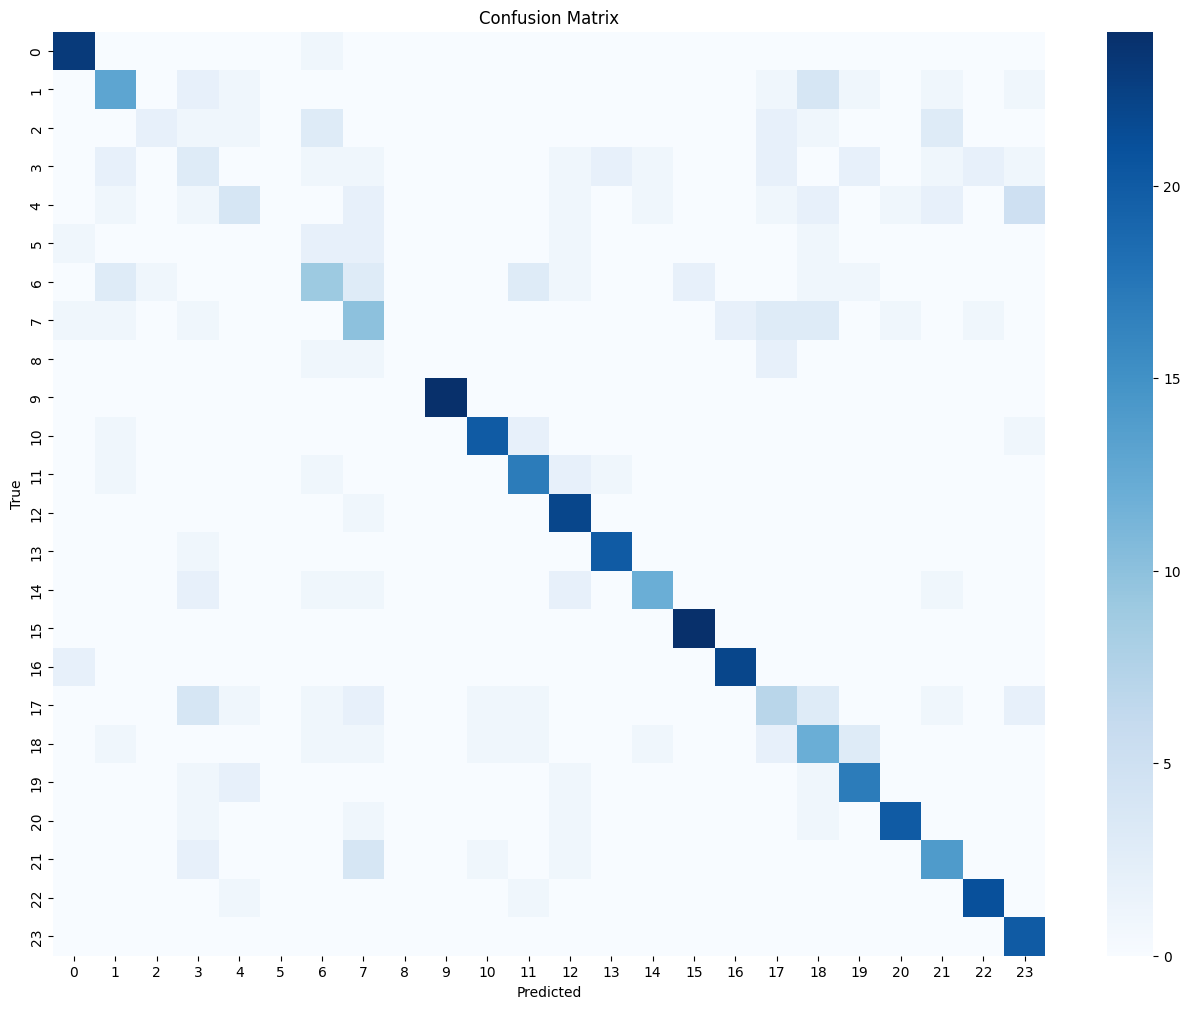

In [49]:
# ============================
# CONFUSION MATRIX
# ============================

cm = confusion_matrix(
    y_test,
    y_pred
)

plt.figure(figsize=(16,12))

sns.heatmap(
    cm,
    cmap='Blues'
)

plt.title('Confusion Matrix')

plt.xlabel('Predicted')
plt.ylabel('True')

plt.show()

La matriz de confusión expone que la diagonal principal es sumamente sólida y de un azul intenso a partir de la clase **9 hasta la 23**, lo que demuestra una precisión casi perfecta al clasificar este bloque de categorías. Por el contrario, las primeras clases (de la **0 a la 8**) sufren una notable degradación y dispersión de errores, concentrando fallos severos y solapamientos semánticos en las predicciones hacia las clases **6 y 7**. Finalmente, la gráfica ratifica visualmente la alerta de métricas indefinidas al mostrar celdas completamente vacías en la diagonal de las categorías minoritarias, confirmando que el desbalance de los datos es el responsable de limitar el rendimiento (*Accuracy* de 0.6761) a pesar de la excelente capacidad probabilística global reflejada en el modelo.

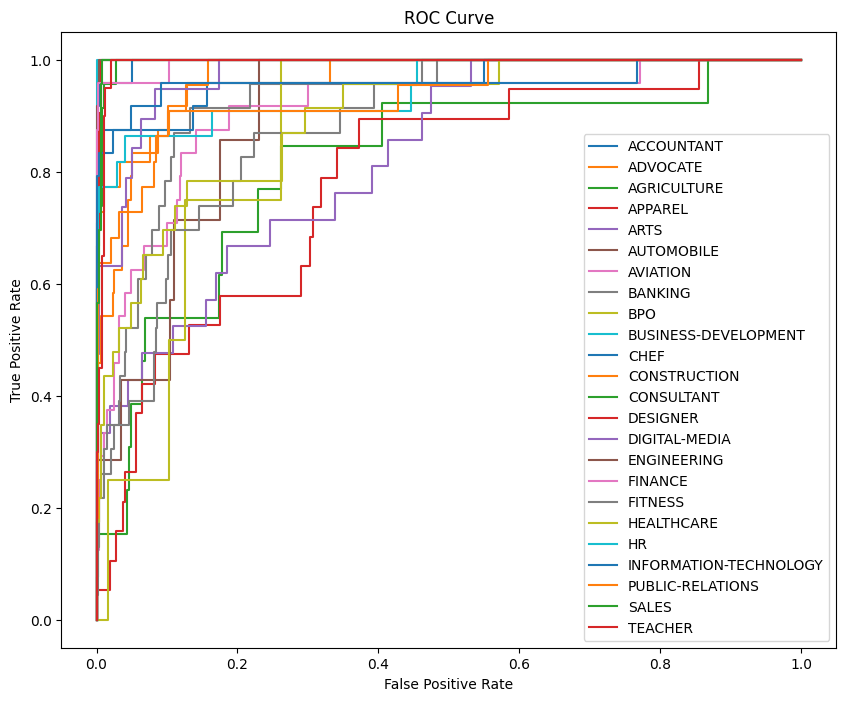

In [50]:
# ============================
# ROC CURVE
# ============================

fpr = dict()
tpr = dict()

for i in range(num_classes):

    fpr[i], tpr[i], _ = roc_curve(
        y_test_bin[:, i],
        y_pred_prob[:, i]
    )

plt.figure(figsize=(10,8))

for i in range(num_classes):

    plt.plot(
        fpr[i],
        tpr[i],
        label=label_encoder.classes_[i]
    )

plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')

plt.title('ROC Curve')

plt.legend()

plt.show()

La gráfica de curvas ROC por clase demuestra la altísima calidad probabilística de la arquitectura **FastText + BiLSTM** donde la totalidad de las 24 curvas (incluyendo clases críticas como *AUTOMOBILE* o *BPO*) se elevan de manera pronunciada hacia la esquina superior izquierda, logrando una tasa de verdaderos positivos muy alta con un margen mínimo de falsos positivos en los primeros umbrales. Aunque algunas categorías con menor soporte muestran trazos escalonados debido al tamaño reducido de la muestra en test, ninguna línea corre por debajo o cerca de la diagonal del azar, confirmando que el clasificador mantine una capacidad de discriminación y separación de clases excelente.

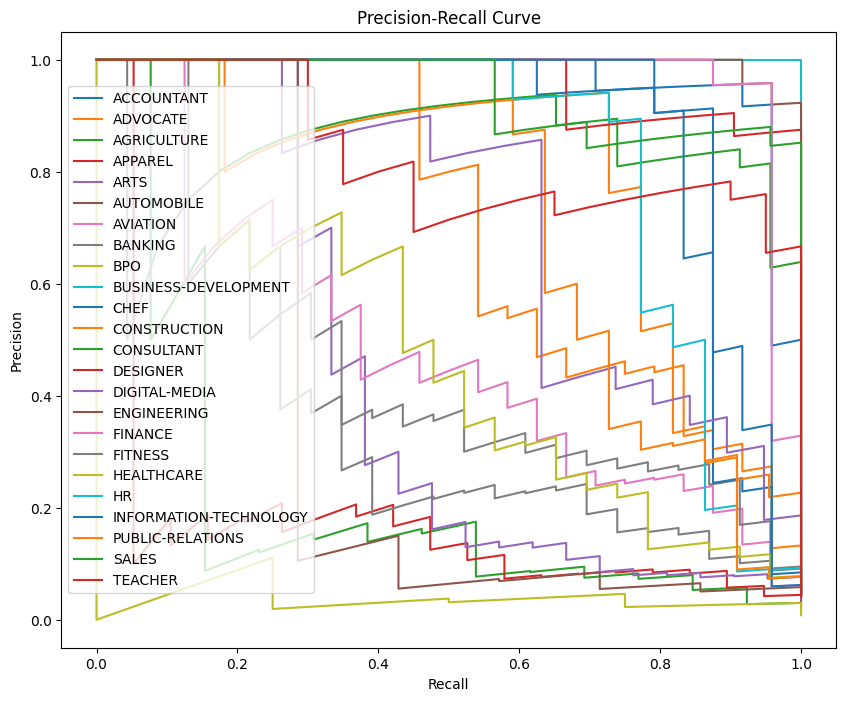

In [51]:
# ============================
# PRECISION RECALL CURVE
# ============================

plt.figure(figsize=(10,8))

for i in range(num_classes):

    precision_curve, recall_curve, _ = precision_recall_curve(

        y_test_bin[:, i],
        y_pred_prob[:, i]
    )

    plt.plot(
        recall_curve,
        precision_curve,
        label=label_encoder.classes_[i]
    )

plt.xlabel('Recall')
plt.ylabel('Precision')

plt.title('Precision-Recall Curve')

plt.legend()

plt.show()

En esta grafica podemos observar como el desbalance de los datos afecta la clasificación dura. El comportamiento gráfico revela un sistema con respuestas altamente diferenciadas: un grupo sólido de categorías (como *CHEF*, *ENGINEERING* o *BUSINESS-DEVELOPMENT*) logra mantener perfiles óptimos con una alta precisión sostenida incluso ante niveles elevados de cobertura (*recall*), demostrando la robustez de las representaciones de FastText en estas áreas. No obstante, la gran mayoría de las etiquetas muestra una transición en forma de "escalera" con descensos pronunciados a partir de un *recall* de 0.40, lo que visibiliza matemáticamente el costo de recuperación del modelo, el cual se ve obligado a incrementar la tasa de falsos positivos para capturar los casos reales de las clases más complejas.

In [52]:
# ============================
# RESULTS TABLE
# ============================

results_df = pd.DataFrame({

    'Modelo': ['FastText + BiLSTM'],
    'Accuracy': [accuracy],
    'Precision': [precision],
    'Recall': [recall],
    'F1': [f1],
    'ROC-AUC': [roc_auc]
})

results_df

,Modelo,Accuracy,Precision,Recall,F1,ROC-AUC
0,FastText + BiLSTM,0.676056,0.657725,0.676056,0.656881,0.938483


En conclusión, el rendimiento global es moderado y balanceado, registrando una **Accuracy de 0.6761** y un **F1-Score de 0.6569** en el conjunto de prueba. El análisis detallado de las gráficas permite concluir que la arquitectura recurrente alcanza una calidad sobresaliente en la modelación probabilística del texto, respaldada por un **ROC-AUC de 0.9385** que corrige los colapsos de discriminación individuales. No obstante, al trasladar dicho potencial a clasificaciones definitivas, el severo desbalance de datos de la muestra actúa como un factor limitante, provocando caídas de precisión escalonadas en los umbrales de cobertura (*Recall*) y penalizando el desempeño de las categorías con menor soporte, lo que sitúa a esta configuración con FastText en un nivel altamente competitivo.

### **5.5. Guardar Resultados**

In [53]:
import os  

save_dir = '../Models/FastText_BiLSTM_results'
os.makedirs(save_dir, exist_ok=True)

In [54]:
results_df.to_csv(
    f'{save_dir}/fasttext_bilstm_metrics.csv',
    index=False
)

In [55]:
with open(
    f'{save_dir}/best_hyperparameters.json',
    'w'
) as f:

    json.dump(
        best_params,
        f,
        indent=4
    )

In [56]:
predictions_df = pd.DataFrame({

    'True_Label': y_test,
    'Predicted_Label': y_pred
})

predictions_df.to_csv(
    f'{save_dir}/test_predictions.csv',
    index=False
)

In [57]:
best_model.save(
    f'{save_dir}/fasttext_bilstm_model.keras'
)

Finalmente, los resultados obtenidos fueron almacenados con el propósito de facilitar su posterior análisis y permitir un contraste riguroso frente a los rendimientos registrados por los demás modelos evaluados.

## **6. CNN-1D**

In [ ]:
import os

# FORZAR CPU
os.environ["CUDA_VISIBLE_DEVICES"] = "-1"

# Desactivar XLA
os.environ["TF_XLA_FLAGS"] = "--tf_xla_enable_xla_devices=false"

# Reducir logs
os.environ["TF_CPP_MIN_LOG_LEVEL"] = "2"

In [ ]:
import tensorflow as tf

# Desactivar JIT
tf.config.optimizer.set_jit(False)

print("TensorFlow version:", tf.__version__)

print("GPU disponible:", tf.config.list_physical_devices('GPU'))

I0000 00:00:1778913979.953695  153466 port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
/home/guirlessa/tf_gpu/lib/python3.10/site-packages/google/api_core/_python_version_support.py:273: FutureWarning: You are using a Python version (3.10.20) which Google will stop supporting in new releases of google.api_core once it reaches its end of life (2026-10-04). Please upgrade to the latest Python version, or at least Python 3.11, to continue receiving updates for google.api_core past that date.
  warnings.warn(message, FutureWarning)
I0000 00:00:1778913984.192205  153466 port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_

TensorFlow version: 2.21.0
GPU disponible: []


E0000 00:00:1778913988.181484  153466 cuda_platform.cc:52] failed call to cuInit: INTERNAL: CUDA error: Failed call to cuInit: CUDA_ERROR_NO_DEVICE: no CUDA-capable device is detected


### **6.1. Cargar Datos**

In [ ]:
X_train = np.load('../nlp_preprocessing/X_train.npy')
X_test = np.load('../nlp_preprocessing/X_test.npy')

y_train = np.load('../nlp_preprocessing/y_train.npy')
y_test = np.load('../nlp_preprocessing/y_test.npy')

embedding_matrix = np.load(
    '../nlp_preprocessing/embedding_matrix_ft.npy'
)

with open('../nlp_preprocessing/tokenizer.pkl', 'rb') as f:
    tokenizer = pickle.load(f)

with open('../nlp_preprocessing/label_encoder.pkl', 'rb') as f:
    label_encoder = pickle.load(f)

print(X_train.shape)
print(X_test.shape)

(1987, 700)
(497, 700)


### **6.2. Train/Validation Split & OneHotEncoding**

In [ ]:
# ============================================
# TRAIN / VALIDATION
# ============================================

X_train_final, X_val, y_train_final, y_val = train_test_split(
    X_train,
    y_train,
    test_size=0.15,
    random_state=42,
    stratify=y_train
)

print(X_train_final.shape)
print(X_val.shape)

(1688, 700)
(299, 700)


In [ ]:
# ============================================
# ONE HOT ENCODING
# ============================================

num_classes = len(np.unique(y_train))

y_train_cat = to_categorical(y_train_final, num_classes)
y_val_cat = to_categorical(y_val, num_classes)
y_test_cat = to_categorical(y_test, num_classes)

print(y_train_cat.shape)

(1688, 24)


### **6.3. Hiperparámetros**

In [ ]:
# ============================================
# HIPERPARÁMETROS
# ============================================

embedding_dims = [100]

filters_list = [64, 128]

kernel_sizes = [3, 5]

dropout_rates = [0.3]

learning_rates = [0.0005, 0.001]

batch_sizes = [32]

epochs_list = [50]

sequence_lengths = [500]

param_grid = list(product(
    embedding_dims,
    filters_list,
    kernel_sizes,
    dropout_rates,
    learning_rates,
    batch_sizes,
    epochs_list,
    sequence_lengths
))

print(f'Total combinaciones: {len(param_grid)}')

Total combinaciones: 8


In [ ]:
# ============================================
# MODELO CNN-1D
# ============================================

vocab_size = embedding_matrix.shape[0]

def build_cnn_model(
    embedding_dim,
    filters,
    kernel_size,
    dropout_rate,
    learning_rate,
    sequence_length
):

    model = Sequential()

    model.add(
        Embedding(
            input_dim=vocab_size,
            output_dim=embedding_dim,
            weights=[embedding_matrix[:, :embedding_dim]],
            input_length=sequence_length,
            trainable=False
        )
    )

    model.add(
        Conv1D(
            filters=filters,
            kernel_size=kernel_size,
            activation='relu'
        )
    )

    model.add(BatchNormalization())

    model.add(GlobalMaxPooling1D())

    model.add(Dropout(dropout_rate))

    model.add(Dense(128, activation='relu'))

    model.add(Dropout(dropout_rate))

    model.add(Dense(num_classes, activation='softmax'))

    optimizer = Adam(learning_rate=learning_rate)

    model.compile(
        optimizer=optimizer,
        loss='categorical_crossentropy',
        metrics=['accuracy']
    )

    return model

In [ ]:
# ============================================
# GRID SEARCH
# ============================================

best_accuracy = 0
best_model = None
best_params = None
results = []

for params in param_grid:

    (
        embedding_dim,
        filters,
        kernel_size,
        dropout_rate,
        learning_rate,
        batch_size,
        epochs,
        sequence_length
    ) = params

    print("="*60)
    print(params)

    X_train_seq = X_train_final[:, :sequence_length]
    X_val_seq = X_val[:, :sequence_length]

    model = build_cnn_model(
        embedding_dim,
        filters,
        kernel_size,
        dropout_rate,
        learning_rate,
        sequence_length
    )

    early_stop = EarlyStopping(
        monitor='val_loss',
        patience=5,
        restore_best_weights=True
    )

    reduce_lr = ReduceLROnPlateau(
        monitor='val_loss',
        factor=0.5,
        patience=2
    )

    history = model.fit(
        X_train_seq,
        y_train_cat,
        validation_data=(X_val_seq, y_val_cat),
        epochs=epochs,
        batch_size=batch_size,
        callbacks=[early_stop, reduce_lr],
        verbose=0
    )

    val_pred = np.argmax(
        model.predict(X_val_seq, verbose=0),
        axis=1
    )

    accuracy = accuracy_score(y_val, val_pred)

    print(f'Validation Accuracy: {accuracy:.4f}')

    results.append({
        'embedding_dim': embedding_dim,
        'filters': filters,
        'kernel_size': kernel_size,
        'dropout_rate': dropout_rate,
        'learning_rate': learning_rate,
        'batch_size': batch_size,
        'epochs': epochs,
        'sequence_length': sequence_length,
        'val_accuracy': accuracy
    })

    if accuracy > best_accuracy:

        best_accuracy = accuracy
        best_model = model
        best_params = params

print("\nMEJORES HIPERPARÁMETROS")
print(best_params)
print(best_accuracy)

(100, 64, 3, 0.3, 0.0005, 32, 50, 500)


/home/guirlessa/tf_gpu/lib/python3.10/site-packages/keras/src/layers/core/embedding.py:97: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


Validation Accuracy: 0.0803
(100, 64, 3, 0.3, 0.001, 32, 50, 500)


/home/guirlessa/tf_gpu/lib/python3.10/site-packages/keras/src/layers/core/embedding.py:97: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


Validation Accuracy: 0.4649
(100, 64, 5, 0.3, 0.0005, 32, 50, 500)


/home/guirlessa/tf_gpu/lib/python3.10/site-packages/keras/src/layers/core/embedding.py:97: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


Validation Accuracy: 0.0635
(100, 64, 5, 0.3, 0.001, 32, 50, 500)


/home/guirlessa/tf_gpu/lib/python3.10/site-packages/keras/src/layers/core/embedding.py:97: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


Validation Accuracy: 0.3779
(100, 128, 3, 0.3, 0.0005, 32, 50, 500)


/home/guirlessa/tf_gpu/lib/python3.10/site-packages/keras/src/layers/core/embedding.py:97: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


Validation Accuracy: 0.0602
(100, 128, 3, 0.3, 0.001, 32, 50, 500)


/home/guirlessa/tf_gpu/lib/python3.10/site-packages/keras/src/layers/core/embedding.py:97: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


Validation Accuracy: 0.3813
(100, 128, 5, 0.3, 0.0005, 32, 50, 500)


/home/guirlessa/tf_gpu/lib/python3.10/site-packages/keras/src/layers/core/embedding.py:97: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


Validation Accuracy: 0.4013
(100, 128, 5, 0.3, 0.001, 32, 50, 500)


/home/guirlessa/tf_gpu/lib/python3.10/site-packages/keras/src/layers/core/embedding.py:97: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


Validation Accuracy: 0.4013

MEJORES HIPERPARÁMETROS
(100, 64, 3, 0.3, 0.001, 32, 50, 500)
0.46488294314381273


### **6.4. Evaluación en Test**

In [ ]:
# ============================================
# TEST
# ============================================

best_sequence_length = best_params[-1]

X_test_seq = X_test[:, :best_sequence_length]

y_pred_prob = best_model.predict(X_test_seq)

y_pred = np.argmax(y_pred_prob, axis=1)

accuracy = accuracy_score(y_test, y_pred)

precision = precision_score(
    y_test,
    y_pred,
    average='weighted'
)

recall = recall_score(
    y_test,
    y_pred,
    average='weighted'
)

f1 = f1_score(
    y_test,
    y_pred,
    average='weighted'
)

print(f'Accuracy : {accuracy:.4f}')
print(f'Precision: {precision:.4f}')
print(f'Recall   : {recall:.4f}')
print(f'F1-score : {f1:.4f}')

16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step
Accuracy : 0.5131
Precision: 0.4788
Recall   : 0.5131
F1-score : 0.4772


/home/guirlessa/tf_gpu/lib/python3.10/site-packages/sklearn/metrics/_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])


El modelo CNN-1D obtuvo una accuracy de 0.5131, junto con valores de precisión, recall y F1-score cercanos al 50%, lo que indica un desempeño moderado en la tarea de clasificación multiclase. Estos resultados sugieren que el modelo logra identificar patrones relevantes en los textos, aunque presenta dificultades para clasificar correctamente varias categorías. Las advertencias de *UndefinedMetricWarning* indican que existen clases para las cuales el modelo no generó predicciones, afectando el cálculo de la precisión y evidenciando un rendimiento desigual entre las diferentes clases del problema.

In [ ]:
# ============================================
# ROC-AUC
# ============================================

y_test_bin = label_binarize(
    y_test,
    classes=np.unique(y_test)
)

roc_auc = roc_auc_score(
    y_test_bin,
    y_pred_prob,
    multi_class='ovr'
)

print(f'ROC-AUC: {roc_auc:.4f}')

ROC-AUC: 0.8933


El modelo CNN-1D alcanzó un ROC-AUC de 0.8933, lo que indica una buena capacidad de discriminación probabilística entre las distintas clases. Esto sugiere que el modelo logra diferenciar adecuadamente muchas categorías a nivel de probabilidades, aunque las métricas de clasificación final muestran que aún existen dificultades al asignar correctamente algunas etiquetas específicas en el problema multiclase.

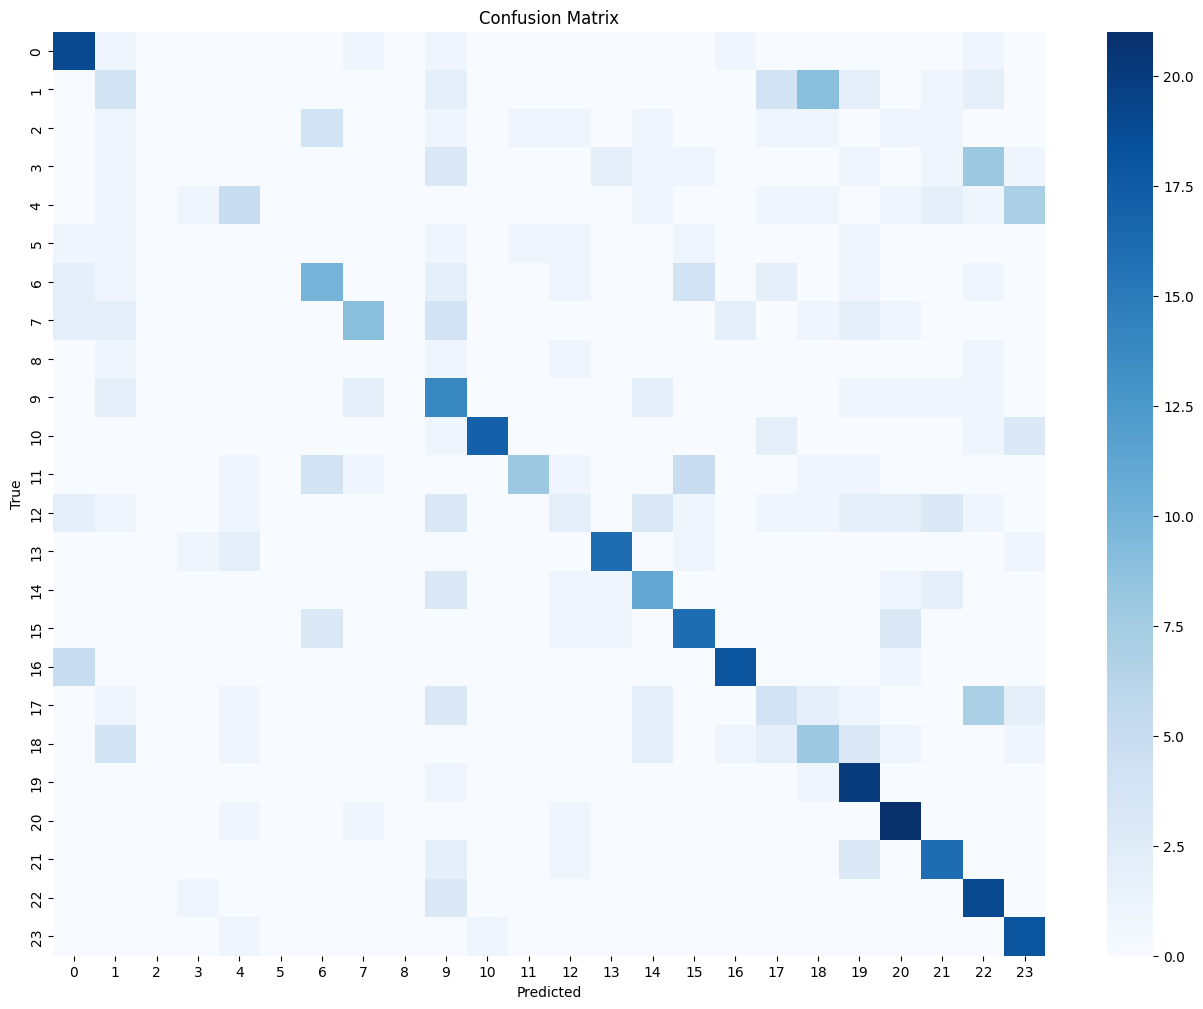

In [ ]:
# ============================================
# MATRIZ DE CONFUSIÓN
# ============================================

cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(16,12))

sns.heatmap(
    cm,
    cmap='Blues'
)

plt.title('Confusion Matrix')

plt.xlabel('Predicted')
plt.ylabel('True')

plt.show()

La matriz de confusión del modelo CNN-1D muestra un rendimiento deficiente (51% de exactitud) debido a una diagonal principal muy inconsistente, la cual colapsa casi por completo en las primeras categorías (de la 0 a la 8) dejando las clases minoritarias 5 y 8 con un total de cero aciertos. Aunque el bloque inferior (de la clase 9 a la 23) logra rescatar una diagonal azul más definida, se observa una fuerte fuga de errores fuera de ella, destacando un fuerte sesgo vertical en la columna de predicción 9.

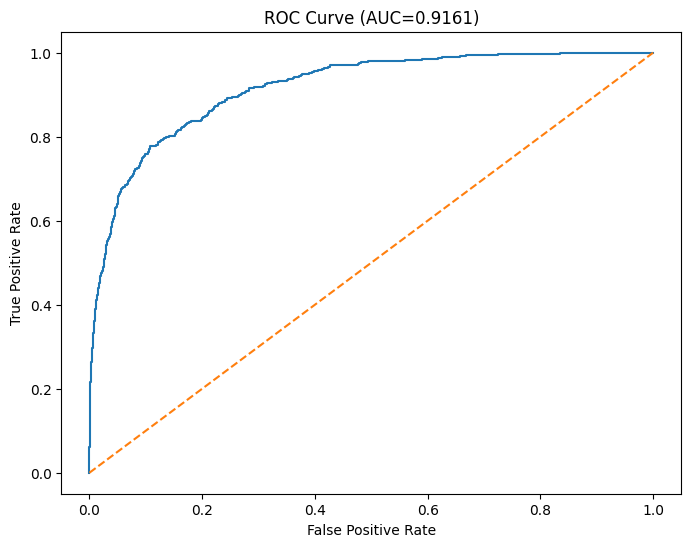

In [ ]:
# ============================================
# CURVA ROC
# ============================================

fpr, tpr, _ = roc_curve(
    y_test_bin.ravel(),
    y_pred_prob.ravel()
)

roc_auc_curve = auc(fpr, tpr)

plt.figure(figsize=(8,6))

plt.plot(fpr, tpr)

plt.plot([0,1], [0,1], linestyle='--')

plt.title(f'ROC Curve (AUC={roc_auc_curve:.4f})')

plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')

plt.show()

La curva ROC general del modelo CNN-1D muestra un AUC macro de 0.9161, lo que indica que, a nivel probabilístico, la red convolucional mantiene una capacidad sobresaliente para discriminar y ordenar correctamente las 24 categorías antes de la asignación del umbral de decisión final. La curva se eleva de manera rápida y continua hacia la esquina superior izquierda, alejándose significativamente de la diagonal del azar (línea punteada naranja), lo que confirma que el modelo retiene un fuerte potencial matemático para separar las clases.

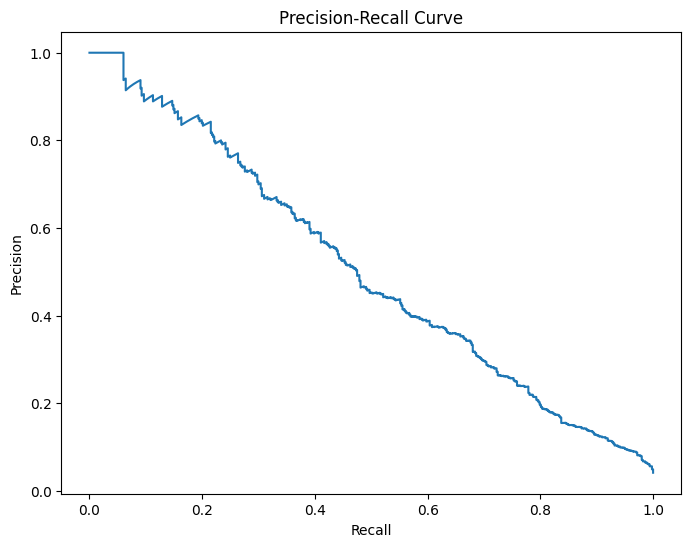

In [ ]:
# ============================================
# PRECISION-RECALL CURVE
# ============================================

precision_curve, recall_curve, _ = precision_recall_curve(
    y_test_bin.ravel(),
    y_pred_prob.ravel()
)

plt.figure(figsize=(8,6))

plt.plot(recall_curve, precision_curve)

plt.title('Precision-Recall Curve')

plt.xlabel('Recall')
plt.ylabel('Precision')

plt.show()

La curva Precision-Recall general del modelo **CNN-1D** exhibe un descenso lineal y pronunciado a medida que se incrementa el nivel de cobertura (*Recall*), lo que ilustra de forma directa la fragilidad del clasificador duro ante el desbalance de las clases. A diferencia de un comportamiento ideal —donde la curva se mantendría alta y extendida hacia la esquina superior derecha—, esta gráfica muestra una caída casi diagonal que confirma el alto costo de recuperación del algoritmo: para lograr identificar más casos positivos reales (subir el *Recall*), la red convolucional se ve obligada a sacrificar drásticamente su precisión introduciendo un volumen masivo de falsos positivos. Este patrón descendente valida matemáticamente el modesto F1-Score general de 0.4772, reflejando que la arquitectura CNN-1D carece de la estabilidad necesaria para equilibrar de manera óptima la precisión y la cobertura en un escenario con 24 categorías altamente desbalanceadas.

In [ ]:
# ============================================
# RESULTADOS
# ============================================

results_df = pd.DataFrame([{
    'Modelo': 'CNN-1D',
    'Accuracy': accuracy,
    'Precision': precision,
    'Recall': recall,
    'F1': f1,
    'ROC-AUC': roc_auc
}])

results_df

,Modelo,Accuracy,Precision,Recall,F1,ROC-AUC
0,CNN-1D,0.513078,0.478842,0.513078,0.477228,0.893309


La evaluación general resumida en la tabla para el modelo **CNN-1D** confirma un desempeño deficiente en el conjunto de prueba, consolidando una **Accuracy de 0.5131** y un **F1-Score de 0.4772**, lo que indica que la red convolucional falla en clasificar correctamente casi la mitad de los textos analizados. La alineación a la baja entre la **Precision (0.4788)** y el **Recall (0.5131)** refleja una incapacidad estructural generalizada para establecer fronteras precisas entre las 24 categorías, viéndose fuertemente arrastrada por el desbalance de los datos. Por otro lado, el **ROC-AUC de 0.8933** se mantiene en un nivel notablemente alto; esta marcada diferencia matemática ratifica que, si bien el algoritmo conserva una capacidad sobresaliente para ordenar y separar las probabilidades de las clases a nivel interno, este potencial se pierde por completo al aplicar el umbral de decisión rígido para la asignación definitiva de las etiquetas.

### **6.5. Guardar Resultados**

In [ ]:
# ============================================
# GUARDAR RESULTADOS
# ============================================

import os

save_dir = '../Models/cnn_results'

os.makedirs(save_dir, exist_ok=True)

In [ ]:
# ============================================
# GUARDAR MODELO
# ============================================

best_model.save(f'{save_dir}/cnn_model.h5')

print('Modelo guardado')

Modelo guardado


In [ ]:
# ============================================
# GUARDAR HIPERPARÁMETROS
# ============================================

best_params_dict = {
    'embedding_dim': best_params[0],
    'filters': best_params[1],
    'kernel_size': best_params[2],
    'dropout_rate': best_params[3],
    'learning_rate': best_params[4],
    'batch_size': best_params[5],
    'epochs': best_params[6],
    'sequence_length': best_params[7]
}

with open(
    f'{save_dir}/best_hyperparameters.pkl',
    'wb'
) as f:

    pickle.dump(best_params_dict, f)

print('Hiperparámetros guardados')

Hiperparámetros guardados


In [ ]:
# ============================================
# GUARDAR MÉTRICAS
# ============================================

metrics = {
    'accuracy': accuracy,
    'precision': precision,
    'recall': recall,
    'f1': f1,
    'roc_auc': roc_auc
}

with open(
    f'{save_dir}/metrics.pkl',
    'wb'
) as f:

    pickle.dump(metrics, f)

print('Métricas guardadas')

Métricas guardadas


In [ ]:
# ============================================
# GUARDAR PREDICCIONES
# ============================================

predictions_df = pd.DataFrame({
    'y_true': y_test,
    'y_pred': y_pred
})

predictions_df.to_csv(
    f'{save_dir}/test_predictions.csv',
    index=False
)

print('Predicciones guardadas')

Predicciones guardadas


Finalmente, los resultados obtenidos fueron almacenados con el propósito de facilitar su posterior análisis y permitir un contraste riguroso frente a los rendimientos registrados por los demás modelos evaluados.